# Phase A — Exploratory Data Analysis

**SingHacks 2026 · Julius Baer wealth intelligence · dataset in `data/`**

One relationship manager, Priscilla Ong, looks after 20 clients holding 24 portfolios.
Positions are given at **five dated snapshots**, the last of which (2026-08-26) is "today".

### How to read this notebook

Every section follows the same three lines:

- **What we check** — the question being asked of the data.
- **Why it matters** — what an answer changes for the product we are building.
- **What we found** — the actual result, with numbers, written after the code below it ran.

Where a finding tells us something concrete about what to build, a callout says so on the spot:

> **Pipeline action.** ...

Sections 1–2 establish that the data is trustworthy. Sections 3–10 extract the signals. Section 11
catalogues every flaw we found. **Section 12 is the build specification** — the stage-by-stage
pipeline, the cleaning rules for each file, the engineered features and the exact output artifacts.
Section 13 is the summary and the three client stories the demo should tell.

Five words used throughout, in case they are unfamiliar:

- **Snapshot** — one of the five dates positions are reported at.
- **Household** — a client's portfolios added together. Some clients hold more than one, and the
  bank owes its suitability view on the whole relationship rather than on each account.
- **Mandate** — the agreed rulebook for a portfolio: how much may sit in each asset class, and the
  most that may sit in any one position.
- **Lombard facility** — a loan secured against a portfolio. The bank lends against a haircut
  version of the portfolio's value, not its market value.
- **Look-through** — working out what a product is really exposed to, rather than what it is called.



### RM review revision

Revised against all 35 required changes in `RM_REVIEW.md`. Calculations are checked against source rows, including corrections to several numbers in the review itself. Section 12 freezes the implementation specification; section 13 shows the corrected stories. Reference maps are versioned in `reference_maps.json`; analytical completion does not imply external human RM approval or production pipeline integration.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_data() -> Path:
    """Locate data/ whether the notebook runs from repo root or from notebooks/."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "holdings.csv").exists():
            return base / "data"
    raise FileNotFoundError("could not find data/holdings.csv")


DATA = find_data()

SNAPSHOTS = ["2025-12-31", "2026-02-27", "2026-03-31", "2026-06-30", "2026-08-26"]
FIRST, LAST = SNAPSHOTS[0], SNAPSHOTS[-1]
TODAY = LAST
ASSET_CLASSES = [
    "Cash and Equivalents",
    "Fixed Income",
    "Equity",
    "Alternatives",
    "Commodities",
    "Structured Products",
]

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def load(filename: str) -> pd.DataFrame:
    """Read one source file. JSON comes back as a DataFrame too."""
    path = DATA / filename
    if path.suffix == ".json":
        return pd.DataFrame(json.loads(path.read_text()))
    return pd.read_csv(path)


FILES = [
    "clients.csv",
    "portfolios.csv",
    "holdings.csv",
    "instruments.csv",
    "mandates.csv",
    "transactions.csv",
    "credit_facilities.csv",
    "commitments.csv",
    "planned_cash_needs.csv",
    "market_context.csv",
    "event_log.csv",
    "rm_notes.json",
]

src = {f.rsplit(".", 1)[0]: load(f) for f in FILES}

clients = src["clients"]
portfolios = src["portfolios"]
holdings = src["holdings"]
instruments = src["instruments"]
mandates = src["mandates"]
transactions = src["transactions"]
facilities = src["credit_facilities"]
commitments = src["commitments"]
cash_needs = src["planned_cash_needs"]
market = src["market_context"]
events = src["event_log"]
notes = src["rm_notes"]

NAME = clients.set_index("client_id")["client_name"].to_dict()
BASE_CCY = clients.set_index("client_id")["base_currency"].to_dict()

# FX at each snapshot, quoted the way market_context quotes it.
FX = market[market["category"] == "FX"].pivot_table(
    index="snapshot_date", columns="series_id", values="value"
)


def to_usd(amount: float, ccy: str, date: str = TODAY) -> float:
    """Convert an amount to USD using market_context rates for that snapshot."""
    if ccy == "USD":
        return float(amount)
    row = FX.loc[date]
    if f"{ccy}USD" in row.index:  # EURUSD, GBPUSD are quoted USD per unit
        return float(amount) * float(row[f"{ccy}USD"])
    return float(amount) / float(row[f"USD{ccy}"])


def name_of(client_id: str) -> str:
    return NAME.get(client_id, client_id)


print(f"data directory : {DATA}")
print(f"sources loaded : {len(src)}")
print(f"snapshots      : {', '.join(SNAPSHOTS)}  (today = {TODAY})")

data directory : /Users/rlatldn20001114/SingHacks-2026/data
sources loaded : 12
snapshots      : 2025-12-31, 2026-02-27, 2026-03-31, 2026-06-30, 2026-08-26  (today = 2026-08-26)


## 1. File-by-file profile

**What we check.** Size, shape, missing values and duplicates for all 12 source files, plus a look
at a few real rows.

**Why it matters.** In a private bank the position file is the record of what a client owns, and
everything downstream — the valuation, the suitability test, the tax pack — is derived from it. We
need to know which fields are always populated before we compute anything, because a suitability
check that silently skips a position is worse than no check at all. Nulls also mark where the
operational seams are: a missing cost basis almost always means an asset was transferred in from
another institution, and that one fact changes what advice is even possible for that client.

**What we found.** 12 files, 1,703 rows across the tabular sources. The data is cleaner than
production banking data usually is: **no duplicate rows in any file**, and only 12 columns anywhere
contain a null. Most of those nulls are structural rather than missing data:

- `transactions` accounts for 901 of them, and all are expected — a dividend or a management fee has
  no quantity or price, and 65 of the 393 rows are portfolio-level cash movements with no instrument.
- `instruments.underlying_reference` is null for 53 of 62 instruments, because only structured
  products and a few specials reference an underlying.

That leaves three genuinely missing things, all of which turn out to matter: `clients.age` is null
once (Fong Enterprises is a legal entity, not a person); `holdings.sector` is null for 5 rows; and
5 rows have no cost basis at all. The last two belong to just **two instruments inside one
portfolio, PF-0005** — which section 11 shows is a portfolio transferred in from another bank.

> **Pipeline action.** Stage S1 (ingest) coerces types and parses dates explicitly rather than
> letting pandas infer them, and stage S2 (validate) records every null as a tagged observation
> instead of dropping the row. Nulls that are structural (a dividend has no quantity) are
> allow-listed by `(file, column)`; anything else is written to `data_quality_report.json` with its
> row reference. No row is ever silently discarded.

In [2]:
def profile(filename: str, df: pd.DataFrame) -> dict:
    nulls = df.isna().sum()
    return {
        "file": filename,
        "rows": len(df),
        "cols": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "cols_with_nulls": int((nulls > 0).sum()),
        "null_cells": int(nulls.sum()),
        "first_columns": ", ".join(df.columns[:3]),
    }


profile_table = pd.DataFrame([profile(f, src[f.rsplit(".", 1)[0]]) for f in FILES])
profile_table

,file,rows,cols,duplicate_rows,cols_with_nulls,null_cells,first_columns
0,clients.csv,20,25,0,1,1,"client_id, client_name, age"
1,portfolios.csv,24,15,0,0,0,"portfolio_id, client_id, portfolio_name"
2,holdings.csv,1015,26,0,5,25,"snapshot_date, portfolio_id, client_id"
3,instruments.csv,62,16,0,2,54,"instrument_id, instrument_name, asset_class"
4,mandates.csv,48,8,0,0,0,"mandate_code, mandate_name, asset_class"
5,transactions.csv,393,13,0,4,901,"transaction_id, trade_date, settlement_date"
6,credit_facilities.csv,5,34,0,0,0,"facility_id, client_id, collateral_portfolio_id"
7,commitments.csv,5,9,0,0,0,"commitment_id, client_id, portfolio_id"
8,planned_cash_needs.csv,20,9,0,0,0,"need_id, client_id, description"
9,market_context.csv,115,7,0,0,0,"snapshot_date, series_id, series_name"


In [3]:
# Every column in the dataset that contains a null, and how many.
null_report = []
for filename in FILES:
    df = src[filename.rsplit(".", 1)[0]]
    nulls = df.isna().sum()
    for column, n in nulls[nulls > 0].items():
        null_report.append(
            {"file": filename, "column": column, "nulls": int(n), "of_rows": len(df)}
        )

pd.DataFrame(null_report)

,file,column,nulls,of_rows
0,clients.csv,age,1,20
1,holdings.csv,sector,5,1015
2,holdings.csv,avg_cost_local,5,1015
3,holdings.csv,cost_basis_base,5,1015
4,holdings.csv,unrealised_pnl_base,5,1015
5,holdings.csv,unrealised_pnl_pct,5,1015
6,instruments.csv,sector,1,62
7,instruments.csv,underlying_reference,53,62
8,transactions.csv,instrument_id,65,393
9,transactions.csv,instrument_name,65,393


In [4]:
# Column dtypes, grouped so we can see the shape of each file without 12 walls of output.
dtype_rows = []
for filename in FILES:
    df = src[filename.rsplit(".", 1)[0]]
    counts = df.dtypes.astype(str).value_counts()
    dtype_rows.append({"file": filename, **{k: int(v) for k, v in counts.items()}})

pd.DataFrame(dtype_rows).fillna(0).set_index("file").astype(int)

,str,float64,int64
file,,,
clients.csv,21,2,2
portfolios.csv,9,6,0
holdings.csv,14,11,1
instruments.csv,11,5,0
mandates.csv,4,1,3
transactions.csv,10,3,0
credit_facilities.csv,5,23,6
commitments.csv,6,0,3
planned_cash_needs.csv,8,0,1


In [5]:
# Sample rows from the three files everything else hangs off.
print("HOLDINGS (the centre of gravity)")
display(
    holdings.loc[
        holdings["snapshot_date"] == TODAY,
        [
            "snapshot_date",
            "portfolio_id",
            "client_id",
            "instrument_id",
            "asset_class",
            "quantity",
            "price_local",
            "market_value_base",
            "market_value_usd",
            "weight_pct",
            "liquidity_tier",
        ],
    ].head(4)
)

print("\nINSTRUMENTS")
display(
    instruments[
        [
            "instrument_id",
            "instrument_name",
            "asset_class",
            "currency",
            "liquidity_tier",
            "concentration_limit_applies",
            "sustainability_excluded",
        ]
    ].head(4)
)

print("\nRM NOTES")
display(notes[["note_id", "client_id", "note_date", "channel"]].head(4))

HOLDINGS (the centre of gravity)


,snapshot_date,portfolio_id,client_id,instrument_id,asset_class,quantity,price_local,market_value_base,market_value_usd,weight_pct,liquidity_tier
33,2026-08-26,PF-0001,CL-0001,SYN-EQ-0001,Equity,30000,238.0,9653280.0,7140000.0,26.5587,Daily
34,2026-08-26,PF-0001,CL-0001,SYN-EQ-0020,Equity,40000,99.3,5370144.0,3972000.0,14.7747,Daily
35,2026-08-26,PF-0001,CL-0001,SYN-EQ-0003,Equity,4000,592.1,3202076.8,2368400.0,8.8098,Daily
36,2026-08-26,PF-0001,CL-0001,SYN-FI-0204,Fixed Income,45000,93.9,5712876.0,4225500.0,15.7176,Daily



INSTRUMENTS


,instrument_id,instrument_name,asset_class,currency,liquidity_tier,concentration_limit_applies,sustainability_excluded
0,SYN-EQ-0001,Global Developed Equity Index Fund,Equity,USD,Daily,N,N
1,SYN-EQ-0002,US Large Cap Core Fund,Equity,USD,Daily,N,N
2,SYN-EQ-0003,US Technology Leaders Fund,Equity,USD,Daily,N,N
3,SYN-EQ-0004,European Equity Fund,Equity,EUR,Daily,N,N



RM NOTES


,note_id,client_id,note_date,channel
0,N-001,CL-0001,2026-01-08,Meeting
1,N-002,CL-0001,2026-04-14,Call
2,N-003,CL-0002,2026-02-03,Meeting
3,N-004,CL-0002,2026-06-11,Call


In [6]:
# Category values we will rely on later. Worth reading once.
print("asset classes   :", sorted(holdings["asset_class"].unique()))
print("liquidity tiers :", sorted(holdings["liquidity_tier"].unique()))
print("service models  :", sorted(portfolios["service_model"].unique()))
print("mandate codes   :", sorted(mandates["mandate_code"].unique()))
print("risk profiles   :", sorted(clients["risk_profile"].unique()))
print("txn types       :", sorted(transactions["transaction_type"].unique()))
print()
print("clients:", len(clients), " portfolios:", len(portfolios), " instruments:", len(instruments))
print("clients holding more than one portfolio:")
multi = portfolios.groupby("client_id").size()
display(
    multi[multi > 1]
    .rename("portfolios")
    .reset_index()
    .assign(client_name=lambda d: d["client_id"].map(NAME))
)

asset classes   : ['Alternatives', 'Cash and Equivalents', 'Commodities', 'Equity', 'Fixed Income', 'Structured Products']
liquidity tiers : ['Daily', 'Illiquid', 'Monthly', 'Quarterly Gate', 'Weekly']
service models  : ['Advisory', 'Custody', 'Discretionary']
mandate codes   : ['ALTS', 'BAL', 'BALG', 'CONS', 'DYN', 'GROW', 'INC', 'SUSBAL']
risk profiles   : ['Balanced', 'Balanced Growth', 'Conservative', 'Dynamic Opportunistic', 'Growth', 'Income', 'Sustainable Balanced']
txn types       : ['Buy', 'Capital Call', 'Coupon', 'Distribution', 'Dividend', 'Facility Drawdown', 'Interest', 'Interest Charge', 'Management Fee', 'Redemption Request', 'Structured Product Subscription', 'Transfer In', 'Valuation Update', 'Withdrawal']

clients: 20  portfolios: 24  instruments: 62
clients holding more than one portfolio:


,client_id,portfolios,client_name
0,CL-0001,2,Hartono Wijaya Kusuma
1,CL-0002,2,Ravi Chandrasekaran
2,CL-0017,3,Fong Enterprises Family Office


## 2. Join-key integrity

**What we check.** Does every foreign key find its parent? Holdings to portfolios, portfolios to
clients, holdings to instruments, transactions to portfolios, facilities to portfolios, notes to
clients. We also check the reverse — parents with no children — and whether the client id that is
denormalised onto `holdings` agrees with the one on `portfolios`.

**Why it matters.** Client reporting is built by joining these tables, and the bank is accountable
for every number it puts in front of a client. An inner join that quietly drops an orphan position
understates that client's wealth and can hide a breach — the kind of error that surfaces in a
regulatory review rather than in testing. Reconciling the sum of positions back to the reported
account value is the standard control for exactly this: if the parts do not add up to the whole,
the whole is wrong and nothing built on it can be defended.

**What we found.** **Referential integrity is perfect — zero orphans on every join, in both
directions.** All 1,015 holdings map to the 24 portfolios; all 24 portfolios map to 20 clients;
all 62 instruments are held by someone and every held instrument is described; all 393 transactions
and all 5 credit facilities point at real portfolios; all 28 RM notes point at real clients. The
denormalised `holdings.client_id` agrees with `portfolios.client_id` on every row. We also
reconciled the money: **the sum of `holdings.market_value_base` equals the `aum_<date>` column in
`portfolios.csv` to within a cent for all 120 portfolio-snapshot pairs**, and the sum of
`portfolios.aum_usd_current` equals `clients.total_aum_usd` for all 20 clients. Inner joins are
safe here.

> **Pipeline action.** Stage S2 (validate) runs these same checks and **fails closed**: if any
> orphan, duplicate key or reconciliation break appears, the run raises with a diagnostic list
> rather than publishing a partial bundle. The repo already has this shape in
> `app/pipeline/sources.py` (`load_sources` raises `SourceValidationError` carrying
> `SourceDiagnostic` rows); the two additions needed are the **AUM reconciliation** check
> (`sum(holdings.market_value_base)` vs `portfolios.aum_<date>`, tolerance USD 0.01) and the
> **quantity × price** check, neither of which is currently validated.

In [7]:
def join_check(label, left, right):
    left_set, right_set = set(pd.Series(left).dropna()), set(pd.Series(right).dropna())
    orphans = sorted(left_set - right_set)
    return {
        "join": label,
        "distinct_keys": len(left_set),
        "matched": len(left_set & right_set),
        "orphans": len(orphans),
        "example_orphan": orphans[0] if orphans else "-",
    }


join_table = pd.DataFrame(
    [
        join_check(
            "holdings.portfolio_id -> portfolios",
            holdings["portfolio_id"],
            portfolios["portfolio_id"],
        ),
        join_check("holdings.client_id -> clients", holdings["client_id"], clients["client_id"]),
        join_check(
            "holdings.instrument_id -> instruments",
            holdings["instrument_id"],
            instruments["instrument_id"],
        ),
        join_check(
            "portfolios.client_id -> clients", portfolios["client_id"], clients["client_id"]
        ),
        join_check(
            "portfolios.mandate_code -> mandates",
            portfolios["mandate_code"],
            mandates["mandate_code"],
        ),
        join_check(
            "transactions.portfolio_id -> portfolios",
            transactions["portfolio_id"],
            portfolios["portfolio_id"],
        ),
        join_check(
            "transactions.instrument_id -> instruments",
            transactions["instrument_id"],
            instruments["instrument_id"],
        ),
        join_check(
            "facilities.collateral_portfolio_id -> portfolios",
            facilities["collateral_portfolio_id"],
            portfolios["portfolio_id"],
        ),
        join_check(
            "commitments.portfolio_id -> portfolios",
            commitments["portfolio_id"],
            portfolios["portfolio_id"],
        ),
        join_check(
            "cash_needs.client_id -> clients", cash_needs["client_id"], clients["client_id"]
        ),
        join_check("rm_notes.client_id -> clients", notes["client_id"], clients["client_id"]),
        # reverse direction: parents with no children
        join_check(
            "portfolios -> appear in holdings", portfolios["portfolio_id"], holdings["portfolio_id"]
        ),
        join_check("clients -> own a portfolio", clients["client_id"], portfolios["client_id"]),
        join_check(
            "instruments -> held by someone",
            instruments["instrument_id"],
            holdings["instrument_id"],
        ),
    ]
)
join_table

,join,distinct_keys,matched,orphans,example_orphan
0,holdings.portfolio_id -> portfolios,24,24,0,-
1,holdings.client_id -> clients,20,20,0,-
2,holdings.instrument_id -> instruments,62,62,0,-
3,portfolios.client_id -> clients,20,20,0,-
4,portfolios.mandate_code -> mandates,8,8,0,-
5,transactions.portfolio_id -> portfolios,24,24,0,-
6,transactions.instrument_id -> instruments,46,46,0,-
7,facilities.collateral_portfolio_id -> portfolios,5,5,0,-
8,commitments.portfolio_id -> portfolios,4,4,0,-
9,cash_needs.client_id -> clients,16,16,0,-


In [8]:
# Is the client_id denormalised onto holdings consistent with portfolios.csv?
check = holdings.merge(
    portfolios[["portfolio_id", "client_id"]], on="portfolio_id", suffixes=("_h", "_p")
)
mismatch = check[check["client_id_h"] != check["client_id_p"]]
print(f"holdings rows where client_id disagrees with portfolios.csv: {len(mismatch)}")

# Does the sum of holdings equal the reported AUM, at every snapshot?
aum_long = portfolios.melt(
    id_vars=["portfolio_id"],
    value_vars=[f"aum_{d}" for d in SNAPSHOTS],
    var_name="col",
    value_name="reported_aum",
).assign(snapshot_date=lambda d: d["col"].str.removeprefix("aum_"))

recon = (
    holdings.groupby(["portfolio_id", "snapshot_date"], as_index=False)["market_value_base"]
    .sum()
    .merge(aum_long, on=["portfolio_id", "snapshot_date"], how="outer")
)
recon["abs_diff"] = (recon["reported_aum"] - recon["market_value_base"]).abs()
print(f"portfolio-snapshot pairs checked: {len(recon)}")
print(f"largest AUM vs holdings difference: {recon['abs_diff'].max():.4f}")

client_recon = (
    portfolios.groupby("client_id", as_index=False)["aum_usd_current"]
    .sum()
    .merge(clients[["client_id", "total_aum_usd"]], on="client_id")
)
client_recon["abs_diff"] = (client_recon["aum_usd_current"] - client_recon["total_aum_usd"]).abs()
print(f"largest client AUM difference: {client_recon['abs_diff'].max():.4f}")

holdings rows where client_id disagrees with portfolios.csv: 0
portfolio-snapshot pairs checked: 120
largest AUM vs holdings difference: 0.0100
largest client AUM difference: 0.0000


In [9]:
# Internal arithmetic: does market_value_local really equal quantity x price_local,
# and does holdings.price_local match the price history in instruments.csv?
mv_gap = (holdings["quantity"] * holdings["price_local"] - holdings["market_value_local"]).abs()
print(f"rows where quantity x price != market_value_local (>0.01): {(mv_gap > 0.01).sum()}")

price_long = instruments.melt(
    id_vars=["instrument_id"],
    value_vars=[f"price_{d}" for d in SNAPSHOTS],
    var_name="col",
    value_name="reference_price",
).assign(snapshot_date=lambda d: d["col"].str.removeprefix("price_"))

price_check = holdings.merge(price_long, on=["instrument_id", "snapshot_date"], how="left")
price_gap = (price_check["price_local"] - price_check["reference_price"]).abs()
print(f"rows where holdings price != instruments price (>0.005): {(price_gap > 0.005).sum()}")

weights = holdings.groupby(["snapshot_date", "portfolio_id"])["weight_pct"].sum()
print(f"portfolio weight sums outside 99.5-100.5: {((weights < 99.5) | (weights > 100.5)).sum()}")

rows where quantity x price != market_value_local (>0.01): 0
rows where holdings price != instruments price (>0.005): 0
portfolio weight sums outside 99.5-100.5: 0


## 3. The time dimension, income, and position additions

**What we check.** Reconcile the five reported snapshots, isolate starting-position price and FX
moves, and match additional quantities to subscription/purchase transactions. Holdings remain the
source of truth for reported positions. Transactions separately establish income, fees and purchase
cost, **not reconciled to positions**; they must never roll forward synthetic cash balances.

**What we found.** Reported book value rises from USD 577.2m to 596.2m (+3.30% value growth).
That is not an investment return. Additional units end at approximately USD 14.66m; their matching
purchase cost is approximately USD 15.34m translated at current FX. The difference is their own
post-purchase price move, which belongs to performance, not contributed capital.

For positions held at baseline, price adds about USD 12.6m and FX subtracts USD 8.3m. Their
**same-store reported-mark change is +0.76% in USD and excludes the new positions' own moves since
purchase**. The code also shows purchase cost and post-purchase moves separately and reconciles
all four components to the total value change. Current-FX purchase cost is an explicit convention:
we do not have FX observations for each trade date, so this is not transaction-date attribution.

Income received and fees paid appear alongside price-only comparisons. Cheung receives approximately
USD 1.15m, and Chalermchai approximately USD 1.55m at current FX. These receipts do not reconcile to
the unchanged cash positions and cannot simply be labelled a validated total return. Private marks
remain reported values, with their valuation dates disclosed, not evidence of current realizable prices.

Event-log associations explain plausible transmission mechanisms, not proven causal attribution.
The dated event and reviewed mapping accompany any event claim. No model recollection overrides
`event_log.csv`.

> **Pipeline action.** Publish the starting-position price/FX decomposition, new purchases at cost,
> post-purchase price moves, and separate income/fee Facts. Client-facing performance uses the
> same-store base-currency comparison with its exclusion and stale-mark caveats. Keep raw value
> growth separately labelled. Never imply that this synthetic dataset supports a reconciled TWR/IRR.

In [10]:
# Every portfolio at every snapshot? A gap here would break all period comparisons.
coverage = holdings.pivot_table(
    index="portfolio_id", columns="snapshot_date", values="instrument_id", aggfunc="count"
).reindex(columns=SNAPSHOTS)
print(f"portfolios: {len(coverage)}   snapshots each: {coverage.notna().sum(axis=1).unique()}")
print(f"positions per snapshot: {holdings.groupby('snapshot_date').size().to_dict()}")
coverage.head(8)

portfolios: 24   snapshots each: [5]
positions per snapshot: {'2025-12-31': 200, '2026-02-27': 201, '2026-03-31': 202, '2026-06-30': 206, '2026-08-26': 206}


snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,,,,,
PF-0001,8,8,8,9,9
PF-0002,2,2,2,2,2
PF-0003,7,7,7,8,8
PF-0004,1,1,1,1,1
PF-0005,9,9,9,9,9
PF-0006,11,11,11,11,11
PF-0007,9,9,9,9,9
PF-0008,9,9,9,9,9


In [11]:
book = holdings.groupby("snapshot_date")["market_value_usd"].sum().reindex(SNAPSHOTS)
book_table = pd.DataFrame(
    {
        "total_usd_m": (book / 1e6).round(2),
        "change_vs_prev_pct": (book.pct_change() * 100).round(2),
        "change_vs_start_pct": ((book / book.iloc[0] - 1) * 100).round(2),
        "label": market.drop_duplicates("snapshot_date").set_index("snapshot_date")[
            "snapshot_label"
        ],
    }
)
book_table

,total_usd_m,change_vs_prev_pct,change_vs_start_pct,label
snapshot_date,,,,
2025-12-31,577.20,NaN,0.00,Year-end 2025 baseline
2026-02-27,593.02,2.74,2.74,Pre-conflict (last business day before 28 Feb offensive)
2026-03-31,584.23,-1.48,1.22,Post-Hormuz closure
2026-06-30,593.29,1.55,2.79,Half-year 2026
2026-08-26,596.22,0.49,3.30,Current


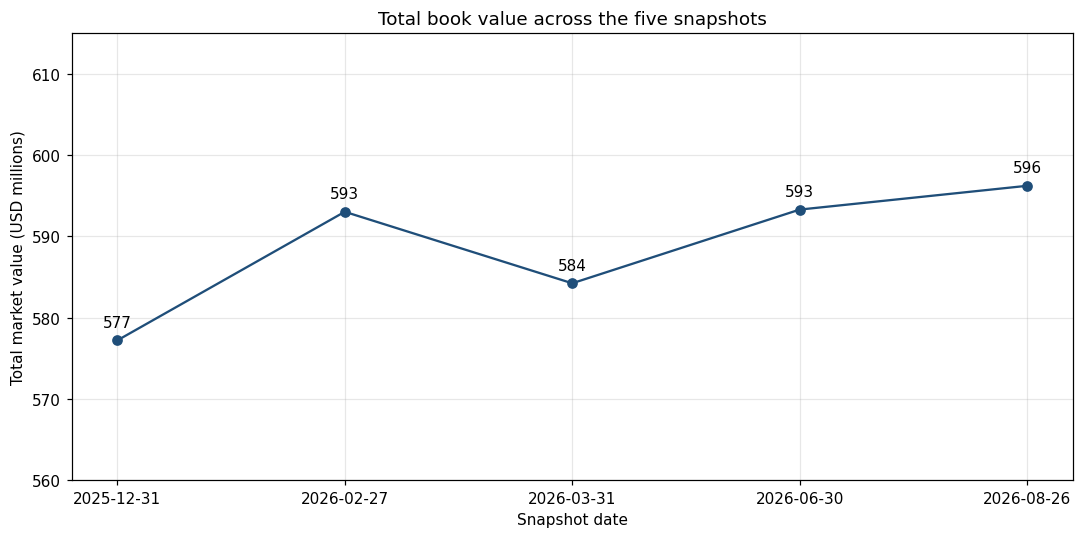

In [12]:
fig, ax = plt.subplots()
ax.plot(SNAPSHOTS, book.values / 1e6, marker="o", color="#1f4e79")
for x, y in zip(SNAPSHOTS, book.values / 1e6, strict=True):
    ax.annotate(f"{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 9), ha="center")
ax.set_title("Total book value across the five snapshots")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Total market value (USD millions)")
ax.set_ylim(560, 615)
plt.tight_layout()
plt.show()

,usd_m_start,usd_m_end,change_pct
asset_class,,,
Cash and Equivalents,50.5,49.0,-2.9
Fixed Income,150.8,139.0,-7.8
Equity,246.2,262.3,6.5
Alternatives,111.1,111.4,0.3
Commodities,15.4,17.5,13.5
Structured Products,3.2,17.0,432.4


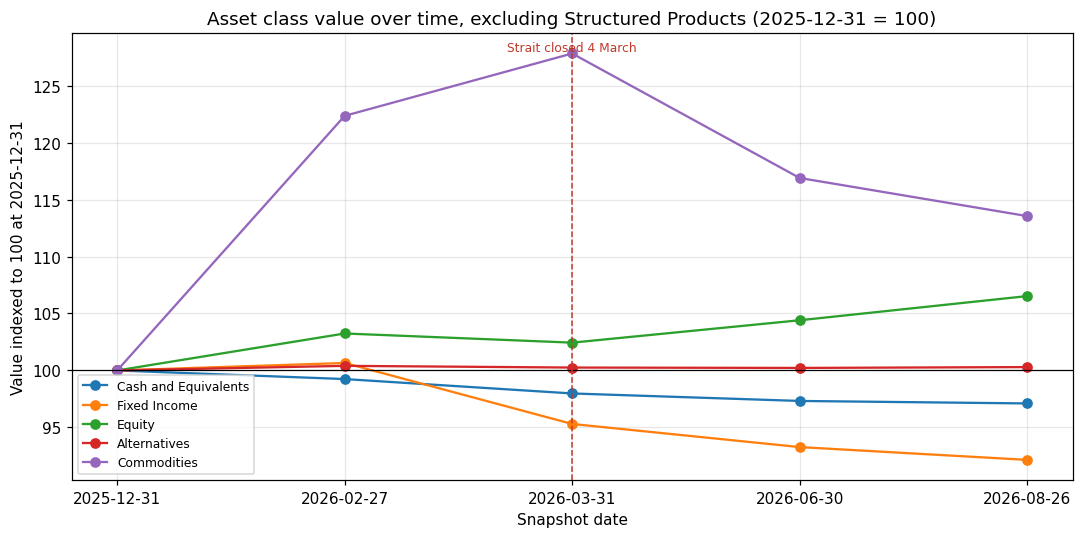

Structured Products is off this chart: its +432% value growth is dominated by six subscriptions and includes their subsequent mark changes.


In [13]:
by_class = holdings.pivot_table(
    index="snapshot_date", columns="asset_class", values="market_value_usd", aggfunc="sum"
).reindex(index=SNAPSHOTS, columns=ASSET_CLASSES)

summary = pd.DataFrame(
    {
        "usd_m_start": (by_class.loc[FIRST] / 1e6).round(1),
        "usd_m_end": (by_class.loc[LAST] / 1e6).round(1),
        "change_pct": ((by_class.loc[LAST] / by_class.loc[FIRST] - 1) * 100).round(1),
    }
)
display(summary)

# Structured Products is left off the chart: its +432% value growth is dominated by six
# subscriptions and includes their subsequent mark changes,
# and plotting it flattens every other series into an unreadable band. Its numbers are in the
# table above, and section 11 explains why it grew.
priced_classes = [c for c in ASSET_CLASSES if c != "Structured Products"]
indexed = by_class / by_class.loc[FIRST] * 100

fig, ax = plt.subplots()
for column in priced_classes:
    ax.plot(SNAPSHOTS, indexed[column], marker="o", label=column)
ax.axhline(100, color="black", linewidth=0.8)
ax.axvline("2026-03-31", color="#c0392b", linestyle="--", linewidth=1)
ax.annotate(
    "Strait closed 4 March",
    xy=("2026-03-31", 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(0, -12),
    textcoords="offset points",
    fontsize=8,
    color="#c0392b",
    ha="center",
)
ax.set_title("Asset class value over time, excluding Structured Products (2025-12-31 = 100)")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Value indexed to 100 at 2025-12-31")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()
print(
    "Structured Products is off this chart: its +432% value growth is dominated by "
    "six subscriptions and includes their subsequent mark changes."
)

In [14]:
def client_instrument_snapshot(snapshot):
    frame = holdings[holdings["snapshot_date"] == snapshot]
    grouped = frame.groupby(["client_id", "portfolio_id", "instrument_id"]).agg(
        qty=("quantity", "sum"),
        px=("price_local", "first"),
        mv_usd=("market_value_usd", "sum"),
        mv_local=("market_value_local", "sum"),
    )
    grouped["usd_per_local"] = grouped["mv_usd"] / grouped["mv_local"]
    return grouped


start, end = client_instrument_snapshot(FIRST), client_instrument_snapshot(LAST)
joined = start.join(end, lsuffix="_s", rsuffix="_e", how="outer")
joined["usd_per_local_s"] = joined["usd_per_local_s"].fillna(joined["usd_per_local_e"])
joined["usd_per_local_e"] = joined["usd_per_local_e"].fillna(joined["usd_per_local_s"])
joined["px_s"] = joined["px_s"].fillna(joined["px_e"])
joined["px_e"] = joined["px_e"].fillna(joined["px_s"])
joined[["qty_s", "qty_e", "mv_usd_s", "mv_usd_e"]] = joined[
    ["qty_s", "qty_e", "mv_usd_s", "mv_usd_e"]
].fillna(0)
joined["quantity_added"] = joined["qty_e"] - joined["qty_s"]
assert (joined["quantity_added"] >= 0).all(), "Disposals require lot/flow attribution"
joined["price_effect"] = (
    joined["qty_s"] * (joined["px_e"] - joined["px_s"]) * joined["usd_per_local_s"]
)
joined["fx_effect"] = (
    joined["qty_s"] * joined["px_e"] * (joined["usd_per_local_e"] - joined["usd_per_local_s"])
)
joined["addition_end_value"] = joined["quantity_added"] * joined["px_e"] * joined["usd_per_local_e"]
joined["total"] = joined["mv_usd_e"] - joined["mv_usd_s"]

transaction_values = transactions.loc[
    transactions["trade_date"].between(FIRST, LAST) & (transactions["settlement_date"] <= LAST)
].copy()
transaction_values["amount_usd"] = [
    to_usd(amount, currency)
    for amount, currency in zip(
        transaction_values["amount"], transaction_values["currency"], strict=True
    )
]
transaction_values["amount_base"] = [
    amount / to_usd(1, BASE_CCY[client_id])
    for amount, client_id in zip(
        transaction_values["amount_usd"], transaction_values["client_id"], strict=True
    )
]
purchases = transaction_values.loc[
    transaction_values["transaction_type"].isin(["Buy", "Structured Product Subscription"])
].copy()
purchases["purchase_cost_usd"] = -purchases["amount_usd"]
assert (purchases["purchase_cost_usd"] > 0).all()
purchase_totals = purchases.groupby(["client_id", "portfolio_id", "instrument_id"]).agg(
    purchased_quantity=("quantity", "sum"), purchase_cost_usd=("purchase_cost_usd", "sum")
)
assert set(purchase_totals.index) == set(joined.index[joined["quantity_added"] > 0])
joined = joined.join(purchase_totals).fillna({"purchased_quantity": 0, "purchase_cost_usd": 0})
np.testing.assert_allclose(joined["quantity_added"], joined["purchased_quantity"])
joined["new_position_effect"] = joined["purchase_cost_usd"]
joined["post_purchase_effect"] = joined["addition_end_value"] - joined["purchase_cost_usd"]
component_columns = ["price_effect", "fx_effect", "new_position_effect", "post_purchase_effect"]
np.testing.assert_allclose(joined[component_columns].sum(axis=1), joined["total"], atol=0.02)
effects = joined[component_columns + ["total"]].sum()
contribution = effects / book.loc[FIRST] * 100
DECOMPOSITION = joined
display(pd.DataFrame({"usd_m": effects / 1e6, "contribution_pp": contribution}).round(3))
display(purchases[["transaction_id", "client_id", "instrument_id", "purchase_cost_usd"]])
print("Purchase costs translated at current FX; trade-date FX is not available.")
print(f"Same-store USD change: {contribution['price_effect'] + contribution['fx_effect']:+.2f}%.")
print("Excludes the new positions' own moves since purchase. Reported marks, not total return.")

INCOME_TYPES = ["Dividend", "Coupon", "Interest", "Distribution"]
FEE_TYPES = ["Management Fee"]
income_rows = transaction_values[transaction_values["transaction_type"].isin(INCOME_TYPES)]
fee_rows = transaction_values[transaction_values["transaction_type"].isin(FEE_TYPES)]
financing_rows = transaction_values[transaction_values["transaction_type"] == "Interest Charge"]
income_summary = pd.DataFrame(index=pd.Index(clients["client_id"], name="client_id"))
for currency_measure in ["usd", "base"]:
    income_summary[f"income_{currency_measure}"] = income_rows.groupby("client_id")[
        f"amount_{currency_measure}"
    ].sum()
    income_summary[f"fees_{currency_measure}"] = -fee_rows.groupby("client_id")[
        f"amount_{currency_measure}"
    ].sum()
    income_summary[f"financing_interest_{currency_measure}"] = -financing_rows.groupby("client_id")[
        f"amount_{currency_measure}"
    ].sum()
income_summary = income_summary.fillna(0)
income_summary["client_name"] = income_summary.index.map(NAME)
income_summary["base_ccy"] = income_summary.index.map(BASE_CCY)
income_summary["disclosure"] = "Not reconciled to positions; translated at current FX"
assert len(purchases) == 7
assert income_summary.loc["CL-0012", "income_usd"] > 1_100_000
management_fees_usd = -transaction_values.loc[
    transaction_values["transaction_type"] == "Management Fee", "amount_usd"
].sum()
display(income_summary.round(2))
print(f"Book management fees paid: USD {management_fees_usd:,.0f}; excludes interest charges.")

,usd_m,contribution_pp
price_effect,12.624,2.187
fx_effect,-8.258,-1.431
new_position_effect,15.336,2.657
post_purchase_effect,-0.680,-0.118
total,19.021,3.295


,transaction_id,client_id,instrument_id,purchase_cost_usd
1,TXN-0002,CL-0014,SYN-SP-0503,3.201024e+06
2,TXN-0001,CL-0007,SYN-CM-0402,9.568000e+05
6,TXN-0003,CL-0015,SYN-SP-0501,1.800000e+06
194,TXN-0004,CL-0001,SYN-SP-0505,1.536492e+06
196,TXN-0005,CL-0019,SYN-SP-0505,3.841229e+06
198,TXN-0006,CL-0002,SYN-SP-0502,1.500000e+06
199,TXN-0007,CL-0013,SYN-SP-0502,2.500000e+06


Purchase costs translated at current FX; trade-date FX is not available.
Same-store USD change: +0.76%.
Excludes the new positions' own moves since purchase. Reported marks, not total return.


,income_usd,fees_usd,financing_interest_usd,income_base,fees_base,financing_interest_base,client_name,base_ccy,disclosure
client_id,,,,,,,,,
CL-0001,633901.39,122327.61,159763.31,857034.68,165386.93,216000.0,Hartono Wijaya Kusuma,SGD,Not reconciled to positions; translated at current FX
CL-0002,211222.60,60517.27,173737.50,211222.60,60517.27,173737.5,Ravi Chandrasekaran,USD,Not reconciled to positions; translated at current FX
CL-0003,362039.90,60146.55,0.00,331538.37,55079.26,0.0,Margarethe Voss-Brenner,EUR,Not reconciled to positions; translated at current FX
CL-0004,1546936.63,144887.85,0.00,1546936.63,144887.85,0.0,Chalermchai Suphanburi,USD,Not reconciled to positions; translated at current FX
CL-0005,447757.42,81152.88,0.00,605368.04,109718.70,0.0,Aishah binti Rahman,SGD,Not reconciled to positions; translated at current FX
CL-0006,626073.28,49989.43,0.00,846451.07,67585.71,0.0,Nguyen Thi Bao Tran,SGD,Not reconciled to positions; translated at current FX
CL-0007,724319.04,170761.13,0.00,724319.04,170761.13,0.0,Alistair Pemberton-Hale,USD,Not reconciled to positions; translated at current FX
CL-0008,342179.44,32486.96,0.00,462626.61,43922.37,0.0,Chen Wei Ling,SGD,Not reconciled to positions; translated at current FX
CL-0009,749701.88,85674.41,0.00,686540.18,78456.42,0.0,Andreas Lindqvist,EUR,Not reconciled to positions; translated at current FX


Book management fees paid: USD 1,782,688; excludes interest charges.


In [15]:
# The authoritative 2026 event record. Everything we say about causes must trace back to a row here.
events[["event_date", "event_type", "region", "severity", "primary_transmission"]]

,event_date,event_type,region,severity,primary_transmission
0,2025-12-31,Market,Global,High,"Gold, precious metals miners, inflation hedges"
1,2026-01-26,Market,Global,High,"Gold, precious metals"
2,2026-01-28,Market,Global,High,"Gold, precious metals"
3,2026-02-28,Geopolitical,Middle East,Severe,"Energy, defence, airlines, EM credit, safe havens"
4,2026-03-02,Market,Global,High,"Energy, transport, shipping"
5,2026-03-04,Geopolitical,Middle East,Severe,"Energy, LNG, shipping, Gulf credit, airlines"
6,2026-03-11,Policy,Global,High,"Energy, oil-linked structured products"
7,2026-03-12,Market,Global,Severe,"Energy, inflation-sensitive assets"
8,2026-04-30,Policy,Europe,Medium,"European fixed income, EUR assets"
9,2026-05-04,Market,Global,High,"Energy, transport"


In [16]:
# The market backdrop at the same five dates, so moves can be tied to levels.
key_series = ["BRENT_USD_BBL", "GOLD_USD_OZ", "UST_10Y_PCT", "VIX", "SPX", "US_CPI_YOY_PCT"]
market[market["series_id"].isin(key_series)].pivot_table(
    index="series_id", columns="snapshot_date", values="value"
).reindex(index=key_series, columns=SNAPSHOTS)

snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
series_id,,,,,
BRENT_USD_BBL,69.00,72.40,104.00,96.00,101.50
GOLD_USD_OZ,4310.00,5050.00,5240.00,4780.00,4622.60
UST_10Y_PCT,4.05,3.95,4.35,4.52,4.66
VIX,15.20,17.80,31.40,22.60,25.10
SPX,6902.00,7180.00,7050.00,7410.00,7530.00
US_CPI_YOY_PCT,2.70,2.90,3.40,4.20,4.00


In [17]:
# Which instruments actually moved, and in which direction.
prices = instruments.set_index("instrument_id")[[f"price_{d}" for d in SNAPSHOTS]]
moves = pd.DataFrame(
    {
        "instrument_name": instruments.set_index("instrument_id")["instrument_name"],
        "sector": instruments.set_index("instrument_id")["sector"],
        "to_31_mar_pct": (prices[f"price_{SNAPSHOTS[2]}"] / prices[f"price_{FIRST}"] - 1) * 100,
        "full_period_pct": (prices[f"price_{LAST}"] / prices[f"price_{FIRST}"] - 1) * 100,
    }
).round(1)

print("BIGGEST FALLERS")
display(moves.sort_values("full_period_pct").head(7))
print("BIGGEST RISERS")
display(moves.sort_values("full_period_pct").tail(7).iloc[::-1])

BIGGEST FALLERS


,instrument_name,sector,to_31_mar_pct,full_period_pct
instrument_id,,,,
SYN-SP-0503,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Real Estate,-23.6,-41.7
SYN-FI-0207,Golden Harbour Properties 5.25% Perpetual,Real Estate,-16.4,-31.1
SYN-ST-0106,Golden Harbour Properties Ltd,Real Estate,-14.5,-24.2
SYN-FI-0201,US Treasury 2.375% due 2045,Sovereign,-8.2,-14.9
SYN-FI-0206,Pacific Rim Bank 4.75% Perpetual,Financials,-7.6,-12.6
SYN-EQ-0010,Global Luxury and Consumer Brands Fund,Consumer Discretionary,-5.8,-9.1
SYN-FI-0205,Asia High Yield Bond Fund,Corporate,-5.9,-8.4


BIGGEST RISERS


,instrument_name,sector,to_31_mar_pct,full_period_pct
instrument_id,,,,
SYN-ST-0101,Bara Nusantara Energy Tbk,Energy,35.9,34.2
SYN-EQ-0007,Global Defence and Aerospace Equity Fund,Industrials,24.0,34.0
SYN-ST-0104,Pacific Orient Shipping Ltd,Industrials,26.6,28.6
SYN-EQ-0008,Global Energy Majors Equity Fund,Energy,28.0,26.5
SYN-EQ-0025,Asia Pacific Shipping and Logistics Fund,Industrials,19.0,20.1
SYN-CM-0403,Broad Commodity Index Fund,Diversified,20.6,19.3
SYN-ST-0103,Helios Cloud Systems Inc,Information Technology,5.2,18.5


## 4. Per-client allocation and drift

**What we check.** Household allocations across snapshots, and the change in the value of the
quantities held at baseline in each client's own reporting currency. New positions and quantity
increases are excluded from the same-store series at every snapshot.

**What we found.** The corrected same-store changes are approximately **Al-Mansoori +9.7%,
Kim +9.2%, Hartono +19.0%, and Zhang +10.2%**. These exclude new positions' own moves since purchase;
the separately displayed cost decomposition accounts for those moves. A household value increase
caused by a subscription must not be called performance.

The two Income clients' reported-mark changes remain negative: Cheung about -7.0% and Chalermchai
about -6.6%. They also received material income, shown beside those changes below. This is a
price/income conversation, not evidence that their portfolios delivered those losses as total returns.
The snapshot drawdown measures only declines observed at five dates, not continuous maximum drawdown
or realized volatility. Stale private marks can suppress observed drawdown and must be disclosed.

Base currency and USD aggregation answer different questions. The FX translation component is not
a separate cash debit. It can still represent economic exposure for a client spending in another
currency; never say that an FX loss is one that “nobody actually lost.”

> **Pipeline action.** Keep household allocation for context. Apply mandate rules separately per
> managed portfolio. Publish same-store base/USD changes, income and fees, observation dates,
> excluded additions, and valuation limitations together. Document client-directed subscriptions
> using their transaction and RM note evidence instead of inferring intent from any trade.

In [18]:
household = holdings.groupby(["client_id", "snapshot_date", "asset_class"], as_index=False)[
    "market_value_usd"
].sum()
household_total = (
    holdings.groupby(["client_id", "snapshot_date"], as_index=False)["market_value_usd"]
    .sum()
    .rename(columns={"market_value_usd": "household_total_usd"})
)
household = household.merge(household_total, on=["client_id", "snapshot_date"])
household["pct"] = household["market_value_usd"] / household["household_total_usd"] * 100

allocation = (
    household.pivot_table(index=["client_id", "asset_class"], columns="snapshot_date", values="pct")
    .reindex(columns=SNAPSHOTS)
    .fillna(0.0)
)
allocation["drift_pp"] = allocation[LAST] - allocation[FIRST]
allocation = allocation.reset_index()
allocation.insert(1, "client_name", allocation["client_id"].map(NAME))

top_drift = allocation.reindex(
    allocation["drift_pp"].abs().sort_values(ascending=False).index
).head(12)
top_drift[["client_id", "client_name", "asset_class", FIRST, LAST, "drift_pp"]].round(2)

snapshot_date,client_id,client_name,asset_class,2025-12-31,2026-08-26,drift_pp
86,CL-0019,Abdullah Al-Mansoori,Structured Products,0.00,12.90,12.90
68,CL-0015,Kim Do-Yoon,Structured Products,0.00,12.84,12.84
57,CL-0013,Zhang Meiling,Structured Products,0.00,7.09,7.09
62,CL-0014,Lau Chi Ming,Structured Products,0.00,7.05,7.05
61,CL-0014,Lau Chi Ming,Fixed Income,50.55,44.19,-6.36
66,CL-0015,Kim Do-Yoon,Equity,52.84,46.60,-6.24
85,CL-0019,Abdullah Al-Mansoori,Fixed Income,21.06,15.67,-5.38
84,CL-0019,Abdullah Al-Mansoori,Equity,63.02,57.97,-5.04
6,CL-0002,Ravi Chandrasekaran,Alternatives,72.88,68.35,-4.53
55,CL-0013,Zhang Meiling,Equity,80.13,75.73,-4.39


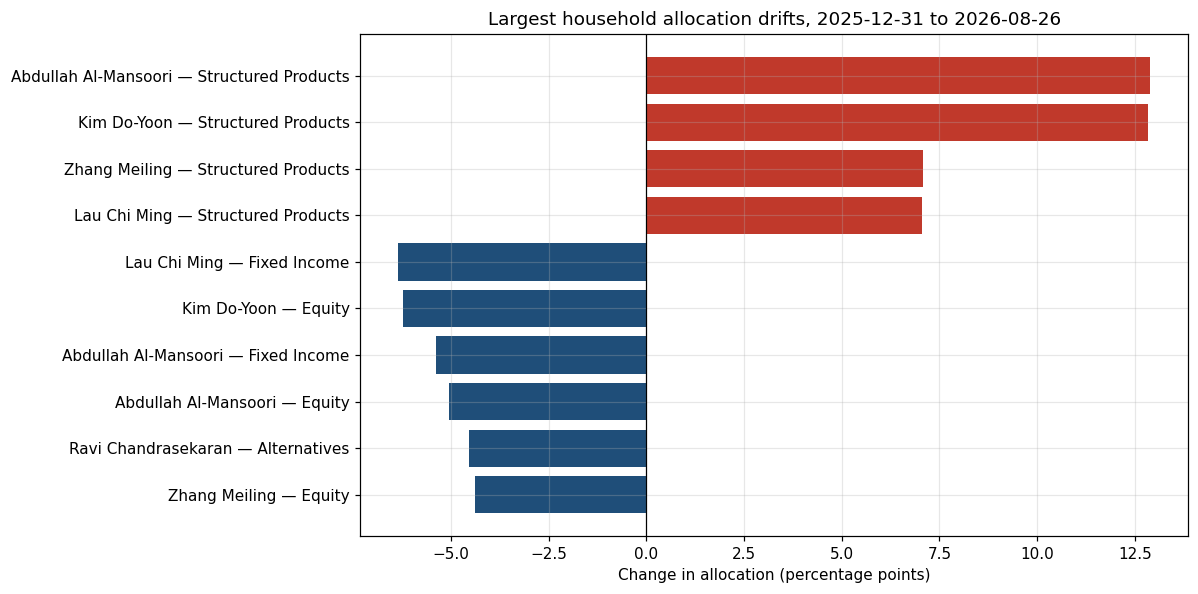

In [19]:
labels = [f"{r.client_name} — {r.asset_class}" for r in top_drift.head(10).itertuples()]
values = top_drift.head(10)["drift_pp"].to_numpy()

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.barh(labels[::-1], values[::-1], color=["#c0392b" if v > 0 else "#1f4e79" for v in values[::-1]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Largest household allocation drifts, 2025-12-31 to 2026-08-26")
ax.set_xlabel("Change in allocation (percentage points)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
baseline_quantities = holdings.loc[
    holdings["snapshot_date"] == FIRST, ["client_id", "portfolio_id", "instrument_id", "quantity"]
].rename(columns={"quantity": "baseline_quantity"})
same_store_positions = holdings.merge(
    baseline_quantities,
    on=["client_id", "portfolio_id", "instrument_id"],
    how="left",
    validate="many_to_one",
)
same_store_positions["baseline_quantity"] = same_store_positions["baseline_quantity"].fillna(0)
assert (same_store_positions["quantity"] > 0).all()
for measure in ["base", "usd"]:
    same_store_positions[f"same_store_{measure}"] = (
        same_store_positions["market_value_" + measure]
        * same_store_positions["baseline_quantity"]
        / same_store_positions["quantity"]
    )
same_store_base_values = (
    same_store_positions.groupby(["client_id", "snapshot_date"])["same_store_base"]
    .sum()
    .unstack()
    .reindex(columns=SNAPSHOTS)
)
same_store_usd_values = (
    same_store_positions.groupby(["client_id", "snapshot_date"])["same_store_usd"]
    .sum()
    .unstack()
    .reindex(columns=SNAPSHOTS)
)
base_totals = (
    holdings.groupby(["client_id", "snapshot_date"])["market_value_base"]
    .sum()
    .unstack()
    .reindex(columns=SNAPSHOTS)
)
usd_totals = (
    holdings.groupby(["client_id", "snapshot_date"])["market_value_usd"]
    .sum()
    .unstack()
    .reindex(columns=SNAPSHOTS)
)
performance = pd.DataFrame(
    {
        "client_name": pd.Series(NAME),
        "base_ccy": pd.Series(BASE_CCY),
        "risk_profile": clients.set_index("client_id")["risk_profile"],
        "usd_m_now": usd_totals[LAST] / 1e6,
        "return_usd_pct": (same_store_usd_values[LAST] / same_store_usd_values[FIRST] - 1) * 100,
        "return_base_ccy_pct": (same_store_base_values[LAST] / same_store_base_values[FIRST] - 1)
        * 100,
        "snapshot_max_drawdown_pct": (
            same_store_base_values / same_store_base_values.cummax(axis=1) - 1
        ).min(axis=1)
        * 100,
    }
)
performance["fx_gap_pp"] = performance["return_usd_pct"] - performance["return_base_ccy_pct"]
performance = performance.join(income_summary[["income_base", "fees_base"]])
expected_returns = {"CL-0019": 9.7, "CL-0015": 9.2, "CL-0001": 19.0, "CL-0013": 10.2}
for client_id, expected_return in expected_returns.items():
    assert abs(performance.loc[client_id, "return_base_ccy_pct"] - expected_return) < 0.1
print("Same-store reported-mark changes; excludes new positions' own moves since purchase.")
print("Income/fees are not reconciled to positions and use current FX; no validated total return.")
display(performance.sort_values("return_base_ccy_pct").round(2))

Same-store reported-mark changes; excludes new positions' own moves since purchase.
Income/fees are not reconciled to positions and use current FX; no validated total return.


,client_name,base_ccy,risk_profile,usd_m_now,return_usd_pct,return_base_ccy_pct,snapshot_max_drawdown_pct,fx_gap_pp,income_base,fees_base
CL-0014,Lau Chi Ming,HKD,Balanced,26.49,-12.63,-12.40,-12.95,-0.22,8424282.68,598061.16
CL-0012,Cheung Kwok Wing,USD,Income,28.03,-6.98,-6.98,-8.20,0.00,1145819.55,121818.61
CL-0004,Chalermchai Suphanburi,USD,Income,33.45,-6.61,-6.61,-7.64,0.00,1546936.63,144887.85
CL-0011,Tan Boon Huat,SGD,Conservative,35.34,-6.73,-2.25,-3.17,-4.48,1604117.51,133057.47
CL-0006,Nguyen Thi Bao Tran,SGD,Balanced,18.07,-6.09,-1.58,-2.95,-4.51,846451.07,67585.71
CL-0003,Margarethe Voss-Brenner,EUR,Conservative,22.18,-5.68,0.19,-4.71,-5.87,331538.37,55079.26
CL-0009,Andreas Lindqvist,EUR,Balanced,31.61,-4.02,1.96,-1.43,-5.98,686540.18,78456.42
CL-0018,Elena Marchetti-Wong,EUR,Balanced,22.60,-3.99,1.99,-2.11,-5.98,511069.01,57028.04
CL-0017,Fong Enterprises Family Office,USD,Balanced,87.90,2.81,2.81,-1.14,0.00,2439516.77,277729.43
CL-0002,Ravi Chandrasekaran,USD,Growth,46.70,3.04,3.04,-1.01,0.00,211222.60,60517.27


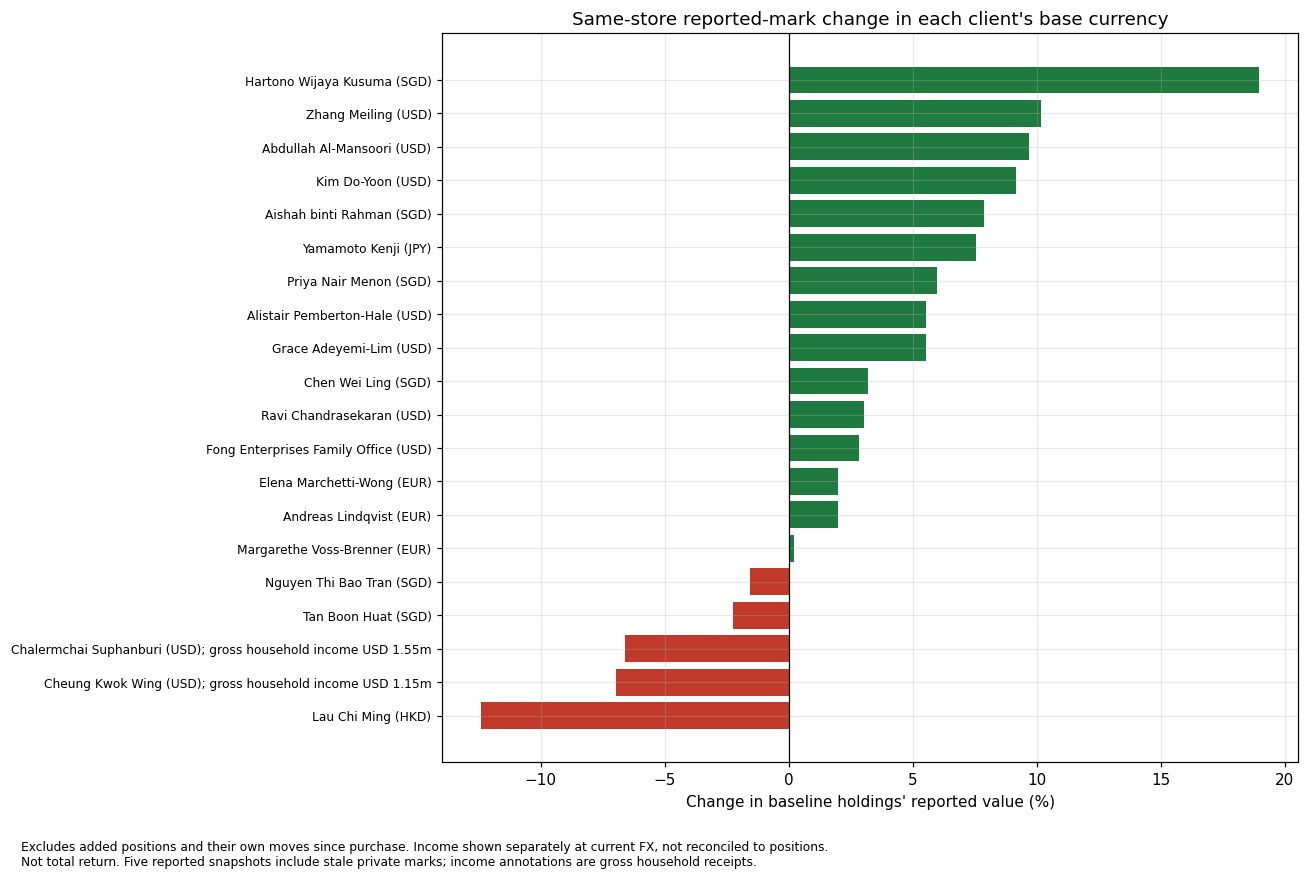

In [21]:
ranked_performance = performance.sort_values("return_base_ccy_pct")
figure, axis = plt.subplots(figsize=(12, 8))
plot_labels = []
for client_id, client_row in ranked_performance.iterrows():
    label = f"{client_row['client_name']} ({client_row['base_ccy']})"
    if client_id in ["CL-0012", "CL-0004"]:
        label += (
            f"; gross household income USD {income_summary.loc[client_id, 'income_usd'] / 1e6:.2f}m"
        )
    plot_labels.append(label)
axis.barh(
    plot_labels,
    ranked_performance["return_base_ccy_pct"],
    color=[
        "#c0392b" if change < 0 else "#1f7a3f"
        for change in ranked_performance["return_base_ccy_pct"]
    ],
)
axis.axvline(0, color="black", linewidth=0.8)
axis.set_title("Same-store reported-mark change in each client's base currency")
axis.set_xlabel("Change in baseline holdings' reported value (%)")
axis.tick_params(axis="y", labelsize=8)
figure.text(
    0.02,
    0.01,
    "Excludes added positions and their own moves since purchase. "
    "Income shown separately at current FX, not reconciled to positions.\n"
    "Not total return. Five reported snapshots include stale private marks; "
    "income annotations are gross household receipts.",
    fontsize=8,
)
figure.tight_layout(rect=(0, 0.055, 1, 1))
plt.show()

## 5. Mandate compliance

**Definition.** Test each MANAGED Portfolio against its own Mandate, using
`market_value_base`. Household allocation is context only and is never tested against
a Mandate band. Custody Portfolios are excluded. The grid includes all six asset classes
for every managed Portfolio, including classes held at zero.

**Three tests.** Allocation outside a min/max band flags (over 10 percentage points
escalates); every position marked `concentration_limit_applies = Y` above its
Portfolio's single-position limit flags, with escalation only above 2 percentage points
over the limit; any positive holding of a sustainability-excluded instrument in a
binding-exclusion Mandate escalates at any weight. These are separate compliance tests.

There are **14 band breaches across nine Clients, 13 single-position breaches, and two
binding-exclusion breaches**. Margarethe holds 71.46% Equity against a 30% cap and
9.15% Fixed Income against a 45% floor. Aishah's excluded holdings total 21.30%:
Global Energy Majors 11.13% and Sunrise Palm 10.17%.

**Classification and action.** N-010 documents Pemberton-Hale's commodities waiver:
retain the finding, monitor, and confirm the waiver remains current. N-005 documents
Margarethe's no-change instruction; N-013 documents Lindqvist's delayed deployment and
retention of Nordvind. Those findings remain active and require documented advice and
re-solicitation. An instruction is not a waiver. Other findings use a provisional
`drift` routing category pending RM review; this does not assert a proven cause.
Every row contains a nullable `note_id` and explains whether supporting documentation
was located. Missing notes are never invented.

Aishah's exclusions are specifically **documentation failures, not market drift**.
N-008 records her lack of awareness; it is not an instruction to override the policy.
They escalate regardless of weight or the provisional routing classification. Human review
must establish how excluded instruments entered a binding Mandate.

> **Pipeline action.** Carry Portfolio, Mandate, calculation basis, classification,
> classification status, action and Evidence on every finding. A waiver never removes
> the numerical breach. The 10pp band and 2pp position escalation thresholds are demo
> policy choices, not regulatory thresholds. This notebook does not decide legal
> compliance or execute a rebalance.


In [22]:
latest = holdings.loc[holdings["snapshot_date"] == TODAY].copy()
managed_portfolios = portfolios.loc[
    portfolios["service_model"] != "Custody",
    ["portfolio_id", "client_id", "mandate_code", "service_model"],
].copy()
assert mandates.groupby("mandate_code")["asset_class"].nunique().eq(6).all()
assert not mandates.duplicated(["mandate_code", "asset_class"]).any()

portfolio_total = (
    latest.groupby("portfolio_id", as_index=False)["market_value_base"]
    .sum()
    .rename(columns={"market_value_base": "portfolio_total"})
)
class_values = latest.groupby(["portfolio_id", "asset_class"], as_index=False)[
    "market_value_base"
].sum()
portfolio_alloc = (
    managed_portfolios.merge(mandates, on="mandate_code", validate="many_to_many")
    .merge(class_values, on=["portfolio_id", "asset_class"], how="left", validate="one_to_one")
    .merge(portfolio_total, on="portfolio_id", validate="many_to_one")
)
portfolio_alloc["market_value_base"] = portfolio_alloc["market_value_base"].fillna(0.0)
assert len(portfolio_alloc) == len(managed_portfolios) * 6
assert portfolio_alloc["portfolio_total"].gt(0).all()
portfolio_alloc["actual_pct"] = (
    portfolio_alloc["market_value_base"] / portfolio_alloc["portfolio_total"] * 100
)
portfolio_alloc["client_name"] = portfolio_alloc["client_id"].map(NAME)


def band_gap(actual, minimum, maximum):
    return max(actual - maximum, 0.0) + min(actual - minimum, 0.0)


assert band_gap(0, 5, 25) == -5
assert band_gap(5, 5, 25) == 0
assert band_gap(25, 5, 25) == 0

managed = portfolio_alloc.copy()
managed["over_max_pp"] = (managed["actual_pct"] - managed["max_pct"]).clip(lower=0)
managed["under_min_pp"] = (managed["actual_pct"] - managed["min_pct"]).clip(upper=0)
managed["gap_pp"] = managed["over_max_pp"] + managed["under_min_pp"]
breaches = managed.loc[managed["gap_pp"].ne(0)].copy()
breaches["direction"] = np.where(breaches["gap_pp"] > 0, "above max", "below min")
breaches["breach_type"] = "mandate_band_breach"
breaches["severity"] = np.where(breaches["gap_pp"].abs() > 10, "high", "medium")
breaches = breaches.reindex(breaches["gap_pp"].abs().sort_values(ascending=False).index)

note_lookup = notes.set_index("note_id")
CLASSIFICATION_MAP_VERSION = "rm-review-2026-09-05-v1"


def classify_mandate_breach(row):
    client_id = row["client_id"]
    breach_type = row["breach_type"]
    asset_class = row.get("asset_class")
    instrument_id = row.get("instrument_id")
    note_id = None
    classification = "drift"
    classification_status = "provisional: cause unestablished"
    action = "RM investigates cause and documents remediation advice"
    if client_id == "CL-0003":
        note_id, classification = "N-005", "client-directed"
    elif client_id == "CL-0007" and asset_class == "Commodities":
        note_id, classification = "N-010", "waiver-on-file"
    elif client_id == "CL-0009" and (
        (breach_type == "mandate_band_breach" and asset_class == "Cash and Equivalents")
        or instrument_id == "SYN-ST-0107"
    ):
        note_id, classification = "N-013", "client-directed"
    if note_id is not None:
        assert note_lookup.loc[note_id, "client_id"] == client_id
        classification_status = "documented context; RM confirms scope and currency"
        action = (
            "Monitor and confirm waiver current"
            if classification == "waiver-on-file"
            else "Alert stands; document advice and re-solicit the client instruction"
        )
    return pd.Series(
        {
            "classification": classification,
            "classification_status": classification_status,
            "note_id": note_id,
            "classification_basis": (
                f"RM note {note_id}"
                if note_id
                else "No supporting instruction or waiver located; not proven market drift"
            ),
            "classification_map_version": CLASSIFICATION_MAP_VERSION,
            "action": action,
        }
    )


breaches = pd.concat([breaches, breaches.apply(classify_mandate_breach, axis=1)], axis=1)


def mandate_evidence(row):
    selected = latest.loc[latest["portfolio_id"].eq(row["portfolio_id"])]
    instrument_id = row.get("instrument_id")
    evidence = [
        f"portfolios:{row['portfolio_id']}",
        f"mandates:{row['mandate_code']}:{row['asset_class'].lower().replace(' ', '-')}",
        *[
            f"holdings:{TODAY}:{position.portfolio_id}:{position.instrument_id}"
            for position in selected.itertuples()
        ],
    ]
    if isinstance(instrument_id, str):
        evidence.append(f"instruments:{instrument_id}")
    if isinstance(row.get("note_id"), str):
        evidence.append(f"rm_notes:{row['note_id']}")
    return evidence


breaches["evidence_ids"] = breaches.apply(mandate_evidence, axis=1)
position_compliance = (
    latest.merge(
        managed_portfolios.drop(columns="client_id"), on="portfolio_id", validate="many_to_one"
    )
    .merge(
        instruments[["instrument_id", "concentration_limit_applies"]],
        on="instrument_id",
        validate="many_to_one",
    )
    .merge(
        mandates[["mandate_code", "max_single_position_pct"]].drop_duplicates(),
        on="mandate_code",
        validate="many_to_one",
    )
    .merge(portfolio_total, on="portfolio_id", validate="many_to_one")
)
position_compliance["actual_pct"] = (
    position_compliance["market_value_base"] / position_compliance["portfolio_total"] * 100
)
assert np.allclose(
    position_compliance["actual_pct"], position_compliance["weight_pct"], atol=0.0001
)
position_compliance["gap_pp"] = (
    position_compliance["actual_pct"] - position_compliance["max_single_position_pct"]
)
single_position_breaches = position_compliance.loc[
    position_compliance["concentration_limit_applies"].eq("Y") & position_compliance["gap_pp"].gt(0)
].copy()
single_position_breaches["client_name"] = single_position_breaches["client_id"].map(NAME)
single_position_breaches["breach_type"] = "mandate_single_position_breach"
single_position_breaches["severity"] = np.where(
    single_position_breaches["gap_pp"].gt(2), "high", "medium"
)
single_position_breaches = pd.concat(
    [
        single_position_breaches,
        single_position_breaches.apply(classify_mandate_breach, axis=1),
    ],
    axis=1,
)
single_position_breaches["evidence_ids"] = single_position_breaches.apply(mandate_evidence, axis=1)
assert len(breaches) == 14 and breaches["client_id"].nunique() == 9
assert len(single_position_breaches) == 13
assert not (pd.Series([0.0, 2.0]) > 2).any()
assert (pd.Series([2.0001]) > 2).all()

print(f"Band breaches: {len(breaches)} across {breaches['client_id'].nunique()} Clients")
display(
    breaches[
        [
            "client_id",
            "client_name",
            "portfolio_id",
            "mandate_code",
            "asset_class",
            "actual_pct",
            "min_pct",
            "max_pct",
            "gap_pp",
            "severity",
            "classification",
            "note_id",
            "action",
        ]
    ].round(2)
)
print(f"Per-Portfolio single-position breaches: {len(single_position_breaches)}")
display(
    single_position_breaches[
        [
            "client_id",
            "portfolio_id",
            "instrument_name",
            "actual_pct",
            "max_single_position_pct",
            "gap_pp",
            "severity",
            "classification",
            "note_id",
            "action",
        ]
    ]
    .sort_values("gap_pp", ascending=False)
    .round(2)
)

Band breaches: 14 across 9 Clients


,client_id,client_name,portfolio_id,mandate_code,asset_class,actual_pct,min_pct,max_pct,gap_pp,severity,classification,note_id,action
14,CL-0003,Margarethe Voss-Brenner,PF-0005,CONS,Equity,71.46,10,30,41.46,high,client-directed,N-005,Alert stands; document advice and re-solicit the client instruction
13,CL-0003,Margarethe Voss-Brenner,PF-0005,CONS,Fixed Income,9.15,45,75,-35.85,high,client-directed,N-005,Alert stands; document advice and re-solicit the client instruction
63,CL-0011,Tan Boon Huat,PF-0013,CONS,Alternatives,47.28,0,15,32.28,high,drift,NaN,RM investigates cause and documents remediation advice
48,CL-0009,Andreas Lindqvist,PF-0011,BAL,Cash and Equivalents,44.98,2,18,26.98,high,client-directed,N-013,Alert stands; document advice and re-solicit the client instruction
61,CL-0011,Tan Boon Huat,PF-0013,CONS,Fixed Income,24.47,45,75,-20.53,high,drift,NaN,RM investigates cause and documents remediation advice
26,CL-0005,Aishah binti Rahman,PF-0007,SUSBAL,Equity,67.74,30,55,12.74,high,drift,NaN,RM investigates cause and documents remediation advice
92,CL-0016,Yamamoto Kenji,PF-0018,BAL,Equity,67.72,30,55,12.72,high,drift,NaN,RM investigates cause and documents remediation advice
49,CL-0009,Andreas Lindqvist,PF-0011,BAL,Fixed Income,14.45,25,50,-10.55,high,drift,NaN,RM investigates cause and documents remediation advice
40,CL-0007,Alistair Pemberton-Hale,PF-0009,BAL,Commodities,18.93,0,10,8.93,medium,waiver-on-file,N-010,Monitor and confirm waiver current
80,CL-0014,Lau Chi Ming,PF-0016,BAL,Equity,23.39,30,55,-6.61,medium,drift,NaN,RM investigates cause and documents remediation advice


Per-Portfolio single-position breaches: 13


,client_id,portfolio_id,instrument_name,actual_pct,max_single_position_pct,gap_pp,severity,classification,note_id,action
94,CL-0011,PF-0013,Asia Real Estate Opportunity Fund III,20.42,10.0,10.42,high,drift,NaN,RM investigates cause and documents remediation advice
160,CL-0017,PF-0020,Meridian Private Equity Fund VII,35.30,25.0,10.30,high,drift,NaN,RM investigates cause and documents remediation advice
18,CL-0003,PF-0005,Nordvind Industrial AB,18.37,10.0,8.37,high,client-directed,N-005,Alert stands; document advice and re-solicit the client instruction
93,CL-0011,PF-0013,Direct Property - Sentosa Cove Residence,18.32,10.0,8.32,high,drift,NaN,RM investigates cause and documents remediation advice
142,CL-0016,PF-0018,Kanto Pharma Holdings KK,20.10,12.0,8.10,high,drift,NaN,RM investigates cause and documents remediation advice
130,CL-0014,PF-0016,Direct Property - Mid-Levels Apartment,19.58,12.0,7.58,high,drift,NaN,RM investigates cause and documents remediation advice
125,CL-0014,PF-0016,Pacific Rim Bank 4.75% Perpetual,17.57,12.0,5.57,high,drift,NaN,RM investigates cause and documents remediation advice
78,CL-0009,PF-0011,Nordvind Industrial AB,17.19,12.0,5.19,high,client-directed,N-013,Alert stands; document advice and re-solicit the client instruction
161,CL-0017,PF-0020,Orchard Private Credit Fund II,27.96,25.0,2.96,high,drift,NaN,RM investigates cause and documents remediation advice
29,CL-0004,PF-0006,Pacific Rim Bank 4.75% Perpetual,11.38,10.0,1.38,medium,drift,NaN,RM investigates cause and documents remediation advice


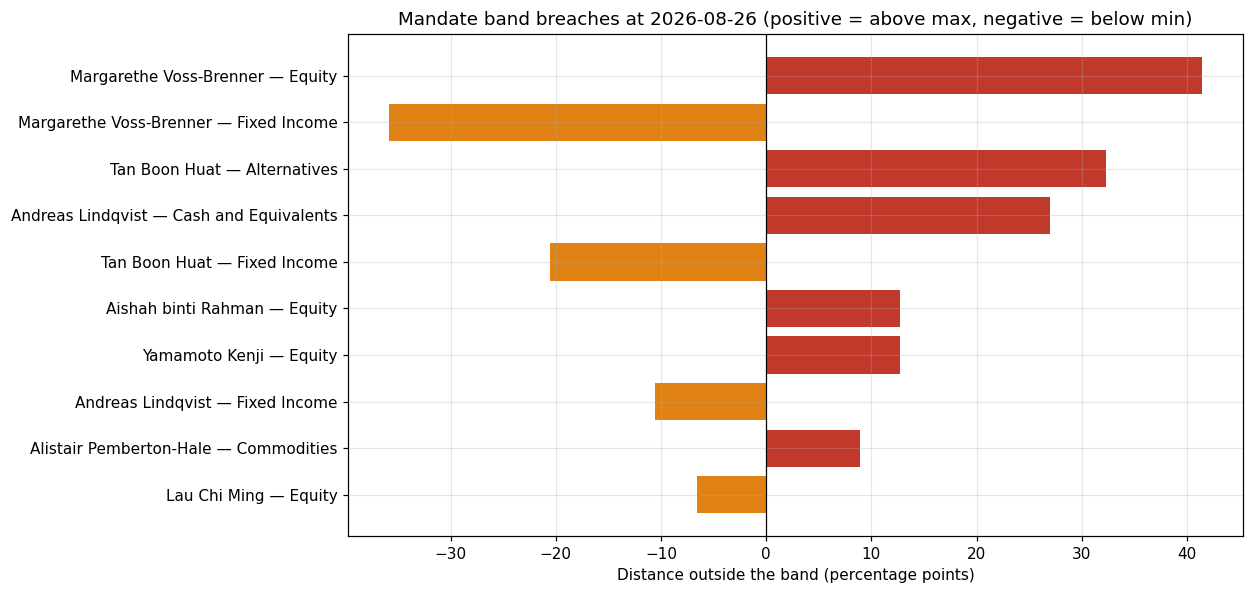

In [23]:
top_breaches = breaches.head(10).iloc[::-1]
labels = [f"{r.client_name} — {r.asset_class}" for r in top_breaches.itertuples()]

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.barh(
    labels,
    top_breaches["gap_pp"],
    color=["#c0392b" if v > 0 else "#e08214" for v in top_breaches["gap_pp"]],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Mandate band breaches at {TODAY} (positive = above max, negative = below min)")
ax.set_xlabel("Distance outside the band (percentage points)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [24]:
# GOLDEN NUMBER 1 — Margarethe Voss-Brenner, CL-0003. Source rows, unaggregated.
mv = latest[latest["client_id"] == "CL-0003"]
display(
    mv[
        [
            "portfolio_id",
            "instrument_id",
            "instrument_name",
            "asset_class",
            "instrument_ccy",
            "quantity",
            "price_local",
            "market_value_base",
            "weight_pct",
            "liquidity_tier",
        ]
    ].sort_values("market_value_base", ascending=False)
)

total_eur = mv["market_value_base"].sum()
equity_eur = mv.loc[mv["asset_class"] == "Equity", "market_value_base"].sum()
cons_equity_max = mandates.loc[
    (mandates["mandate_code"] == "CONS") & (mandates["asset_class"] == "Equity"), "max_pct"
].item()

print("portfolio           : PF-0005, mandate CONS (Conservative), Advisory")
print(f"total (EUR)         : {total_eur:,.2f}")
print(f"equity (EUR)        : {equity_eur:,.2f}")
print(f"equity share        : {equity_eur / total_eur * 100:.2f}%")
print(f"mandate equity max  : {cons_equity_max:.0f}%")
print(
    f"breach              : {equity_eur / total_eur * 100 - cons_equity_max:.2f} percentage points"
)
print(
    f"client risk profile : {clients.set_index('client_id').loc['CL-0003', 'risk_profile']}"
    f" (tolerance {clients.set_index('client_id').loc['CL-0003', 'risk_tolerance_score']}/10)"
)

,portfolio_id,instrument_id,instrument_name,asset_class,instrument_ccy,quantity,price_local,market_value_base,weight_pct,liquidity_tier
130,PF-0005,SYN-EQ-0010,Global Luxury and Consumer Brands Fund,Equity,EUR,22000,240.6,5293200.00,26.0590,Daily
131,PF-0005,SYN-ST-0107,Nordvind Industrial AB,Equity,EUR,9000,414.7,3732300.00,18.3745,Daily
132,PF-0005,SYN-EQ-0004,European Equity Fund,Equity,EUR,18000,184.5,3321000.00,16.3496,Daily
133,PF-0005,SYN-EQ-0003,US Technology Leaders Fund,Equity,USD,4000,592.1,2168864.47,10.6775,Daily
135,PF-0005,SYN-FI-0209,EUR Investment Grade Bond Fund,Fixed Income,EUR,20000,92.9,1858000.00,9.1471,Daily
136,PF-0005,SYN-AL-0304,Harborline Long Short Equity Fund,Alternatives,USD,1100,1274.0,1283333.33,6.3180,Monthly
134,PF-0005,SYN-SP-0506,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",Structured Products,USD,12000,99.6,1094505.49,5.3884,Illiquid
137,PF-0005,SYN-CA-0604,EUR Call Deposit,Cash and Equivalents,EUR,900000,1.0,900000.00,4.4308,Daily
138,PF-0005,SYN-CA-0605,CHF Call Deposit,Cash and Equivalents,CHF,600000,1.0,661192.00,3.2551,Daily


portfolio           : PF-0005, mandate CONS (Conservative), Advisory
total (EUR)         : 20,312,395.29
equity (EUR)        : 14,515,364.47
equity share        : 71.46%
mandate equity max  : 30%
breach              : 41.46 percentage points
client risk profile : Conservative (tolerance 2/10)


In [25]:
binding_exclusion_mandates = mandates.loc[
    mandates["mandate_notes"].str.contains("binding exclusions", case=False, na=False),
    "mandate_code",
].unique()
excl = latest.merge(
    instruments[["instrument_id", "sustainability_excluded"]],
    on="instrument_id",
    validate="many_to_one",
).merge(
    managed_portfolios.drop(columns="client_id"),
    on="portfolio_id",
    validate="many_to_one",
)
exclusion_breaches = excl.loc[
    excl["mandate_code"].isin(binding_exclusion_mandates)
    & excl["sustainability_excluded"].eq("Y")
    & excl["quantity"].gt(0)
].copy()
exclusion_breaches["client_name"] = exclusion_breaches["client_id"].map(NAME)
exclusion_breaches["breach_type"] = "mandate_exclusion_breach"
exclusion_breaches["severity"] = "high"
exclusion_breaches["classification"] = "drift"
exclusion_breaches["documentation_failure"] = True
exclusion_breaches["classification_status"] = (
    "provisional routing only; documentation failure, not proven market drift"
)
exclusion_breaches["note_id"] = exclusion_breaches["client_id"].map({"CL-0005": "N-008"})
exclusion_breaches["action"] = (
    "Escalate binding exclusion; reconcile policy, disclose mismatch, document remediation"
)
exclusion_breaches["evidence_ids"] = exclusion_breaches.apply(mandate_evidence, axis=1)
susbal_breach = exclusion_breaches.loc[exclusion_breaches["mandate_code"].eq("SUSBAL")].copy()
mandate_signals = pd.concat(
    [breaches, single_position_breaches, exclusion_breaches], ignore_index=True, sort=False
)
assert len(susbal_breach) == 2
assert np.isclose(susbal_breach["weight_pct"].sum(), 21.30, atol=0.01)
assert exclusion_breaches["severity"].eq("high").all()
assert (pd.Series([0.000001, 0.1, 100.0]) > 0).all()
display(
    exclusion_breaches[
        [
            "client_id",
            "client_name",
            "portfolio_id",
            "instrument_name",
            "market_value_base",
            "weight_pct",
            "severity",
            "classification_status",
            "note_id",
            "action",
        ]
    ].round(2)
)
print(f"Excluded weight in SUSBAL: {susbal_breach['weight_pct'].sum():.2f}%")

,client_id,client_name,portfolio_id,instrument_name,market_value_base,weight_pct,severity,classification_status,note_id,action
41,CL-0005,Aishah binti Rahman,PF-0007,Global Energy Majors Equity Fund,2919103.2,11.13,high,"provisional routing only; documentation failure, not proven market...",N-008,"Escalate binding exclusion; reconcile policy, disclose mismatch, d..."
42,CL-0005,Aishah binti Rahman,PF-0007,Sunrise Palm Resources Ltd,2667000.0,10.17,high,"provisional routing only; documentation failure, not proven market...",N-008,"Escalate binding exclusion; reconcile policy, disclose mismatch, d..."


Excluded weight in SUSBAL: 21.30%


## 6. Look-through and concentration

**What we check.** Aggregate each household, then join direct shares, bonds and structured-product references by economic issuer. Every instrument with `concentration_limit_applies = Y` defaults to its own instrument identity; reviewed same-issuer overrides group securities such as Golden Harbour shares, its perpetual and the accumulator. A household comparison with the tightest **managed** portfolio limit is a risk screen, not a finding of contractual non-compliance.

**Attribution method.** Each referenced issuer receives the note's **full current market value**, never its notional. Basket A, Basket C and the Asian-banks autocallable are worst-of baskets. The Helios note is single-underlying, the Golden Harbour product is a daily accumulator, and the gold note has maturity capital protection and 70% participation. This common screen is neither delta-adjusted exposure nor maximum loss. Cross-issuer rows double-count the same note and must **never be summed or plotted as a pie chart**.

The map in `notebooks/reference_maps.json` is versioned against the written RM review; individual mappings still require external human RM signoff before client use. Its limitations travel with each result: Global Energy Majors ADR is approximated by the diversified fund SYN-EQ-0008; Gulf Marine Services has no source instrument; SYN-SP-0506 names three Asian banking majors without identifying them. Missing basket constituents are **unscreenable**, not clean zero exposures.

**What we found.** Lau has 29.5% Golden Harbour economic exposure (shares 9.5%, perpetual 12.9%, accumulator 7.1%) against a 12% household reference limit, plus 17.6% in Pacific Rim Bank's perpetual. Chalermchai has 11.4% in that perpetual. Those issuer-default rows were missing previously. The direct Golden Harbour perpetual itself already exceeds Lau's limit, so this is not a collection of individually harmless positions.

Al-Mansoori's 12.9% Bara exposure and Kim's 12.8% Helios exposure have zero direct holdings. They now trigger an informational hidden-issuer Signal at **at least 10%**, independently of the limit. Hartono's Bara exposure remains 45.0%; Al-Mansoori's shipping exposure 24.3%; Zhang's Helios exposure 22.5%.

Lau's accumulator buys daily at HKD 17.20 and doubles below strike. The stock is 18.0% below strike (HKD 14.10 / 17.20). The review's 24% is the fall from the initial HKD 18.60 price, not the distance below strike. Its market value therefore **understates forward exposure**. Obtain the remaining accumulation notional from the term sheet. RM note N-018 also records HKD 4m of facility drawings funding accumulator settlements: borrowing partly finances the losses.

> **Pipeline action.** Ship versioned issuer, look-through and event maps with source evidence, explicit missing components and human review status. Emit direct and indirect market-value percentages separately, the informational hidden-issuer trigger, limit-screen excess, and data-completeness/action fields. Enforce non-summation across issuers.

In [26]:
# Which structured products exist, what they really reference, and who holds them.
lookthrough_source = instruments.loc[
    instruments["underlying_reference"].notna(),
    ["instrument_id", "instrument_name", "asset_class", "liquidity_tier", "underlying_reference"],
]
lookthrough_source

,instrument_id,instrument_name,asset_class,liquidity_tier,underlying_reference
44,SYN-AL-0308,Unlisted Holding - Aranya Technologies Pte Ltd,Alternatives,Illiquid,"Series D preference shares, last priced round Sep-2025"
46,SYN-CM-0401,Physical Gold Allocated Account,Commodities,Daily,"XAU spot, allocated, Singapore vault"
47,SYN-CM-0402,Gold Bullion ETF,Commodities,Daily,XAU spot
49,SYN-SP-0501,"Fixed Coupon Note ref. Basket A, 8.50% p.a., 12M",Structured Products,Illiquid,Worst-of basket: Global Energy Majors ADR / Gulf Marine Services /...
50,SYN-SP-0502,"Equity Linked Note ref. Helios Cloud Systems, 11.00% p.a., 6M",Structured Products,Illiquid,Single underlying: Helios Cloud Systems Inc
51,SYN-SP-0503,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Structured Products,Illiquid,"Daily accumulation at strike HKD 17.20, knock-out HKD 19.80, doubl..."
52,SYN-SP-0504,"Capital Protected Note ref. Gold, 24M",Structured Products,Illiquid,"Underlying: XAU spot, 100% capital protection at maturity, 70% par..."
53,SYN-SP-0505,"Fixed Coupon Note ref. Basket C, 9.20% p.a., 12M",Structured Products,Illiquid,Worst-of basket: Pacific Orient Shipping / Global Energy Majors AD...
54,SYN-SP-0506,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",Structured Products,Illiquid,"Worst-of basket: three Asian banking majors, autocall observation ..."


In [27]:
from hashlib import sha256

REFERENCE_MAPS = json.loads((DATA.parent / "notebooks" / "reference_maps.json").read_text())
MAP_VERSION = REFERENCE_MAPS["mapping_version"]
LOOKTHROUGH = {
    instrument_id: entry["underlying_ids"]
    for instrument_id, entry in REFERENCE_MAPS["lookthrough"].items()
}
instrument_lookup = instruments.set_index("instrument_id")
ISSUER = {
    row.instrument_id: row.instrument_id
    for row in instruments.itertuples()
    if row.concentration_limit_applies == "Y"
}
ISSUER.update(REFERENCE_MAPS["issuer_overrides"])
assert set(
    instruments.loc[instruments["concentration_limit_applies"].eq("Y"), "instrument_id"]
) <= set(ISSUER)
assert set(LOOKTHROUGH) == set(
    instruments.loc[instruments["asset_class"].eq("Structured Products"), "instrument_id"]
)
assert set(REFERENCE_MAPS["transmission_map"]) == set(events["primary_transmission"])

household_totals = latest.groupby("client_id")["market_value_usd"].sum()


def holding_evidence(frame):
    return [
        f"holdings:{row.snapshot_date}:{row.portfolio_id}:{row.instrument_id}"
        for row in frame.itertuples()
    ]


def currency_conversion_evidence(currency, snapshot_date=TODAY):
    if currency == "USD":
        return []
    series_id = f"{currency}USD" if f"{currency}USD" in FX.columns else f"USD{currency}"
    assert series_id in FX.columns
    return [f"market_context:{snapshot_date}:{series_id}"]


def exposure_pct(client_id, instrument_ids):
    frame = latest[latest["client_id"].eq(client_id) & latest["instrument_id"].isin(instrument_ids)]
    return frame["market_value_usd"].sum() / household_totals[client_id] * 100


def event_evidence_id(row):
    fields = (
        "event_date",
        "event_type",
        "region",
        "description",
        "primary_transmission",
        "severity",
    )
    canonical = json.dumps({field: row[field] for field in fields}, sort_keys=True, default=str)
    return f"event_log:{row['event_date']}:{sha256(canonical.encode()).hexdigest()[:16]}"


def channel_instrument_ids(channel):
    entry = REFERENCE_MAPS["channels"][channel]
    underlying_ids = set(entry["instrument_ids"])
    if "instrument_currency" in entry:
        underlying_ids.update(
            instruments.loc[
                instruments["currency"].eq(entry["instrument_currency"]), "instrument_id"
            ]
        )
    return underlying_ids | {
        note_id
        for note_id, references in LOOKTHROUGH.items()
        if underlying_ids.intersection(references)
    }


events_asof = events.loc[
    pd.to_datetime(events["event_date"]).between(pd.Timestamp(FIRST), pd.Timestamp(TODAY))
].copy()
events_asof["evidence_id"] = events_asof.apply(event_evidence_id, axis=1)
assert events_asof["evidence_id"].is_unique

lookthrough_rows = []
for client_id in sorted(latest["client_id"].unique()):
    for issuer in sorted(set(ISSUER.values())):
        members = [instrument_id for instrument_id, name in ISSUER.items() if name == issuer]
        cash_instruments = [
            instrument_id for instrument_id in members if instrument_id not in LOOKTHROUGH
        ]
        own_notes = [instrument_id for instrument_id in members if instrument_id in LOOKTHROUGH]
        referencing = [
            note_id
            for note_id, underlyings in LOOKTHROUGH.items()
            if note_id not in members
            and any(ISSUER.get(underlying) == issuer for underlying in underlyings)
        ]
        note_ids = sorted(set(own_notes + referencing))
        direct_pct = exposure_pct(client_id, cash_instruments)
        note_pct = exposure_pct(client_id, note_ids)
        if direct_pct + note_pct <= 0:
            continue
        held = latest.loc[
            latest["client_id"].eq(client_id)
            & latest["instrument_id"].isin(cash_instruments + note_ids)
        ]
        held_notes = sorted(set(held["instrument_id"]).intersection(LOOKTHROUGH))
        single_issuer = any(
            instrument_lookup.loc[instrument_id, "asset_class"] in ["Equity", "Fixed Income"]
            for instrument_id in cash_instruments
        )
        lookthrough_rows.append(
            {
                "client_id": client_id,
                "client_name": NAME[client_id],
                "issuer": issuer,
                "direct_pct": direct_pct,
                "via_structured_product_pct": note_pct,
                "lookthrough_pct": direct_pct + note_pct,
                "hidden_exposure_flag": bool(
                    single_issuer and direct_pct == 0 and direct_pct + note_pct >= 10
                ),
                "attribution_basis": "per_name_full_current_market_value_non_additive",
                "mapping_version": MAP_VERSION,
                "mapping_review_status": REFERENCE_MAPS["review_status"],
                "disclosures": [
                    REFERENCE_MAPS["lookthrough"][note_id]["disclosure"] for note_id in held_notes
                ],
                "evidence_ids": holding_evidence(latest.loc[latest["client_id"].eq(client_id)])
                + [
                    f"instruments:{instrument_id}"
                    for instrument_id in sorted(
                        set(held["instrument_id"])
                        | set().union(*(set(LOOKTHROUGH[note_id]) for note_id in held_notes))
                    )
                ],
            }
        )
lookthrough = pd.DataFrame(lookthrough_rows)
lookthrough["uplift_pp"] = lookthrough["lookthrough_pct"] - lookthrough["direct_pct"]

incomplete_lookthrough = []
for note_id, mapping in REFERENCE_MAPS["lookthrough"].items():
    if not mapping["missing_underlyings"]:
        continue
    for client_id, _held in latest.loc[latest["instrument_id"].eq(note_id)].groupby("client_id"):
        incomplete_lookthrough.append(
            {
                "client_id": client_id,
                "instrument_id": note_id,
                "household_pct": exposure_pct(client_id, [note_id]),
                "missing_underlyings": mapping["missing_underlyings"],
                "status": "unscreenable constituents, not zero exposure",
                "severity": "informational",
                "source": "data/instruments.csv underlying_reference",
                "disclosure": mapping["disclosure"],
                "mapping_review_status": REFERENCE_MAPS["review_status"],
                "action": "Request complete basket constituents and term sheet",
                "mapping_version": MAP_VERSION,
                "evidence_ids": holding_evidence(latest.loc[latest["client_id"].eq(client_id)])
                + [f"instruments:{note_id}"],
            }
        )
incomplete_lookthrough = pd.DataFrame(incomplete_lookthrough)
incomplete_lookthrough_signals = incomplete_lookthrough.copy()
accumulator_stock_price = float(instrument_lookup.loc["SYN-ST-0106", f"price_{LAST}"])
accumulator_forward_risk = {
    "instrument_id": "SYN-SP-0503",
    "strike_hkd": 17.20,
    "stock_price_hkd": accumulator_stock_price,
    "below_strike_pct": (1 - accumulator_stock_price / 17.20) * 100,
    "forward_exposure_understated": accumulator_stock_price < 17.20,
    "action": (
        "Obtain remaining daily accumulation notional and double-up obligations from the term sheet"
    ),
    "evidence_ids": ["instruments:SYN-SP-0503", "instruments:SYN-ST-0106", "rm_notes:N-018"],
}
assert (
    lookthrough.loc[lookthrough["hidden_exposure_flag"], "client_id"]
    .isin(["CL-0019", "CL-0015"])
    .all()
)
assert {"CL-0019", "CL-0015"} <= set(
    lookthrough.loc[lookthrough["hidden_exposure_flag"], "client_id"]
)
assert accumulator_forward_risk["forward_exposure_understated"]
assert "SYN-SP-0506" in set(incomplete_lookthrough["instrument_id"])
display(lookthrough.sort_values("lookthrough_pct", ascending=False).round(2))
display(incomplete_lookthrough)
display(pd.DataFrame([accumulator_forward_risk]))

,client_id,client_name,issuer,direct_pct,via_structured_product_pct,lookthrough_pct,hidden_exposure_flag,attribution_basis,mapping_version,mapping_review_status,disclosures,evidence_ids,uplift_pp
5,CL-0002,Ravi Chandrasekaran,SYN-AL-0308,68.35,0.00,68.35,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0003:SYN-EQ-0003, holdings:2026-08-26:PF-0...",0.00
0,CL-0001,Hartono Wijaya Kusuma,Bara Nusantara Energy,41.42,3.57,44.99,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[Global Energy Majors ADR approximated by diversified Global Energ...,"[holdings:2026-08-26:PF-0001:SYN-EQ-0001, holdings:2026-08-26:PF-0...",3.57
31,CL-0014,Lau Chi Ming,Golden Harbour Properties,22.41,7.05,29.45,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[Market-value attribution understates forward exposure: daily accu...,"[holdings:2026-08-26:PF-0016:SYN-FI-0207, holdings:2026-08-26:PF-0...",7.05
46,CL-0019,Abdullah Al-Mansoori,Pacific Orient Shipping,11.41,12.90,24.31,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[Global Energy Majors ADR approximated by diversified Global Energ...,"[holdings:2026-08-26:PF-0023:SYN-EQ-0025, holdings:2026-08-26:PF-0...",12.90
28,CL-0013,Zhang Meiling,Helios Cloud Systems,15.40,7.09,22.49,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,"[Full market value is an exposure screen, not delta-adjusted risk ...","[holdings:2026-08-26:PF-0015:SYN-EQ-0003, holdings:2026-08-26:PF-0...",7.09
22,CL-0011,Tan Boon Huat,SYN-AL-0305,20.42,0.00,20.42,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0013:SYN-AL-0306, holdings:2026-08-26:PF-0...",0.00
39,CL-0016,Yamamoto Kenji,SYN-ST-0108,20.10,0.00,20.10,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0018:SYN-ST-0108, holdings:2026-08-26:PF-0...",0.00
33,CL-0014,Lau Chi Ming,SYN-AL-0307,19.58,0.00,19.58,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0016:SYN-FI-0207, holdings:2026-08-26:PF-0...",0.00
9,CL-0003,Margarethe Voss-Brenner,SYN-ST-0107,18.37,0.00,18.37,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0005:SYN-EQ-0010, holdings:2026-08-26:PF-0...",0.00
23,CL-0011,Tan Boon Huat,SYN-AL-0306,18.32,0.00,18.32,False,per_name_full_current_market_value_non_additive,phase-a-rm-review-v1,Draft curated implementation of the written RM review. External RM...,[],"[holdings:2026-08-26:PF-0013:SYN-AL-0306, holdings:2026-08-26:PF-0...",0.00


,client_id,instrument_id,household_pct,missing_underlyings,status,severity,source,disclosure,mapping_review_status,action,mapping_version,evidence_ids
0,CL-0015,SYN-SP-0501,12.840296,[Gulf Marine Services],"unscreenable constituents, not zero exposure",informational,data/instruments.csv underlying_reference,Global Energy Majors ADR approximated by diversified Global Energy...,Draft curated implementation of the written RM review. External RM...,Request complete basket constituents and term sheet,phase-a-rm-review-v1,"[holdings:2026-08-26:PF-0017:SYN-EQ-0003, holdings:2026-08-26:PF-0..."
1,CL-0003,SYN-SP-0506,5.388363,"[Unnamed Asian banking major 1, Unnamed Asian banking major 2, Unn...","unscreenable constituents, not zero exposure",informational,data/instruments.csv underlying_reference,Three Asian banking majors are unnamed and unscreenable. Missing l...,Draft curated implementation of the written RM review. External RM...,Request complete basket constituents and term sheet,phase-a-rm-review-v1,"[holdings:2026-08-26:PF-0005:SYN-EQ-0010, holdings:2026-08-26:PF-0..."


,instrument_id,strike_hkd,stock_price_hkd,below_strike_pct,forward_exposure_understated,action,evidence_ids
0,SYN-SP-0503,17.2,14.1,18.023256,True,Obtain remaining daily accumulation notional and double-up obligat...,"[instruments:SYN-SP-0503, instruments:SYN-ST-0106, rm_notes:N-018]"


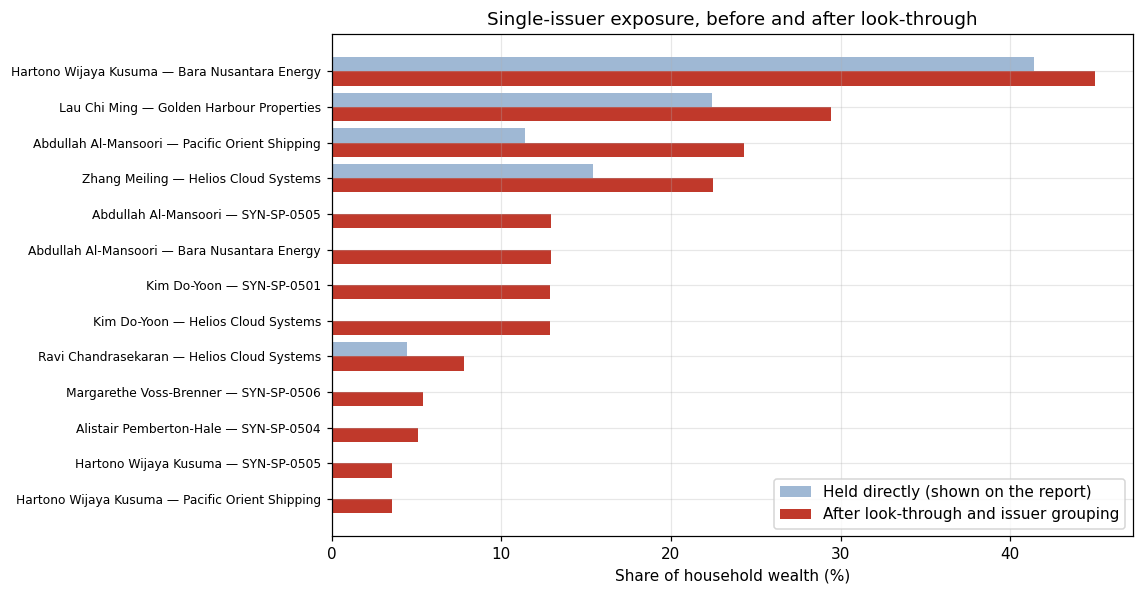

In [28]:
hidden = lookthrough[lookthrough["uplift_pp"] > 0].sort_values("lookthrough_pct")
labels = [f"{r.client_name} — {r.issuer}" for r in hidden.itertuples()]
y = np.arange(len(hidden))

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.barh(
    y + 0.2, hidden["direct_pct"], 0.4, label="Held directly (shown on the report)", color="#9fb8d4"
)
ax.barh(
    y - 0.2,
    hidden["lookthrough_pct"],
    0.4,
    label="After look-through and issuer grouping",
    color="#c0392b",
)
ax.set_yticks(y, labels, fontsize=8)
ax.set_title("Single-issuer exposure, before and after look-through")
ax.set_xlabel("Share of household wealth (%)")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [29]:
position_pct = (
    latest.merge(instruments[["instrument_id", "concentration_limit_applies"]], on="instrument_id")
    .groupby(
        ["client_id", "instrument_id", "instrument_name", "concentration_limit_applies"],
        as_index=False,
    )["market_value_usd"]
    .sum()
)
position_pct["household_pct"] = (
    position_pct["market_value_usd"] / position_pct["client_id"].map(household_totals) * 100
)
position_pct["client_name"] = position_pct["client_id"].map(NAME)
managed_limit_rows = portfolios.loc[portfolios["service_model"].ne("Custody")].merge(
    mandates[["mandate_code", "max_single_position_pct"]].drop_duplicates(), on="mandate_code"
)
limits = managed_limit_rows.groupby("client_id")["max_single_position_pct"].min()
position_pct["household_limit_pct"] = position_pct["client_id"].map(limits)
flagged = position_pct.loc[
    position_pct["concentration_limit_applies"].eq("Y")
    & position_pct["household_pct"].gt(position_pct["household_limit_pct"])
].sort_values("household_pct", ascending=False)

lookthrough["household_limit_pct"] = lookthrough["client_id"].map(limits)
lookthrough["over_limit_pp"] = lookthrough["lookthrough_pct"] - lookthrough["household_limit_pct"]
lookthrough["limit_screen_flag"] = lookthrough["over_limit_pp"].gt(0)
lookthrough["severity"] = np.select(
    [lookthrough["limit_screen_flag"], lookthrough["hidden_exposure_flag"]],
    ["warning", "informational"],
    default="none",
)
concentration_signals = lookthrough.loc[
    lookthrough["limit_screen_flag"] | lookthrough["hidden_exposure_flag"]
].copy()
concentration_signals["incomplete_lookthrough_disclosures"] = [
    incomplete_lookthrough.loc[incomplete_lookthrough["client_id"].eq(client_id)].to_dict("records")
    for client_id in concentration_signals["client_id"]
]
concentration_signals["compliance_finding"] = False
concentration_signals["action"] = (
    "Review household issuer exposure; confirm contractual limits per managed portfolio"
)
concentration_signals.loc[
    concentration_signals["issuer"].eq("Golden Harbour Properties"), "action"
] = (
    "Review combined issuer exposure and obtain remaining accumulator notional; N-018 "
    "links borrowing to settlements"
)
concentration_signals["mandate_evidence_ids"] = [
    [
        f"mandates:{mandate_code}:equity"
        for mandate_code in sorted(
            set(
                managed_limit_rows.loc[
                    managed_limit_rows["client_id"].eq(client_id), "mandate_code"
                ]
            )
        )
    ]
    for client_id in concentration_signals["client_id"]
]
concentration_signals["evidence_ids"] = [
    sorted(set(evidence_ids + mandate_evidence_ids))
    for evidence_ids, mandate_evidence_ids in zip(
        concentration_signals["evidence_ids"],
        concentration_signals["mandate_evidence_ids"],
        strict=True,
    )
]
lau_perpetual = lookthrough.loc[
    lookthrough["client_id"].eq("CL-0014") & lookthrough["issuer"].eq("Pacific Rim Bank")
].iloc[0]
assert np.isclose(lau_perpetual["lookthrough_pct"], 17.6, atol=0.1)
assert lau_perpetual["limit_screen_flag"]
assert managed_limit_rows["service_model"].ne("Custody").all()
print(
    "Household reference limits exclude Custody mandates and do not replace "
    "per-portfolio compliance tests."
)
display(
    flagged[
        [
            "client_id",
            "client_name",
            "instrument_name",
            "market_value_usd",
            "household_pct",
            "household_limit_pct",
        ]
    ].round(2)
)
display(
    concentration_signals[
        [
            "client_id",
            "issuer",
            "direct_pct",
            "lookthrough_pct",
            "household_limit_pct",
            "hidden_exposure_flag",
            "severity",
            "action",
        ]
    ].round(2)
)

Household reference limits exclude Custody mandates and do not replace per-portfolio compliance tests.


,client_id,client_name,instrument_name,market_value_usd,household_pct,household_limit_pct
11,CL-0002,Ravi Chandrasekaran,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.00,68.35,15.0
10,CL-0001,Hartono Wijaya Kusuma,Bara Nusantara Energy Tbk,19287976.54,41.42,15.0
97,CL-0011,Tan Boon Huat,Asia Real Estate Opportunity Fund III,7215976.33,20.42,10.0
153,CL-0016,Yamamoto Kenji,Kanto Pharma Holdings KK,2916729.56,20.10,12.0
127,CL-0014,Lau Chi Ming,Direct Property - Mid-Levels Apartment,5185659.41,19.58,12.0
28,CL-0003,Margarethe Voss-Brenner,Nordvind Industrial AB,4075671.60,18.37,10.0
98,CL-0011,Tan Boon Huat,Direct Property - Sentosa Cove Residence,6471893.49,18.32,10.0
131,CL-0014,Lau Chi Ming,Pacific Rim Bank 4.75% Perpetual,4653000.00,17.57,12.0
87,CL-0009,Andreas Lindqvist,Nordvind Industrial AB,5434228.80,17.19,12.0
126,CL-0013,Zhang Meiling,Helios Cloud Systems Inc,5691400.00,15.40,15.0


,client_id,issuer,direct_pct,lookthrough_pct,household_limit_pct,hidden_exposure_flag,severity,action
0,CL-0001,Bara Nusantara Energy,41.42,44.99,15.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
5,CL-0002,SYN-AL-0308,68.35,68.35,15.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
9,CL-0003,SYN-ST-0107,18.37,18.37,10.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
10,CL-0004,Pacific Rim Bank,11.38,11.38,10.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
19,CL-0009,SYN-ST-0107,17.19,17.19,12.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
22,CL-0011,SYN-AL-0305,20.42,20.42,10.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
23,CL-0011,SYN-AL-0306,18.32,18.32,10.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
28,CL-0013,Helios Cloud Systems,15.40,22.49,15.0,False,warning,Review household issuer exposure; confirm contractual limits per m...
31,CL-0014,Golden Harbour Properties,22.41,29.45,12.0,False,warning,Review combined issuer exposure and obtain remaining accumulator n...
32,CL-0014,Pacific Rim Bank,17.57,17.57,12.0,False,warning,Review household issuer exposure; confirm contractual limits per m...


In [30]:
# The two clearest aggregation cases, shown from source rows.
for client_id in ["CL-0002", "CL-0014"]:
    frame = latest[latest["client_id"] == client_id].copy()
    frame["household_pct"] = frame["market_value_usd"] / frame["market_value_usd"].sum() * 100
    print(f"{client_id} — {NAME[client_id]}   household USD {frame['market_value_usd'].sum():,.0f}")
    display(
        frame[["portfolio_id", "instrument_name", "asset_class", "weight_pct", "household_pct"]]
        .sort_values("household_pct", ascending=False)
        .round(2)
    )

CL-0002 — Ravi Chandrasekaran   household USD 46,699,200


,portfolio_id,instrument_name,asset_class,weight_pct,household_pct
93,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,Alternatives,100.00,68.35
81,PF-0003,US Technology Leaders Fund,Equity,24.04,7.61
82,PF-0003,Meridian Semiconductor Corp,Equity,15.18,4.80
83,PF-0003,Helios Cloud Systems Inc,Equity,14.00,4.43
84,PF-0003,India Equity Fund,Equity,11.46,3.63
87,PF-0003,"Equity Linked Note ref. Helios Cloud Systems, 11.00% p.a., 6M",Structured Products,10.64,3.37
85,PF-0003,Global Developed Equity Index Fund,Equity,9.66,3.06
86,PF-0003,Short Duration USD Bond Fund,Fixed Income,8.26,2.61
88,PF-0003,USD Call Deposit,Cash and Equivalents,6.77,2.14


CL-0014 — Lau Chi Ming   household USD 26,488,971


,portfolio_id,instrument_name,asset_class,weight_pct,household_pct
663,PF-0016,Direct Property - Mid-Levels Apartment,Alternatives,19.58,19.58
658,PF-0016,Pacific Rim Bank 4.75% Perpetual,Fixed Income,17.57,17.57
661,PF-0016,Greater China Equity Fund,Equity,13.84,13.84
662,PF-0016,Asia High Yield Bond Fund,Fixed Income,13.76,13.76
657,PF-0016,Golden Harbour Properties 5.25% Perpetual,Fixed Income,12.87,12.87
659,PF-0016,Golden Harbour Properties Ltd,Equity,9.54,9.54
660,PF-0016,"Accumulator ref. Golden Harbour Properties Ltd, 12M",Structured Products,7.05,7.05
664,PF-0016,HKD Call Deposit,Cash and Equivalents,5.80,5.80


## 7. Liquidity versus cash needs

**Method.** The twelve-month obligation set includes Confirmed and Likely needs in full,
plus uncalled commitments whose expected call windows overlap the horizon. Each
overlapping commitment is included in full as a funding stress, not as a forecast
that all capital will be called. Annual or annual-instalment amounts are included once
in the twelve-month window; the source does not provide an instalment schedule, so
the full stated amount is a conservative planning amount requiring confirmation.

**DQ-11: duplicated obligations.** CN-016 restates COM-001 + COM-002 (USD 15.8m);
CN-008 restates COM-003 (USD 3.0m). The reviewed linkage below checks Client,
currency, amount and window, retains the granular commitments, and preserves both
sets of Evidence. This is an explicit mapping, not fuzzy matching by amount.
CN-002 (USD 4.2m) is shown separately as conditional on a share sale that itself
generates proceeds; it is excluded from baseline funding demand, and no unverified
sale proceeds enter available liquidity. Aspirational CN-019 is excluded.

**Cash is not one tier.** Twelve-month cash cover uses **cash and short-term deposits**.
Daily cash is the intersection of Cash and Equivalents and Daily liquidity; it excludes
Monthly deposits. USD 9.0m of the former cash bucket comprises term deposits across
six Clients. Tan Boon Huat's entire USD 2.37m cash bucket is a term deposit. Daily-liquid
assets include securities and are a gross saleability estimate, not free cash.

**Signals.** Warn when twelve-month cash cover < 1.0x. Escalate when cash cover
< 1.0x **AND** Daily-liquid cover < 1.5x. Independently escalate when confirmed
requirements starting within six months exceed Daily cash; overlapping confirmed
needs are aggregated to avoid reusing the same cash twice. Already-started recurring
requirements are treated as active until their end date, pending confirmation of the
next payment date. A commitment enters this near-term rule only when it replaces a linked Confirmed
planned need (CN-016), counted once. Other contractual call windows remain in the
twelve-month stress, without being labelled confirmed near-term payment dates. Ratios are evaluated before rounding.

After deduplication, Fong has **0.32x cash / 3.27x Daily** cover and Nguyen **0.26x /
1.56x**. Nguyen no longer meets the twelve-month AND escalation rule, but her
confirmed near-term tuition need still triggers escalation. Ravi's baseline improves
to approximately **0.50x cash / 6.60x Daily**, because the conditional tax is excluded;
the review's 0.16x cash still included that contingency.

**Margarethe.** Confirmed CN-004 is EUR 3.4m due 1 October to 31 December 2026.
Daily cash of EUR 1.56m covers 0.46x, so the near-term rule escalates despite 5.27x
gross Daily-liquid cover. An equity sale funding the entire EUR 3.4m tax payment
reduces the Equity share to 65.7%, still about 35.7 percentage points above the cap.
It is tranche one of a glide path, with approximately a further EUR 6.04m reallocation
required to meet the Equity cap. Re-solicit N-005 and obtain the estate's original
tax-lot history before planning disposals.

Nguyen's gated redemption is evidenced by N-009 and TXN-0008. The observation about
three consecutive quarters of gating in N-023 belongs to **Fong**, not Nguyen.
Lau's dated HKD 60m redevelopment contribution must be planned jointly with his
collateral constraints; N-018 records HKD 4m of borrowing to fund accumulator
settlements. Selling pledged assets may require repayment or collateral substitution.

> **Pipeline action.** Publish canonical obligations, source-to-obligation linkage,
> certainty, contingent needs, Daily cash, deposits, gross Daily liquidity and
> near-term deadlines. A liquidity tier is not a promise of settlement or release:
> gated assets cannot fund a dated need; pledge release, notice periods, dealing
> restrictions, FX and taxes require RM validation before calling resources available.
> These holdings do not establish Client solvency or confirm a tax liability.


In [31]:
LOCKED_TIERS = ["Weekly", "Monthly", "Quarterly Gate", "Illiquid"]
as_of = pd.Timestamp(TODAY)
horizon_end = as_of + pd.DateOffset(months=12)
near_term_end = as_of + pd.DateOffset(months=6)
HORIZON_END = horizon_end.strftime("%Y-%m-%d")

cash_now = (
    latest.loc[latest["asset_class"].eq("Cash and Equivalents")]
    .groupby("client_id")["market_value_usd"]
    .sum()
)
daily_cash_now = (
    latest.loc[
        latest["asset_class"].eq("Cash and Equivalents") & latest["liquidity_tier"].eq("Daily")
    ]
    .groupby("client_id")["market_value_usd"]
    .sum()
)
term_deposits_now = (
    latest.loc[
        latest["asset_class"].eq("Cash and Equivalents") & ~latest["liquidity_tier"].eq("Daily")
    ]
    .groupby("client_id")["market_value_usd"]
    .sum()
)
daily_now = (
    latest.loc[latest["liquidity_tier"].eq("Daily")].groupby("client_id")["market_value_usd"].sum()
)
locked_now = (
    latest.loc[latest["liquidity_tier"].isin(LOCKED_TIERS)]
    .groupby("client_id")["market_value_usd"]
    .sum()
)

needs = cash_needs.copy()
needs["amount_usd"] = [
    to_usd(amount, currency)
    for amount, currency in zip(needs["amount"], needs["currency"], strict=True)
]
needs["due_from_date"] = pd.to_datetime(needs["due_from"])
needs["due_to_date"] = pd.to_datetime(needs["due_to"])
assert (
    needs["certainty"]
    .isin(["Confirmed", "Likely", "Conditional on the sale completing", "Aspirational"])
    .all()
)
calls = commitments.copy()
calls["uncalled_usd"] = [
    to_usd(amount, currency)
    for amount, currency in zip(calls["uncalled"], calls["currency"], strict=True)
]


def parse_call_window(window):
    start, end = window.split(" to ")
    return (
        pd.Period(start.replace(" ", ""), freq="Q").start_time.normalize(),
        pd.Period(end.replace(" ", ""), freq="Q").end_time.normalize(),
    )


parsed_windows = calls["expected_call_window"].map(parse_call_window)
calls["call_from"] = [window[0] for window in parsed_windows]
calls["call_to"] = [window[1] for window in parsed_windows]


def overlaps_window(start, end, horizon):
    return start <= horizon and end >= as_of


assert overlaps_window(as_of, horizon_end, horizon_end)
assert not overlaps_window(
    horizon_end + pd.Timedelta(days=1), horizon_end + pd.Timedelta(days=2), horizon_end
)
assert not overlaps_window(as_of - pd.Timedelta(days=2), as_of - pd.Timedelta(days=1), horizon_end)

OBLIGATION_DEDUP_VERSION = "rm-review-2026-09-05-v1"
NEED_COMMITMENT_LINKS = {
    "CN-016": ["COM-001", "COM-002"],
    "CN-008": ["COM-003"],
}
dedup_rows = []
for need_id, commitment_ids in NEED_COMMITMENT_LINKS.items():
    source_need = needs.set_index("need_id").loc[need_id]
    source_calls = calls.set_index("commitment_id").loc[commitment_ids]
    assert source_calls["client_id"].eq(source_need["client_id"]).all()
    assert source_calls["currency"].eq(source_need["currency"]).all()
    assert np.isclose(source_calls["uncalled"].sum(), source_need["amount"], atol=0.01)
    assert source_calls["call_from"].min() == source_need["due_from_date"]
    assert source_calls["call_to"].max() == source_need["due_to_date"]
    dedup_rows.append(
        {
            "finding_id": "DQ-11",
            "need_id": need_id,
            "commitment_ids": commitment_ids,
            "client_id": source_need["client_id"],
            "deduplicated_usd": source_need["amount_usd"],
            "mapping_version": OBLIGATION_DEDUP_VERSION,
            "basis": "RM-reviewed restatement; matching Client, currency, amount and window",
        }
    )
dedup_links = pd.DataFrame(dedup_rows)

eligible_needs = needs.loc[
    needs["certainty"].isin(["Confirmed", "Likely"])
    & needs["due_from_date"].le(horizon_end)
    & needs["due_to_date"].ge(as_of)
    & ~needs["need_id"].isin(NEED_COMMITMENT_LINKS)
].copy()
eligible_calls = calls.loc[calls["call_from"].le(horizon_end) & calls["call_to"].ge(as_of)].copy()
obligation_rows = []
for source_need in eligible_needs.itertuples():
    obligation_rows.append(
        {
            "obligation_id": source_need.need_id,
            "client_id": source_need.client_id,
            "amount_usd": source_need.amount_usd,
            "certainty": source_need.certainty,
            "due_from": source_need.due_from_date,
            "due_to": source_need.due_to_date,
            "source_kind": "planned_cash_need",
            "confirmed_planned_need": source_need.certainty == "Confirmed",
            "evidence_ids": [f"planned_cash_needs:{source_need.need_id}"],
        }
    )
for source_call in eligible_calls.itertuples():
    linked_needs = [
        need_id
        for need_id, ids in NEED_COMMITMENT_LINKS.items()
        if source_call.commitment_id in ids
    ]
    obligation_rows.append(
        {
            "obligation_id": source_call.commitment_id,
            "client_id": source_call.client_id,
            "amount_usd": source_call.uncalled_usd,
            "certainty": "Confirmed",
            "due_from": source_call.call_from,
            "due_to": source_call.call_to,
            "source_kind": "uncalled_commitment",
            "confirmed_planned_need": any(
                needs.set_index("need_id").loc[need_id, "certainty"] == "Confirmed"
                for need_id in linked_needs
            ),
            "evidence_ids": [
                f"commitments:{source_call.commitment_id}",
                *[f"planned_cash_needs:{need_id}" for need_id in linked_needs],
            ],
        }
    )
canonical_obligations = pd.DataFrame(obligation_rows)
assert not canonical_obligations["obligation_id"].duplicated().any()
assert not canonical_obligations["obligation_id"].isin(NEED_COMMITMENT_LINKS).any()
contingent_needs = needs.loc[
    needs["certainty"].eq("Conditional on the sale completing")
    & needs["due_from_date"].le(horizon_end)
    & needs["due_to_date"].ge(as_of)
].copy()
contingent_needs["treatment"] = (
    "Separate sale-dependent contingency; proceeds unknown and excluded from resources"
)
confirmed_near_term = canonical_obligations.loc[
    canonical_obligations["confirmed_planned_need"]
    & canonical_obligations["due_from"].le(near_term_end)
    & canonical_obligations["due_to"].ge(as_of)
].copy()

liquidity = pd.DataFrame(
    {
        "client_name": pd.Series(NAME),
        "total_usd": household_totals,
        "cash_usd": cash_now,
        "daily_cash_usd": daily_cash_now,
        "term_deposits_usd": term_deposits_now,
        "daily_usd": daily_now,
        "locked_usd": locked_now,
        "needs_12m_usd": eligible_needs.groupby("client_id")["amount_usd"].sum(),
        "uncalled_usd": eligible_calls.groupby("client_id")["uncalled_usd"].sum(),
        "confirmed_near_term_usd": confirmed_near_term.groupby("client_id")["amount_usd"].sum(),
        "contingent_usd": contingent_needs.groupby("client_id")["amount_usd"].sum(),
    }
).fillna(0.0)
liquidity["obligations_usd"] = liquidity["needs_12m_usd"] + liquidity["uncalled_usd"]
denominator = liquidity["obligations_usd"].replace(0, np.nan)
liquidity["cash_cover_x"] = liquidity["cash_usd"] / denominator
liquidity["daily_cover_x"] = liquidity["daily_usd"] / denominator
liquidity["daily_cash_near_term_cover_x"] = liquidity["daily_cash_usd"] / liquidity[
    "confirmed_near_term_usd"
].replace(0, np.nan)
liquidity["locked_pct"] = liquidity["locked_usd"] / liquidity["total_usd"] * 100


def funding_severity(cash_cover, daily_cover, near_term_need, daily_cash):
    near_term_shortfall = near_term_need > 0 and daily_cash < near_term_need
    twelve_month_escalation = cash_cover < 1.0 and daily_cover < 1.5
    if near_term_shortfall or twelve_month_escalation:
        return "high"
    return "medium" if cash_cover < 1.0 else "none"


assert funding_severity(1.2, 1.4, 0, 0) == "none"
assert funding_severity(1.0, 1.4, 0, 0) == "none"
assert funding_severity(0.9, 1.5, 0, 0) == "medium"
assert funding_severity(0.9, 1.4999, 0, 0) == "high"
assert funding_severity(1.2, 2.0, 100, 99.99) == "high"
assert funding_severity(1.2, 2.0, 100, 100) == "none"
liquidity["warn_12m"] = liquidity["cash_cover_x"].lt(1.0)
liquidity["escalate_12m"] = liquidity["warn_12m"] & liquidity["daily_cover_x"].lt(1.5)
liquidity["escalate_near_term"] = liquidity["confirmed_near_term_usd"].gt(0) & liquidity[
    "daily_cash_usd"
].lt(liquidity["confirmed_near_term_usd"])
liquidity["severity"] = [
    funding_severity(
        row.cash_cover_x, row.daily_cover_x, row.confirmed_near_term_usd, row.daily_cash_usd
    )
    for row in liquidity.itertuples()
]
liquidity["reason"] = [
    "; ".join(
        reason
        for condition, reason in [
            (row.warn_12m, "12-month cash and short-term deposits below obligations"),
            (row.escalate_12m, "Cash cover <1x AND gross Daily cover <1.5x"),
            (row.escalate_near_term, "Confirmed near-term requirements exceed Daily cash"),
        ]
        if condition
    )
    for row in liquidity.itertuples()
]
liquidity["evidence_ids"] = [
    sorted(
        set(
            [
                evidence
                for ids in canonical_obligations.loc[
                    canonical_obligations["client_id"].eq(client_id), "evidence_ids"
                ]
                for evidence in ids
            ]
            + [
                f"holdings:{TODAY}:{row.portfolio_id}:{row.instrument_id}"
                for row in latest.loc[latest["client_id"].eq(client_id)].itertuples()
            ]
        )
    )
    for client_id in liquidity.index
]
liquidity["resource_caveat"] = (
    "Gross assets before encumbrance, disposal costs, tax, settlement and FX confirmation"
)
funding_signals = liquidity.loc[liquidity["severity"].ne("none")].copy()
funding_signals.index.name = "client_id"
funding_signals["signal_type"] = "funding_gap"
assert np.allclose(
    liquidity["cash_usd"], liquidity["daily_cash_usd"] + liquidity["term_deposits_usd"]
)
assert len(term_deposits_now) == 6
assert np.isclose(liquidity.loc["CL-0017", "obligations_usd"], 16_700_000)
assert np.isclose(liquidity.loc["CL-0006", "obligations_usd"], 8_000_000)
assert np.isclose(liquidity.loc["CL-0002", "obligations_usd"], 2_000_000)
assert np.isclose(liquidity.loc["CL-0017", "cash_cover_x"], 0.32, atol=0.005)
assert np.isclose(liquidity.loc["CL-0006", "daily_cover_x"], 1.56, atol=0.005)
assert not liquidity.loc["CL-0006", "escalate_12m"]
assert liquidity.loc["CL-0003", "escalate_near_term"]
assert not liquidity.loc["CL-0020", "escalate_near_term"]
assert set(
    confirmed_near_term.loc[
        confirmed_near_term["source_kind"].eq("uncalled_commitment"), "obligation_id"
    ]
) == {"COM-001", "COM-002"}
assert liquidity.loc["CL-0011", "daily_cash_usd"] == 0
assert np.isclose(canonical_obligations["amount_usd"].sum(), liquidity["obligations_usd"].sum())

print("Explicit DQ-11 obligation linkage:")
display(dedup_links)
print("Contingent requirements, excluded from baseline:")
display(contingent_needs[["need_id", "client_id", "amount_usd", "certainty", "treatment"]])
print(
    f"Cash and short-term deposits include USD {term_deposits_now.sum() / 1e6:.2f}m "
    "non-Daily deposits."
)
money = [
    "total_usd",
    "cash_usd",
    "daily_cash_usd",
    "term_deposits_usd",
    "daily_usd",
    "needs_12m_usd",
    "uncalled_usd",
    "obligations_usd",
    "confirmed_near_term_usd",
]
liquidity_view = liquidity.sort_values("cash_cover_x")[
    [
        "client_name",
        *money,
        "cash_cover_x",
        "daily_cover_x",
        "daily_cash_near_term_cover_x",
        "locked_pct",
        "severity",
        "reason",
    ]
].copy()
liquidity_view[money] = liquidity_view[money] / 1e6
liquidity_view = liquidity_view.rename(
    columns={column: column.replace("_usd", "_usd_m") for column in money}
)
display(liquidity_view.round(2))

Explicit DQ-11 obligation linkage:


,finding_id,need_id,commitment_ids,client_id,deduplicated_usd,mapping_version,basis
0,DQ-11,CN-016,"[COM-001, COM-002]",CL-0017,15800000.0,rm-review-2026-09-05-v1,"RM-reviewed restatement; matching Client, currency, amount and window"
1,DQ-11,CN-008,[COM-003],CL-0006,3000000.0,rm-review-2026-09-05-v1,"RM-reviewed restatement; matching Client, currency, amount and window"


Contingent requirements, excluded from baseline:


,need_id,client_id,amount_usd,certainty,treatment
1,CN-002,CL-0002,4200000.0,Conditional on the sale completing,Separate sale-dependent contingency; proceeds unknown and excluded...


Cash and short-term deposits include USD 9.02m non-Daily deposits.


,client_name,total_usd_m,cash_usd_m,daily_cash_usd_m,term_deposits_usd_m,daily_usd_m,needs_12m_usd_m,uncalled_usd_m,obligations_usd_m,confirmed_near_term_usd_m,cash_cover_x,daily_cover_x,daily_cash_near_term_cover_x,locked_pct,severity,reason
CL-0007,Alistair Pemberton-Hale,40.02,1.60,1.60,0.00,35.18,12.00,0.0,12.00,0.00,0.13,2.93,NaN,12.08,medium,12-month cash and short-term deposits below obligations
CL-0020,Grace Adeyemi-Lim,19.06,0.85,0.85,0.00,17.85,3.60,0.9,4.50,0.00,0.19,3.97,NaN,6.33,medium,12-month cash and short-term deposits below obligations
CL-0014,Lau Chi Ming,26.49,1.54,1.54,0.00,11.38,7.68,0.0,7.68,7.68,0.20,1.48,0.20,57.05,high,12-month cash and short-term deposits below obligations; Cash cove...
CL-0006,Nguyen Thi Bao Tran,18.07,2.07,0.00,2.07,12.51,5.00,3.0,8.00,5.00,0.26,1.56,0.00,30.79,high,12-month cash and short-term deposits below obligations; Confirmed...
CL-0001,Hartono Wijaya Kusuma,46.57,1.73,0.40,1.33,41.64,6.66,0.0,6.66,0.00,0.26,6.26,NaN,10.58,medium,12-month cash and short-term deposits below obligations
CL-0017,Fong Enterprises Family Office,87.90,5.39,5.39,0.00,54.62,0.90,15.8,16.70,16.70,0.32,3.27,0.32,37.86,high,12-month cash and short-term deposits below obligations; Confirmed...
CL-0003,Margarethe Voss-Brenner,22.18,1.70,1.70,0.00,19.58,3.71,0.0,3.71,3.71,0.46,5.27,0.46,11.71,high,12-month cash and short-term deposits below obligations; Confirmed...
CL-0019,Abdullah Al-Mansoori,32.21,2.40,2.40,0.00,26.12,5.00,0.0,5.00,0.00,0.48,5.22,NaN,18.90,medium,12-month cash and short-term deposits below obligations
CL-0002,Ravi Chandrasekaran,46.70,1.00,1.00,0.00,13.21,2.00,0.0,2.00,0.00,0.50,6.60,NaN,71.72,medium,12-month cash and short-term deposits below obligations
CL-0011,Tan Boon Huat,35.34,2.37,0.00,2.37,16.26,2.07,0.0,2.07,0.00,1.14,7.85,NaN,53.98,none,


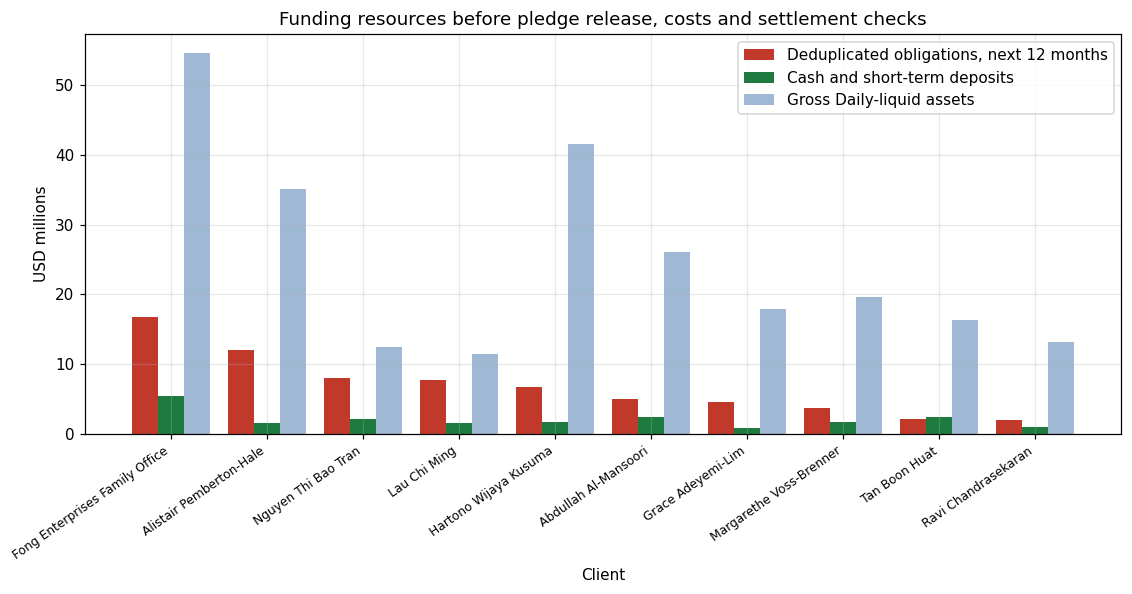

In [32]:
at_risk = (
    liquidity.loc[liquidity["obligations_usd"] > 0]
    .sort_values("obligations_usd", ascending=False)
    .head(10)
)
labels = list(at_risk["client_name"])
positions = np.arange(len(at_risk))

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.bar(
    positions - 0.27,
    at_risk["obligations_usd"] / 1e6,
    0.27,
    label="Deduplicated obligations, next 12 months",
    color="#c0392b",
)
ax.bar(
    positions,
    at_risk["cash_usd"] / 1e6,
    0.27,
    label="Cash and short-term deposits",
    color="#1f7a3f",
)
ax.bar(
    positions + 0.27,
    at_risk["daily_usd"] / 1e6,
    0.27,
    label="Gross Daily-liquid assets",
    color="#9fb8d4",
)
ax.set_xticks(positions, labels, rotation=35, ha="right", fontsize=8)
ax.set_title("Funding resources before pledge release, costs and settlement checks")
ax.set_xlabel("Client")
ax.set_ylabel("USD millions")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
need = cash_needs.loc[cash_needs["need_id"].eq("CN-004")]
display(need)

mv_tiers = mv.groupby("liquidity_tier")["market_value_base"].sum()
mv_cash = mv.loc[mv["asset_class"].eq("Cash and Equivalents"), "market_value_base"].sum()
mv_daily_cash = mv.loc[
    mv["asset_class"].eq("Cash and Equivalents") & mv["liquidity_tier"].eq("Daily"),
    "market_value_base",
].sum()
amount = float(need["amount"].iloc[0])
post_tax_total_eur = total_eur - amount
post_tax_equity_eur = equity_eur - amount
post_tax_equity_pct = post_tax_equity_eur / post_tax_total_eur * 100
further_equity_reallocation_eur = max(
    post_tax_equity_eur - post_tax_total_eur * cons_equity_max / 100, 0
)
fixed_income_eur = mv.loc[mv["asset_class"].eq("Fixed Income"), "market_value_base"].sum()
post_reallocation_fixed_income_pct = (
    (fixed_income_eur + further_equity_reallocation_eur) / post_tax_total_eur * 100
)
assert np.isclose(post_tax_equity_pct, 65.7, atol=0.1)
assert np.isclose(further_equity_reallocation_eur / 1e6, 6.04, atol=0.01)

print(
    f"Need: EUR {amount:,.0f}, due {need['due_from'].iloc[0]} to "
    f"{need['due_to'].iloc[0]} (Confirmed)"
)
print(f"Cash and short-term deposits: EUR {mv_cash:,.0f}, cover {mv_cash / amount:.2f}x")
print(f"Daily cash: EUR {mv_daily_cash:,.0f}, cover {mv_daily_cash / amount:.2f}x")
print(
    f"Gross Daily-liquid assets: EUR {mv_tiers.get('Daily', 0):,.0f}, cover "
    f"{mv_tiers.get('Daily', 0) / amount:.2f}x"
)
print(f"Funding Signal: {liquidity.loc['CL-0003', 'severity']}, confirmed need within six months.")
print(
    f"If EUR {amount:,.0f} of Equity is sold and paid out for tax, Equity remains "
    f"{post_tax_equity_pct:.2f}%."
)
print(
    f"Further Equity reallocation to reach the {cons_equity_max:.0f}% cap: EUR "
    f"{further_equity_reallocation_eur:,.0f}."
)
print(
    f"If reallocated to Fixed Income, its share becomes {post_reallocation_fixed_income_pct:.2f}%."
)
print(
    "This illustration assumes unchanged prices, no disposal costs or additional "
    "taxes, and no other flows."
)
print("The tax sale is tranche one of a glide path; check all Mandate bands after each tranche.")
print(
    "Re-solicit the N-005 no-change instruction; obtain original tax-lot history from "
    "the transferring institution or estate executor."
)
print(
    "PF-0005 available cost bases start at transfer, not purchase, and are not a "
    "basis for tax advice."
)

,need_id,client_id,description,currency,amount,due_from,due_to,recurrence,certainty
3,CN-004,CL-0003,German inheritance tax instalment,EUR,3400000,2026-10-01,2026-12-31,One-off,Confirmed


Need: EUR 3,400,000, due 2026-10-01 to 2026-12-31 (Confirmed)
Cash and short-term deposits: EUR 1,561,192, cover 0.46x
Daily cash: EUR 1,561,192, cover 0.46x
Gross Daily-liquid assets: EUR 17,934,556, cover 5.27x
Funding Signal: high, confirmed need within six months.
If EUR 3,400,000 of Equity is sold and paid out for tax, Equity remains 65.72%.
Further Equity reallocation to reach the 30% cap: EUR 6,041,646.
If reallocated to Fixed Income, its share becomes 46.71%.
This illustration assumes unchanged prices, no disposal costs or additional taxes, and no other flows.
The tax sale is tranche one of a glide path; check all Mandate bands after each tranche.
Re-solicit the N-005 no-change instruction; obtain original tax-lot history from the transferring institution or estate executor.
PF-0005 available cost bases start at transfer, not purchase, and are not a basis for tax advice.


In [34]:
# The gated private credit fund, and who is sitting behind it.
gated = latest[latest["liquidity_tier"] == "Quarterly Gate"].assign(
    client_name=lambda d: d["client_id"].map(NAME)
)
display(
    gated[
        ["client_id", "client_name", "portfolio_id", "instrument_name", "market_value_usd"]
    ].round(0)
)

print("Redemption requests that were gated:")
display(
    transactions.loc[
        transactions["transaction_type"] == "Redemption Request",
        ["transaction_id", "trade_date", "client_id", "instrument_name", "narrative"],
    ]
)

,client_id,client_name,portfolio_id,instrument_name,market_value_usd
191,CL-0004,Chalermchai Suphanburi,PF-0006,Global Infrastructure Debt Fund,1803600.0
283,CL-0006,Nguyen Thi Bao Tran,PF-0008,Orchard Private Credit Fund II,1408400.0
472,CL-0010,Priya Nair Menon,PF-0012,Global Infrastructure Debt Fund,601200.0
517,CL-0011,Tan Boon Huat,PF-0013,Orchard Private Credit Fund II,3018000.0
576,CL-0012,Cheung Kwok Wing,PF-0014,Global Infrastructure Debt Fund,1202400.0
828,CL-0017,Fong Enterprises Family Office,PF-0020,Orchard Private Credit Fund II,9557000.0
831,CL-0017,Fong Enterprises Family Office,PF-0020,Global Infrastructure Debt Fund,2505000.0


Redemption requests that were gated:


,transaction_id,trade_date,client_id,instrument_name,narrative
197,TXN-0008,2026-05-12,CL-0006,Orchard Private Credit Fund II,Full redemption requested to fund USD capital calls. Manager appli...
201,TXN-0009,2026-06-24,CL-0011,Orchard Private Credit Fund II,Partial redemption of USD 1.5m requested. Manager applied the quar...


## 8. Credit and loan-to-value

**What we check.** Recompute lending value from every pledged position's market value and advance rate, convert it into the facility currency, then calculate drawn / lending value at each snapshot. The margin-call trigger belongs to the individual facility.

**What we found.** CF-0005 breached at 78.50% and 75.68% before curing to 58.86% in March and ending at 59.15%, against 70%. Its USD 8m drawn balance never fell. The positive collateral recovery is concentrated in coal exposure on the unresolved Strait event channel. It now emits a **fragile-cure** Signal: historic breach, cure without debt reduction, and over half the positive collateral recovery attributable to that unresolved channel. The 50% concentration criterion is an explicit demo policy requiring approval, not a contractual rule. Reopening could reverse that recovery; a numerical reopening stress still requires calibrated shocks and is not asserted here.

CF-0001 breached in June at 75.64% and ends at 73.71%, against 75%. Technology recovered after the June drawdown, but the facility has only 1.29 percentage points of headroom; its USD 1.7m June drawdown also increased leverage (TXN-0012, N-004).

CF-0002 ends at 69.41%, only 0.59 percentage points below 70%. It **has risen at three consecutive observations since February**, after falling from 53.93% to 53.53% between December and February. Its balances grew HKD 6m over the snapshots. TXN-0013 and RM note N-018 identify HKD 4m drawn for accumulator settlements; the other HKD 2m is not explained by those rows. Borrowing therefore partly funds the accumulator losses, but the transaction ledger is not a complete facility reconciliation.

> **Pipeline action.** Publish reconstructed lending value, headroom, the count of consecutive LTV increases, current/historical breach dates and the fragile-cure sub-flag. Fragile cure must cite the collateral positions, facility rows, relevant event evidence IDs and map version. Retain it even when current headroom has recovered.

In [35]:
ltv = facilities.set_index("facility_id")[[f"ltv_pct_{date}" for date in SNAPSHOTS]]
ltv.columns = SNAPSHOTS
credit = facilities[
    [
        "facility_id",
        "client_id",
        "collateral_portfolio_id",
        "facility_type",
        "facility_ccy",
        "credit_limit",
        "margin_call_ltv_pct",
        "utilisation_pct_current",
    ]
].copy()
credit["client_name"] = credit["client_id"].map(NAME)
credit = credit.set_index("facility_id").join(ltv)
credit["headroom_pp_now"] = credit["margin_call_ltv_pct"] - credit[LAST]
credit["ltv_trend_pp"] = credit[LAST] - credit[FIRST]
credit["ever_breached"] = ltv.gt(credit["margin_call_ltv_pct"], axis=0).any(axis=1)
credit["currently_breached"] = credit[LAST].gt(credit["margin_call_ltv_pct"])
credit["consecutive_ltv_increases"] = 0
for facility_id, values in ltv.iterrows():
    increase_count = 0
    for change in values.diff().iloc[1:].iloc[::-1]:
        if change <= 0:
            break
        increase_count += 1
    credit.loc[facility_id, "consecutive_ltv_increases"] = increase_count

collateral_components = []
for facility in facilities.itertuples():
    for snapshot_date in SNAPSHOTS:
        pledged = holdings.loc[
            holdings["portfolio_id"].eq(facility.collateral_portfolio_id)
            & holdings["snapshot_date"].eq(snapshot_date)
        ]
        for position in pledged.itertuples():
            lending_value_facility = (
                position.market_value_base
                * position.advance_rate_pct
                / 100
                * to_usd(1, position.portfolio_ccy, snapshot_date)
                / to_usd(1, facility.facility_ccy, snapshot_date)
            )
            collateral_components.append(
                {
                    "facility_id": facility.facility_id,
                    "snapshot_date": snapshot_date,
                    "instrument_id": position.instrument_id,
                    "lending_value_facility": lending_value_facility,
                    "evidence_id": (
                        f"holdings:{snapshot_date}:{position.portfolio_id}:{position.instrument_id}"
                    ),
                }
            )
collateral_components = pd.DataFrame(collateral_components)
recomputed_lending = collateral_components.pivot_table(
    index="facility_id", columns="snapshot_date", values="lending_value_facility", aggfunc="sum"
).reindex(columns=SNAPSHOTS)
reported_lending = facilities.set_index("facility_id")[
    [f"lending_value_{date}" for date in SNAPSHOTS]
]
reported_lending.columns = SNAPSHOTS
drawn_history = facilities.set_index("facility_id")[[f"drawn_{date}" for date in SNAPSHOTS]]
drawn_history.columns = SNAPSHOTS
assert np.allclose(recomputed_lending, reported_lending, atol=1, rtol=0)
assert np.allclose(drawn_history / recomputed_lending * 100, ltv, atol=0.011, rtol=0)

unresolved = REFERENCE_MAPS["unresolved_event_context"]
unresolved_instruments = set().union(
    *(channel_instrument_ids(channel) for channel in unresolved["channels"])
)
unresolved_events = events_asof.loc[
    events_asof["event_date"].isin(unresolved["supporting_event_dates"])
]
assert not unresolved_events.empty
credit["fragile_cure"] = False
credit["unresolved_recovery_share_pct"] = 0.0
credit["cure_without_drawn_reduction"] = False
credit["fragile_cure_evidence_ids"] = pd.Series({facility_id: [] for facility_id in credit.index})
credit["mapping_version"] = MAP_VERSION
for facility_id in credit.index:
    prior_breaches = ltv.columns[
        ltv.loc[facility_id].gt(credit.loc[facility_id, "margin_call_ltv_pct"])
    ].tolist()
    if not prior_breaches or credit.loc[facility_id, "currently_breached"]:
        continue
    last_breach = prior_breaches[-1]
    draw_since_breach = drawn_history.loc[facility_id, last_breach:]
    no_repayment = draw_since_breach.diff().dropna().ge(-0.01).all()
    components = collateral_components.loc[collateral_components["facility_id"].eq(facility_id)]
    recovery = components.pivot(
        index="instrument_id", columns="snapshot_date", values="lending_value_facility"
    ).fillna(0)
    positive_recovery = (recovery[LAST] - recovery[last_breach]).clip(lower=0)
    total_recovery = positive_recovery.sum()
    event_recovery = positive_recovery.loc[
        positive_recovery.index.isin(unresolved_instruments)
    ].sum()
    recovery_pct = 100 * event_recovery / total_recovery if total_recovery > 0 else 0.0
    credit.loc[facility_id, "unresolved_recovery_share_pct"] = recovery_pct
    credit.loc[facility_id, "cure_without_drawn_reduction"] = bool(no_repayment)
    credit.loc[facility_id, "fragile_cure"] = bool(
        no_repayment
        and total_recovery > 0
        and recovery_pct >= REFERENCE_MAPS["threshold_policy"]["fragile_cure_recovery_share_pct"]
    )
    if credit.loc[facility_id, "fragile_cure"]:
        credit.at[facility_id, "fragile_cure_evidence_ids"] = (
            [f"credit_facilities:{facility_id}"]
            + unresolved_events["evidence_id"].tolist()
            + components.loc[
                components["snapshot_date"].isin([last_breach, LAST]), "evidence_id"
            ].tolist()
        )
credit["severity"] = np.select(
    [
        credit["currently_breached"],
        credit["headroom_pp_now"].le(5)
        | credit["consecutive_ltv_increases"].ge(3)
        | credit["fragile_cure"],
    ],
    ["high", "warning"],
    default="none",
)
credit["evidence_ids"] = [
    [f"credit_facilities:{facility_id}"]
    + collateral_components.loc[
        collateral_components["facility_id"].eq(facility_id), "evidence_id"
    ].tolist()
    + sorted(
        set().union(
            *(
                set(currency_conversion_evidence(currency, snapshot_date))
                for snapshot_date in SNAPSHOTS
                for currency in [
                    credit.loc[facility_id, "facility_ccy"],
                    BASE_CCY[credit.loc[facility_id, "client_id"]],
                ]
            )
        )
    )
    + credit.at[facility_id, "fragile_cure_evidence_ids"]
    for facility_id in credit.index
]
collateral_signals = credit.loc[credit["severity"].ne("none")].copy()
assert credit.loc["CF-0005", "fragile_cure"]
assert drawn_history.loc["CF-0005"].nunique() == 1
assert credit.loc["CF-0002", "consecutive_ltv_increases"] == 3
assert ltv.loc["CF-0002", SNAPSHOTS[1]] < ltv.loc["CF-0002", FIRST]
display(
    credit[
        [
            "client_name",
            "margin_call_ltv_pct",
            *SNAPSHOTS,
            "headroom_pp_now",
            "consecutive_ltv_increases",
            "ever_breached",
            "fragile_cure",
            "unresolved_recovery_share_pct",
            "severity",
        ]
    ].round(2)
)

,client_name,margin_call_ltv_pct,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26,headroom_pp_now,consecutive_ltv_increases,ever_breached,fragile_cure,unresolved_recovery_share_pct,severity
facility_id,,,,,,,,,,,,,
CF-0001,Ravi Chandrasekaran,75.0,63.32,59.72,61.68,75.64,73.71,1.29,0,True,False,0.00,warning
CF-0002,Lau Chi Ming,70.0,53.93,53.53,65.62,67.96,69.41,0.59,3,False,False,0.00,warning
CF-0003,Zhang Meiling,75.0,23.24,21.95,22.73,20.93,20.39,54.61,0,False,False,0.00,none
CF-0004,Tan Boon Huat,80.0,31.58,31.18,32.06,32.16,32.29,47.71,3,False,False,0.00,warning
CF-0005,Hartono Wijaya Kusuma,70.0,78.50,75.68,58.86,62.18,59.15,10.85,0,True,True,99.49,warning


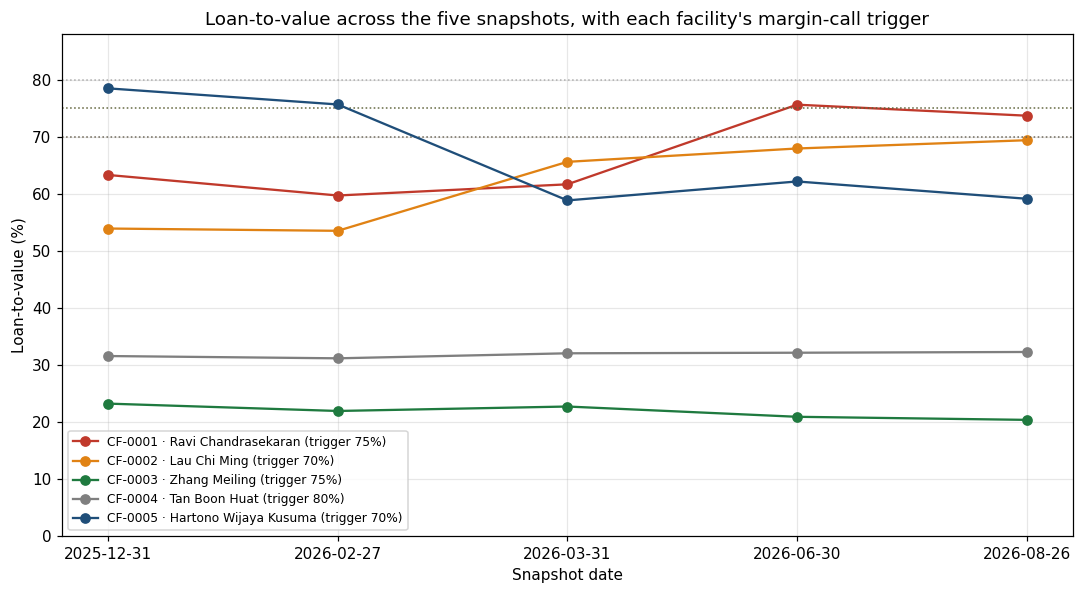

In [36]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#c0392b", "#e08214", "#1f7a3f", "#7f7f7f", "#1f4e79"]
for (facility_id, row), color in zip(ltv.iterrows(), colors, strict=True):
    trigger = credit.loc[facility_id, "margin_call_ltv_pct"]
    label = f"{facility_id} · {credit.loc[facility_id, 'client_name']} (trigger {trigger:.0f}%)"
    ax.plot(SNAPSHOTS, row.to_numpy(), marker="o", color=color, label=label)
    ax.axhline(trigger, color=color, linestyle=":", linewidth=1, alpha=0.6)

ax.set_title("Loan-to-value across the five snapshots, with each facility's margin-call trigger")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Loan-to-value (%)")
ax.set_ylim(0, 88)  # leave clear space below the flat facilities for the legend
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

In [37]:
breach_events = []
for facility_id, values in ltv.iterrows():
    trigger = credit.loc[facility_id, "margin_call_ltv_pct"]
    for snapshot_date, value in values.items():
        if value > trigger:
            breach_events.append(
                {
                    "facility_id": facility_id,
                    "client_name": credit.loc[facility_id, "client_name"],
                    "snapshot_date": snapshot_date,
                    "ltv_pct": value,
                    "trigger_pct": trigger,
                    "over_by_pp": value - trigger,
                    "evidence_ids": [f"credit_facilities:{facility_id}"],
                }
            )
display(pd.DataFrame(breach_events))
display(
    credit.loc[
        credit["fragile_cure"],
        [
            "client_name",
            "cure_without_drawn_reduction",
            "unresolved_recovery_share_pct",
            "mapping_version",
            "fragile_cure_evidence_ids",
        ],
    ]
)
period_draws = transactions.loc[
    transactions["transaction_type"].eq("Facility Drawdown")
    & pd.to_datetime(transactions["trade_date"]).between(pd.Timestamp(FIRST), pd.Timestamp(TODAY))
]
display(
    period_draws[["transaction_id", "trade_date", "client_id", "currency", "amount", "narrative"]]
)
lau_drawn_change = drawn_history.loc["CF-0002", LAST] - drawn_history.loc["CF-0002", FIRST]
lau_accumulator_draw = period_draws.loc[
    period_draws["transaction_id"].eq("TXN-0013"), "amount"
].sum()
print(
    f"Lau drawn balance change: HKD {lau_drawn_change:,.0f}; identified accumulator "
    f"settlement draw: HKD {lau_accumulator_draw:,.0f} (TXN-0013, N-018)."
)
print(
    "Unexplained remainder in this drawdown evidence: HKD "
    f"{lau_drawn_change - lau_accumulator_draw:,.0f}."
)

,facility_id,client_name,snapshot_date,ltv_pct,trigger_pct,over_by_pp,evidence_ids
0,CF-0001,Ravi Chandrasekaran,2026-06-30,75.64,75.0,0.64,[credit_facilities:CF-0001]
1,CF-0005,Hartono Wijaya Kusuma,2025-12-31,78.50,70.0,8.50,[credit_facilities:CF-0005]
2,CF-0005,Hartono Wijaya Kusuma,2026-02-27,75.68,70.0,5.68,[credit_facilities:CF-0005]


,client_name,cure_without_drawn_reduction,unresolved_recovery_share_pct,mapping_version,fragile_cure_evidence_ids
facility_id,,,,,
CF-0005,Hartono Wijaya Kusuma,True,99.488154,phase-a-rm-review-v1,"[credit_facilities:CF-0005, event_log:2026-03-04:03f0065c255bb857,..."


,transaction_id,trade_date,client_id,currency,amount,narrative
5,TXN-0013,2026-03-05,CL-0014,HKD,4000000.0,Additional drawdown to meet accumulator settlement obligations.
200,TXN-0012,2026-06-08,CL-0002,USD,1700000.0,Additional Lombard drawdown to fund a pre-IPO secondary purchase. ...


Lau drawn balance change: HKD 6,000,000; identified accumulator settlement draw: HKD 4,000,000 (TXN-0013, N-018).
Unexplained remainder in this drawdown evidence: HKD 2,000,000.


## 9. Currency, event exposure and suitability drift

**What we check.** Currency exposure is the market value denominated outside a client's base currency, **assumed unhedged** because hedge data are absent. Fund currency is an imperfect proxy for underlying currency exposure. Above 40% is informational; it escalates only when combined with a confirmed base-currency need active within 24 months, or an evidenced base-currency income/decumulation objective. These are demo policy thresholds, not bank-approved limits.

The versioned map covers **every exact `primary_transmission` value** in the supplied event log, including duration, technology/collateral, private credit and gold. Every result carries the event's stable evidence ID, map version, scenario direction and mapping limitations. Events after the as-of date are excluded. Exposure above 15% warns; it escalates when a curated, source-supported source-of-wealth overlap exists. These are exposure screens tied to documented events, not claims that an event caused every price move. The map was curated from supplied sources and the written RM review; external RM signoff is still pending.

**What we found.** Seven clients exceed 40% non-base currency, but they no longer all become high-priority alerts. Yamamoto's 56.4% non-JPY share has an explicit JPY retirement-income objective and a confirmed JPY need (CN-014). N-021 records awareness of this mismatch and dealing restrictions, not a contradiction.

The Strait screen remains 45.0% for Hartono, 42.1% for Al-Mansoori and 20.4% for Kim. Hartono and Al-Mansoori are vulnerable to **reopening and risk-premium reversal**; duration-sensitive bond holders are vulnerable to **escalation and higher yields**. Broad Commodity Index is assigned at its full market value although its energy fraction is unavailable. Each note is counted once in a channel union; channel totals overlap and must not be summed.

Al-Mansoori's same-store return is approximately +9.7%, excluding externally added positions. His Strait holdings present from the start gained approximately USD 1.89m; the remaining holdings contributed roughly 2.27 percentage points to household growth. The review's USD 2.3m Strait-gain estimate does not reproduce from the source snapshots. N-026's reopening question remains unanswered by a calibrated stress model.

**Suitability drift.** Trigger exactly when risk tolerance is at most 3 and **either base-currency same-store period price return is below -5%, or maximum drawdown across the five snapshots is below -7%**. CL-0004 and CL-0012 trigger. Income and fees from transactions are displayed alongside, labelled not reconciled to positions; they are not added mechanically to a total return. Five snapshots cannot establish realised volatility or continuous maximum drawdown.

In [38]:
currency_mix = latest.groupby(["client_id", "instrument_ccy"], as_index=False)[
    "market_value_usd"
].sum()
currency_mix["pct"] = (
    currency_mix["market_value_usd"] / currency_mix["client_id"].map(household_totals) * 100
)
currency_mix["base_ccy"] = currency_mix["client_id"].map(BASE_CCY)
in_base = (
    currency_mix.loc[currency_mix["instrument_ccy"].eq(currency_mix["base_ccy"])]
    .groupby("client_id")["pct"]
    .sum()
)
fx_risk = pd.DataFrame(
    {
        "client_name": pd.Series(NAME),
        "base_ccy": pd.Series(BASE_CCY),
        "pct_in_base_ccy": in_base,
    }
)
fx_risk["pct_in_base_ccy"] = fx_risk["pct_in_base_ccy"].fillna(0.0)
fx_risk["pct_not_in_base_ccy"] = 100 - fx_risk["pct_in_base_ccy"]
currency_horizon = pd.Timestamp(TODAY) + pd.DateOffset(months=24)
confirmed_base_needs = cash_needs.loc[
    cash_needs["certainty"].eq("Confirmed")
    & cash_needs["currency"].eq(cash_needs["client_id"].map(BASE_CCY))
    & pd.to_datetime(cash_needs["due_from"]).le(currency_horizon)
    & pd.to_datetime(cash_needs["due_to"]).ge(pd.Timestamp(TODAY))
]
objective_map = REFERENCE_MAPS["currency_objective_overrides"]
fx_risk["confirmed_base_need_24m"] = fx_risk.index.isin(confirmed_base_needs["client_id"])
fx_risk["base_income_objective"] = [
    client_id in objective_map
    and objective_map[client_id]["currency"] == BASE_CCY[client_id]
    and not objective_map[client_id].get("currency_inferred", False)
    for client_id in fx_risk.index
]
fx_risk["severity"] = np.select(
    [
        fx_risk["pct_not_in_base_ccy"].gt(40)
        & (fx_risk["confirmed_base_need_24m"] | fx_risk["base_income_objective"]),
        fx_risk["pct_not_in_base_ccy"].gt(40),
    ],
    ["high", "informational"],
    default="none",
)
fx_risk["disclosure"] = "Assumed unhedged; denomination is not full fund currency look-through"
fx_risk["mapping_version"] = MAP_VERSION
fx_risk["evidence_ids"] = [
    [f"clients:{client_id}"]
    + [
        f"planned_cash_needs:{need_id}"
        for need_id in confirmed_base_needs.loc[
            confirmed_base_needs["client_id"].eq(client_id), "need_id"
        ]
    ]
    + objective_map.get(client_id, {}).get("evidence_ids", [])
    + holding_evidence(latest.loc[latest["client_id"].eq(client_id)])
    for client_id in fx_risk.index
]
fx_risk.index.name = "client_id"
fx_risk = fx_risk.sort_values("pct_not_in_base_ccy", ascending=False)
currency_signals = fx_risk.loc[fx_risk["severity"].ne("none")].copy()
assert len(currency_signals) == 7
assert fx_risk.loc["CL-0016", "severity"] == "high"
assert (
    currency_signals.loc[currency_signals["severity"].eq("high"), "confirmed_base_need_24m"]
    | currency_signals.loc[currency_signals["severity"].eq("high"), "base_income_objective"]
).all()
assert currency_signals["severity"].eq("informational").any()
display(FX.loc[[FIRST, LAST]].round(3))
display(
    fx_risk[
        [
            "client_name",
            "base_ccy",
            "pct_not_in_base_ccy",
            "confirmed_base_need_24m",
            "base_income_objective",
            "severity",
            "disclosure",
        ]
    ].round(1)
)

series_id,EURUSD,GBPUSD,USDCHF,USDCNH,USDHKD,USDIDR,USDINR,USDJPY,USDSGD,USDTHB
snapshot_date,,,,,,,,,,
2025-12-31,1.160,1.345,0.790,7.08,7.79,16250.0,88.2,152.0,1.290,33.1
2026-08-26,1.092,1.282,0.831,7.23,7.81,17050.0,90.8,159.0,1.352,34.8


,client_name,base_ccy,pct_not_in_base_ccy,confirmed_base_need_24m,base_income_objective,severity,disclosure
client_id,,,,,,,
CL-0001,Hartono Wijaya Kusuma,SGD,97.1,False,False,informational,Assumed unhedged; denomination is not full fund currency look-through
CL-0010,Priya Nair Menon,SGD,72.1,False,False,informational,Assumed unhedged; denomination is not full fund currency look-through
CL-0005,Aishah binti Rahman,SGD,61.3,True,False,high,Assumed unhedged; denomination is not full fund currency look-through
CL-0016,Yamamoto Kenji,JPY,56.4,True,True,high,Assumed unhedged; denomination is not full fund currency look-through
CL-0018,Elena Marchetti-Wong,EUR,46.8,False,False,informational,Assumed unhedged; denomination is not full fund currency look-through
CL-0014,Lau Chi Ming,HKD,44.2,True,False,high,Assumed unhedged; denomination is not full fund currency look-through
CL-0008,Chen Wei Ling,SGD,43.8,True,False,high,Assumed unhedged; denomination is not full fund currency look-through
CL-0009,Andreas Lindqvist,EUR,29.1,False,False,none,Assumed unhedged; denomination is not full fund currency look-through
CL-0006,Nguyen Thi Bao Tran,SGD,26.8,False,False,none,Assumed unhedged; denomination is not full fund currency look-through


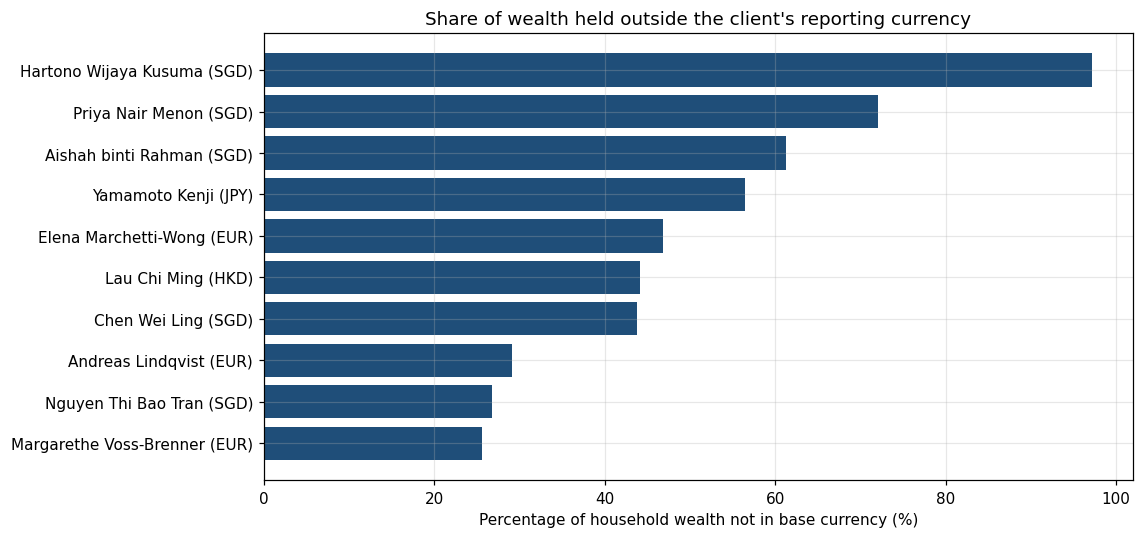

In [39]:
top_fx = fx_risk.head(10).iloc[::-1]
labels = [f"{n} ({c})" for n, c in zip(top_fx["client_name"], top_fx["base_ccy"], strict=True)]

fig, ax = plt.subplots(figsize=(10.5, 5))
ax.barh(labels, top_fx["pct_not_in_base_ccy"], color="#1f4e79")
ax.set_title("Share of wealth held outside the client's reporting currency")
ax.set_xlabel("Percentage of household wealth not in base currency (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [40]:
STRAIT_INSTRUMENTS = sorted(
    set().union(
        *(
            channel_instrument_ids(channel)
            for channel in REFERENCE_MAPS["strait_screen"]["channels"]
        )
    )
)
event_exposure_rows = []
for event in events_asof.to_dict("records"):
    event_mapping = REFERENCE_MAPS["transmission_map"][event["primary_transmission"]]
    for channel in event_mapping["channels"]:
        channel_definition = REFERENCE_MAPS["channels"][channel]
        channel_ids = channel_instrument_ids(channel)
        exposed_holdings = latest.loc[latest["instrument_id"].isin(channel_ids)]
        for client_id, positions in exposed_holdings.groupby("client_id"):
            channel_usd = positions["market_value_usd"].sum()
            channel_pct = channel_usd / household_totals[client_id] * 100
            wealth_mapping = REFERENCE_MAPS["wealth_channel_overrides"].get(client_id, {})
            wealth_correlation = channel in wealth_mapping.get("channels", [])
            threshold_exceeded = (
                channel_pct > REFERENCE_MAPS["threshold_policy"]["event_exposure_pct"]
            )
            held_notes = sorted(set(positions["instrument_id"]).intersection(LOOKTHROUGH))
            pledged_portfolios = facilities.loc[
                facilities["client_id"].eq(client_id), "collateral_portfolio_id"
            ]
            event_exposure_rows.append(
                {
                    "client_id": client_id,
                    "client_name": NAME[client_id],
                    "event_date": event["event_date"],
                    "event_evidence_id": event["evidence_id"],
                    "primary_transmission": event["primary_transmission"],
                    "channel": channel,
                    "channel_exposure_usd": channel_usd,
                    "channel_exposure_pct": channel_pct,
                    "scenario": channel_definition["scenario"],
                    "direction": channel_definition["direction"],
                    "pledged_exposure": bool(
                        positions["portfolio_id"].isin(pledged_portfolios).any()
                    ),
                    "wealth_correlation": wealth_correlation,
                    "wealth_overlap_basis": wealth_mapping.get("basis")
                    if wealth_correlation
                    else None,
                    "wealth_overlap_evidence_ids": wealth_mapping.get("evidence_ids", [])
                    if wealth_correlation
                    else [],
                    "incomplete_lookthrough_disclosures": incomplete_lookthrough.loc[
                        incomplete_lookthrough["client_id"].eq(client_id)
                    ].to_dict("records"),
                    "mapping_version": MAP_VERSION,
                    "mapping_review_status": REFERENCE_MAPS["review_status"],
                    "disclosures": [channel_definition["disclosure"]]
                    + event_mapping["unmapped_components"]
                    + [
                        REFERENCE_MAPS["lookthrough"][note_id]["disclosure"]
                        for note_id in held_notes
                    ],
                    "evidence_ids": [event["evidence_id"], f"clients:{client_id}"]
                    + holding_evidence(latest.loc[latest["client_id"].eq(client_id)])
                    + [
                        f"instruments:{instrument_id}"
                        for instrument_id in sorted(
                            set(positions["instrument_id"])
                            | set().union(*(set(LOOKTHROUGH[note_id]) for note_id in held_notes))
                        )
                    ]
                    + (wealth_mapping.get("evidence_ids", []) if wealth_correlation else []),
                    "severity": "high"
                    if threshold_exceeded and wealth_correlation
                    else "warning"
                    if threshold_exceeded
                    else "none",
                }
            )
event_exposures = pd.DataFrame(event_exposure_rows)
event_signals = event_exposures.loc[event_exposures["severity"].ne("none")].copy()
assert set(events_asof["primary_transmission"]) <= set(REFERENCE_MAPS["transmission_map"])
assert event_exposures["channel_exposure_pct"].le(100 + 1e-8).all()
assert event_signals["direction"].str.len().gt(0).all()
assert set(event_signals["event_evidence_id"]) <= set(events_asof["evidence_id"])
assert event_signals["mapping_version"].eq(MAP_VERSION).all()
assert event_signals["channel_exposure_pct"].gt(15).all()
assert event_signals.loc[event_signals["severity"].eq("high"), "wealth_correlation"].all()
assert {"CL-0001", "CL-0019"} <= set(
    event_signals.loc[event_signals["severity"].eq("high"), "client_id"]
)
print(
    "Event exposure Signals cover every source transmission via a versioned map; a "
    "channel may have no threshold breach."
)
display(
    event_signals[
        [
            "client_id",
            "event_date",
            "event_evidence_id",
            "channel",
            "channel_exposure_pct",
            "direction",
            "wealth_correlation",
            "severity",
            "mapping_version",
        ]
    ].round(2)
)
print(REFERENCE_MAPS["review_status"])
print(
    "Unknown basket components remain unscreenable:",
    sorted(set(incomplete_lookthrough["instrument_id"])),
)

strait = (
    latest.loc[latest["instrument_id"].isin(STRAIT_INSTRUMENTS)]
    .groupby("client_id")["market_value_usd"]
    .sum()
)
exposure = pd.DataFrame(
    {
        "client_name": pd.Series(NAME),
        "source_of_wealth": clients.set_index("client_id")["source_of_wealth"],
        "strait_exposure_usd": strait,
        "household_usd": household_totals,
    }
).dropna(subset=["strait_exposure_usd"])
exposure["strait_pct"] = exposure["strait_exposure_usd"] / exposure["household_usd"] * 100
exposure["strait_exposure_usd_m"] = exposure["strait_exposure_usd"] / 1e6
exposure["household_usd_m"] = exposure["household_usd"] / 1e6
exposure["mapping_version"] = MAP_VERSION
exposure["direction"] = "Reopening / energy and freight premium reversal can reduce these holdings"
exposure["disclosure"] = REFERENCE_MAPS["strait_screen"]["disclosure"]
display(exposure.sort_values("strait_pct", ascending=False).round(2))
assert np.isclose(exposure.loc["CL-0001", "strait_pct"], 45.0, atol=0.1)
assert np.isclose(exposure.loc["CL-0019", "strait_pct"], 42.1, atol=0.1)

snapshot_running_peaks = same_store_base_values[SNAPSHOTS].cummax(axis=1)
snapshot_drawdowns = (same_store_base_values[SNAPSHOTS] / snapshot_running_peaks - 1) * 100
suitability = clients.set_index("client_id")[
    ["client_name", "base_currency", "risk_tolerance_score"]
].copy()
suitability["return_base_ccy_pct"] = performance["return_base_ccy_pct"]
suitability["snapshot_max_drawdown_pct"] = snapshot_drawdowns.min(axis=1)
suitability = suitability.join(
    income_summary[["income_usd", "income_base", "fees_usd", "fees_base"]]
)
suitability["suitability_drift"] = suitability["risk_tolerance_score"].le(3) & (
    suitability["return_base_ccy_pct"].lt(-5) | suitability["snapshot_max_drawdown_pct"].lt(-7)
)
suitability["severity"] = np.where(suitability["suitability_drift"], "warning", "none")
suitability["disclosure"] = (
    "Same-store price return; drawdown observed at five snapshots only. Income/fees "
    "not reconciled to positions; not a total return."
)
suitability["evidence_ids"] = [
    [f"clients:{client_id}"]
    + holding_evidence(
        holdings.loc[
            holdings["client_id"].eq(client_id) & holdings["snapshot_date"].isin(SNAPSHOTS)
        ]
    )
    + [
        f"transactions:{transaction_id}"
        for transaction_id in transactions.loc[
            transactions["client_id"].eq(client_id)
            & transactions["transaction_type"].isin(
                ["Dividend", "Coupon", "Interest", "Distribution", "Management Fee"]
            )
            & pd.to_datetime(transactions["trade_date"]).between(
                pd.Timestamp(FIRST), pd.Timestamp(TODAY)
            ),
            "transaction_id",
        ]
    ]
    + sorted(
        set().union(
            *(
                set(currency_conversion_evidence(currency))
                for currency in [
                    BASE_CCY[client_id],
                    *transactions.loc[
                        transactions["client_id"].eq(client_id)
                        & transactions["transaction_type"].isin(
                            ["Dividend", "Coupon", "Interest", "Distribution", "Management Fee"]
                        )
                        & pd.to_datetime(transactions["trade_date"]).between(
                            pd.Timestamp(FIRST), pd.Timestamp(TODAY)
                        ),
                        "currency",
                    ].unique(),
                ]
            )
        )
    )
    for client_id in suitability.index
]
suitability_signals = suitability.loc[suitability["suitability_drift"]].copy()
assert set(suitability_signals.index) == {"CL-0004", "CL-0012"}
assert suitability_signals["snapshot_max_drawdown_pct"].lt(-7).all()
assert suitability_signals["income_usd"].gt(0).all()
display(
    suitability_signals[
        [
            "client_name",
            "base_currency",
            "risk_tolerance_score",
            "return_base_ccy_pct",
            "snapshot_max_drawdown_pct",
            "income_base",
            "fees_base",
            "disclosure",
        ]
    ].round(2)
)

Event exposure Signals cover every source transmission via a versioned map; a channel may have no threshold breach.


,client_id,event_date,event_evidence_id,channel,channel_exposure_pct,direction,wealth_correlation,severity,mapping_version
1,CL-0007,2025-12-31,event_log:2025-12-31:51fd8a798bc16b0c,gold,24.04,Loss on gold-price reversal; escalation may support safe-haven dem...,False,warning,phase-a-rm-review-v1
7,CL-0010,2025-12-31,event_log:2025-12-31:51fd8a798bc16b0c,inflation_linked,15.16,"Inflation protection may benefit, but rising real yields can reduc...",False,warning,phase-a-rm-review-v1
9,CL-0007,2026-01-26,event_log:2026-01-26:86ef81f17c5e02f5,gold,24.04,Loss on gold-price reversal; escalation may support safe-haven dem...,False,warning,phase-a-rm-review-v1
15,CL-0007,2026-01-28,event_log:2026-01-28:0f5eb613de53606d,gold,24.04,Loss on gold-price reversal; escalation may support safe-haven dem...,False,warning,phase-a-rm-review-v1
20,CL-0001,2026-02-28,event_log:2026-02-28:4c2747ccef491eb5,energy,44.99,Loss on Strait reopening / energy risk-premium reversal; possible ...,True,high,phase-a-rm-review-v1
...,...,...,...,...,...,...,...,...,...
176,CL-0015,2026-07-29,event_log:2026-07-29:84745b7a2a697078,technology,42.57,Loss on technology repricing / higher discount rates; pledged posi...,False,warning,phase-a-rm-review-v1
179,CL-0001,2026-08-05,event_log:2026-08-05:24e7bc19d36567e0,energy,44.99,Loss on Strait reopening / energy risk-premium reversal; possible ...,True,high,phase-a-rm-review-v1
181,CL-0015,2026-08-05,event_log:2026-08-05:24e7bc19d36567e0,energy,20.38,Loss on Strait reopening / energy risk-premium reversal; possible ...,False,warning,phase-a-rm-review-v1
182,CL-0019,2026-08-05,event_log:2026-08-05:24e7bc19d36567e0,energy,21.84,Loss on Strait reopening / energy risk-premium reversal; possible ...,True,high,phase-a-rm-review-v1


Draft curated implementation of the written RM review. External RM signoff of individual mappings is still required before client use.
Unknown basket components remain unscreenable: ['SYN-SP-0501', 'SYN-SP-0506']


,client_name,source_of_wealth,strait_exposure_usd,household_usd,strait_pct,strait_exposure_usd_m,household_usd_m,mapping_version,direction,disclosure
CL-0001,Hartono Wijaya Kusuma,Inherited - family coal mining and energy group,20950460.53,46571821.48,44.99,20.95,46.57,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...
CL-0019,Abdullah Al-Mansoori,"Entrepreneur - Gulf logistics, port services and marine chartering",13573266.33,32214266.33,42.13,13.57,32.21,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...
CL-0015,Kim Do-Yoon,Entrepreneur - media production and artist management,3054600.00,14985635.85,20.38,3.05,14.99,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...
CL-0005,Aishah binti Rahman,Entrepreneur - palm oil plantations and commercial property,2159100.00,19400737.88,11.13,2.16,19.40,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...
CL-0007,Alistair Pemberton-Hale,Executive compensation - retired physical commodities trader,2616800.00,40019276.00,6.54,2.62,40.02,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...
CL-0012,Cheung Kwok Wing,Executive compensation - retired shipping group executive,1633802.82,28028704.72,5.83,1.63,28.03,phase-a-rm-review-v1,Reopening / energy and freight premium reversal can reduce these h...,Broad Commodity Index full-weight approximation; each held product...


,client_name,base_currency,risk_tolerance_score,return_base_ccy_pct,snapshot_max_drawdown_pct,income_base,fees_base,disclosure
client_id,,,,,,,,
CL-0004,Chalermchai Suphanburi,USD,3,-6.61,-7.64,1546936.63,144887.85,Same-store price return; drawdown observed at five snapshots only....
CL-0012,Cheung Kwok Wing,USD,3,-6.98,-8.20,1145819.55,121818.61,Same-store price return; drawdown observed at five snapshots only....


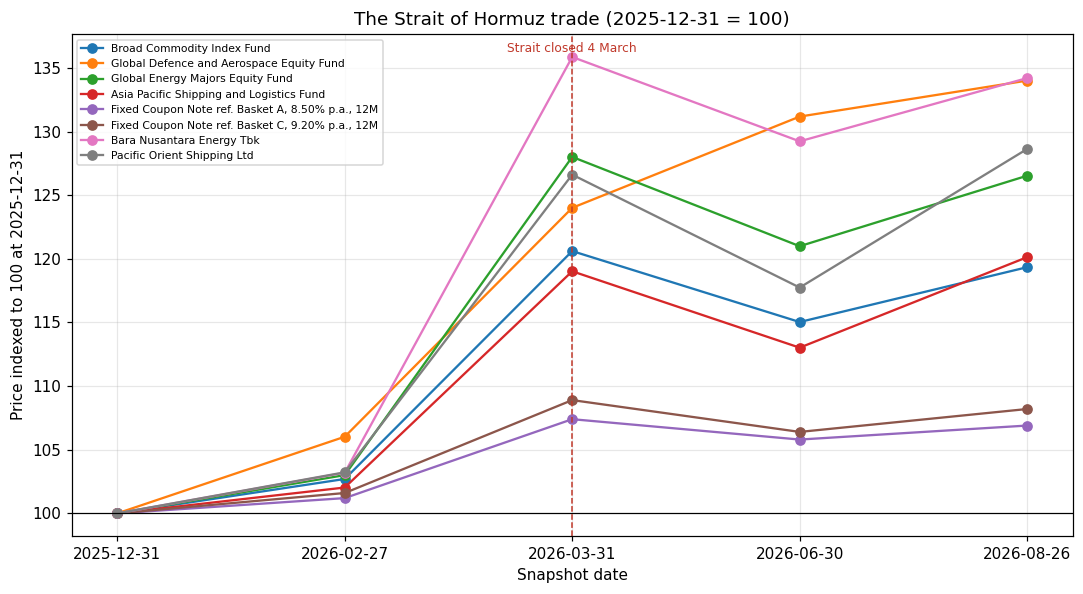

,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
instrument_name,,,,,
Broad Commodity Index Fund,100.0,102.7,120.6,115.0,119.3
Global Defence and Aerospace Equity Fund,100.0,106.0,124.0,131.2,134.0
Global Energy Majors Equity Fund,100.0,103.0,128.0,121.0,126.5
Asia Pacific Shipping and Logistics Fund,100.0,102.0,119.0,113.0,120.1
"Fixed Coupon Note ref. Basket A, 8.50% p.a., 12M",100.0,101.2,107.4,105.8,106.9
"Fixed Coupon Note ref. Basket C, 9.20% p.a., 12M",100.0,101.6,108.9,106.4,108.2
Bara Nusantara Energy Tbk,100.0,103.2,135.9,129.2,134.2
Pacific Orient Shipping Ltd,100.0,103.2,126.6,117.7,128.6


In [41]:
# How the Strait trade actually performed, snapshot by snapshot.
strait_prices = instruments.set_index("instrument_id").loc[
    STRAIT_INSTRUMENTS, [f"price_{d}" for d in SNAPSHOTS]
]
strait_prices.columns = SNAPSHOTS
strait_indexed = strait_prices.div(strait_prices[FIRST], axis=0) * 100
strait_indexed.index = instruments.set_index("instrument_id").loc[
    STRAIT_INSTRUMENTS, "instrument_name"
]

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, row in strait_indexed.iterrows():
    ax.plot(SNAPSHOTS, row.to_numpy(), marker="o", label=label)
ax.axhline(100, color="black", linewidth=0.8)
ax.axvline("2026-03-31", color="#c0392b", linestyle="--", linewidth=1)
ax.annotate(
    "Strait closed 4 March",
    xy=("2026-03-31", 1.0),
    xycoords=("data", "axes fraction"),
    xytext=(0, -12),
    textcoords="offset points",
    fontsize=8,
    color="#c0392b",
    ha="center",
)
ax.set_title("The Strait of Hormuz trade (2025-12-31 = 100)")
ax.set_xlabel("Snapshot date")
ax.set_ylabel("Price indexed to 100 at 2025-12-31")
ax.legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

display(strait_indexed.round(1))

## 10. RM notes versus computed Facts

**What we check.** Human-curated pairings of note paraphrases and deterministic observations.
Every presentation labels the note ID and date, explicitly says this is an RM paraphrase rather
than verbatim client speech, and requires RM review before client use.

**What we found.** The original nine pairings contain **six tensions/contradictions, two
constraints/corroborations (N-010 and N-021), and one unanswered question (N-028)**. They are not
nine contradicted client beliefs. Adding Elena's N-024 gold comparison creates one additional
tension; Lindqvist's N-013 is shown separately as an unexecuted plan requiring follow-up.

Hartono's legacy coal stock is in custody, where he already said it could not be reduced.
The relevant new tension is the April N-002 request for the FCN in his managed portfolio,
about 6.2% of that portfolio, versus N-001's diversification objective. Household energy/shipping
exposure remains about 45%, but the custody holding itself is not a newly discovered contradiction.

Cheung and Chalermchai's price falls must appear beside income received. Elena's roughly 14.04%
gold holding is above the 10% mandate maximum, versus an originally intended 5% hedge; N-024 also
records that her business and largest equity holding depend on Greater China luxury demand.

> **Pipeline action.** Persist the pairing type, dated note references, supporting Fact IDs,
> and a `requires_rm_review` flag. Waivers stay visible for monitoring and confirmation; dealing
> restrictions block inappropriate trade suggestions. An unanswered question generates a follow-up,
> not an inferred client instruction or a recommendation to sell.

In [42]:
notes.sort_values(["client_id", "note_date"]).assign(
    client_name=lambda d: d["client_id"].map(NAME)
)[["note_id", "client_id", "client_name", "note_date", "channel", "note"]]

,note_id,client_id,client_name,note_date,channel,note
0,N-001,CL-0001,Hartono Wijaya Kusuma,2026-01-08,Meeting,Annual review in Singapore. Client is more engaged than in prior y...
1,N-002,CL-0001,Hartono Wijaya Kusuma,2026-04-14,Call,Client called about the energy rally. Very positive on the outlook...
2,N-003,CL-0002,Ravi Chandrasekaran,2026-02-03,Meeting,"Secondary sale process is progressing, bankers indicate Q4 2026 at..."
3,N-004,CL-0002,Ravi Chandrasekaran,2026-06-11,Call,Difficult call. Client was agitated about the drop in his technolo...
4,N-005,CL-0003,Margarethe Voss-Brenner,2026-02-16,Meeting,First meeting following the transfer in. Mrs Voss-Brenner is still...
5,N-006,CL-0003,Margarethe Voss-Brenner,2026-05-29,Email,Client asked whether she should be worried about the news from the...
6,N-007,CL-0004,Chalermchai Suphanburi,2026-03-24,Meeting,Client is firm on retiring in Q2 2027 and handing the business to ...
27,N-028,CL-0004,Chalermchai Suphanburi,2026-08-19,Email,Client forwarded an article about interest rates and asked whether...
7,N-008,CL-0005,Aishah binti Rahman,2026-02-11,Meeting,Reviewed the sustainability policy the family adopted in 2024. Cli...
8,N-009,CL-0006,Nguyen Thi Bao Tran,2026-05-12,Call,Client needs USD liquidity for capital calls and the first US tuit...


In [43]:
def pct_asset(client_id, asset_class):
    frame = latest[latest["client_id"] == client_id]
    return (
        frame.loc[frame["asset_class"] == asset_class, "market_value_usd"].sum()
        / frame["market_value_usd"].sum()
        * 100
    )


def pct_instruments(client_id, instrument_ids):
    frame = latest[latest["client_id"] == client_id]
    return (
        frame.loc[frame["instrument_id"].isin(instrument_ids), "market_value_usd"].sum()
        / frame["market_value_usd"].sum()
        * 100
    )


note_lookup = notes.set_index("note_id")
fi_change = {}
for client_id in ["CL-0012", "CL-0004"]:
    fixed_income = holdings[
        (holdings["client_id"] == client_id) & (holdings["asset_class"] == "Fixed Income")
    ]
    values_by_date = fixed_income.groupby("snapshot_date")["market_value_base"].sum()
    fi_change[client_id] = values_by_date[LAST] - values_by_date[FIRST]
hartono_managed = latest.merge(portfolios[["portfolio_id", "service_model"]], on="portfolio_id")
hartono_managed = hartono_managed[
    (hartono_managed["client_id"] == "CL-0001") & (hartono_managed["service_model"] != "Custody")
]
hartono_note_pct = (
    hartono_managed.loc[
        hartono_managed["instrument_id"] == "SYN-SP-0505", "market_value_base"
    ].sum()
    / hartono_managed["market_value_base"].sum()
    * 100
)
helios_lookthrough = lookthrough.loc[
    (lookthrough["client_id"] == "CL-0013") & (lookthrough["issuer"] == "Helios Cloud Systems"),
    "lookthrough_pct",
].item()
gold_pct_elena = pct_asset("CL-0018", "Commodities")


def paired_note(client_id, note_ids, pairing_type, paraphrase, observation, original=True):
    assert all(note_lookup.loc[note_id, "client_id"] == client_id for note_id in note_ids)
    return {
        "client_id": client_id,
        "client_name": NAME[client_id],
        "pairing_type": pairing_type,
        "as_recorded": "; ".join(
            f"as recorded in RM note {note_id} of {note_lookup.loc[note_id, 'note_date']}"
            for note_id in note_ids
        ),
        "rm_paraphrase_not_verbatim": paraphrase,
        "data_says": observation,
        "note_evidence_ids": [f"rm_notes:{note_id}" for note_id in note_ids],
        "requires_rm_review": True,
        "original_pair": original,
    }


said_vs_data = pd.DataFrame(
    [
        paired_note(
            "CL-0003",
            ["N-005", "N-006"],
            "tension",
            "Prefers safety; previously instructed no changes",
            (
                f"Equity {pct_asset('CL-0003', 'Equity'):.2f}% vs 30% cap; re-solicit "
                "instructions before action."
            ),
        ),
        paired_note(
            "CL-0001",
            ["N-001", "N-002"],
            "tension",
            (
                "Diversify the managed relationship away from the mine, but requested "
                "more energy exposure in April"
            ),
            (
                f"Requested FCN is {hartono_note_pct:.2f}% of managed assets; household "
                f"energy/shipping {pct_instruments('CL-0001', STRAIT_INSTRUMENTS):.2f}%. "
                "Legacy coal is custody, already acknowledged."
            ),
        ),
        paired_note(
            "CL-0005",
            ["N-008"],
            "tension",
            "Believes the sustainable portfolio is aligned",
            (
                f"Excluded instruments {susbal_breach['weight_pct'].sum():.2f}%; "
                "documentation failure requires escalation."
            ),
        ),
        paired_note(
            "CL-0019",
            ["N-025"],
            "tension",
            "Asia portfolio was intended to diversify the Gulf business",
            (
                "Energy/shipping exposure "
                f"{pct_instruments('CL-0019', STRAIT_INSTRUMENTS):.2f}%; reopening would "
                "challenge both."
            ),
        ),
        paired_note(
            "CL-0012",
            ["N-016"],
            "tension",
            "Regards bonds as the safe part and is reluctant to sell at a loss",
            (
                f"Fixed-income marks USD {fi_change['CL-0012']:,.0f}; income received USD "
                f"{income_summary.loc['CL-0012', 'income_usd']:,.0f}, not reconciled to "
                "positions. Maturity extends to 2045."
            ),
        ),
        paired_note(
            "CL-0013",
            ["N-017"],
            "tension",
            "Dismissive of single-name exposure after counting the note",
            (
                f"Helios {helios_lookthrough:.2f}% of household after look-through vs 15% "
                "screening limit."
            ),
        ),
        paired_note(
            "CL-0007",
            ["N-010"],
            "constraint/corroboration",
            "Requested extra gold; signed waiver recorded",
            (
                f"Commodities {pct_asset('CL-0007', 'Commodities'):.2f}% vs 10%; monitor "
                "and confirm waiver remains current."
            ),
        ),
        paired_note(
            "CL-0016",
            ["N-021"],
            "constraint/corroboration",
            "Aware of yen mismatch; board dealing window opens in November",
            (
                f"{fx_risk.loc['CL-0016', 'pct_not_in_base_ccy']:.2f}% outside JPY. "
                "Respect the dealing restriction."
            ),
        ),
        paired_note(
            "CL-0004",
            ["N-028"],
            "unanswered question",
            "Asked whether to move everything to deposits; reply outstanding",
            (
                f"Fixed-income marks USD {fi_change['CL-0004']:,.0f}; income USD "
                f"{income_summary.loc['CL-0004', 'income_usd']:,.0f}, not reconciled to "
                "positions; future annual need USD 1.45m."
            ),
        ),
        paired_note(
            "CL-0018",
            ["N-024"],
            "tension",
            "Gold was originally sized as a 5% hedge",
            (
                f"Gold {gold_pct_elena:.2f}% vs 10% mandate max. N-024 records the same "
                "Greater-China-luxury theme in her business and largest equity holding."
            ),
            False,
        ),
        paired_note(
            "CL-0009",
            ["N-013"],
            "unexecuted plan",
            "Previously agreed deployment plans remain unexecuted",
            (
                "Cash and short-term deposits "
                f"{pct_asset('CL-0009', 'Cash and Equivalents'):.2f}%; confirm objectives "
                "and documented instructions."
            ),
            False,
        ),
    ]
)
assert said_vs_data.loc[said_vs_data["original_pair"], "pairing_type"].value_counts().to_dict() == {
    "tension": 6,
    "constraint/corroboration": 2,
    "unanswered question": 1,
}
print("RM paraphrases, not verbatim client speech. RM review required before client use.")
display(said_vs_data.drop(columns="original_pair"))

RM paraphrases, not verbatim client speech. RM review required before client use.


,client_id,client_name,pairing_type,as_recorded,rm_paraphrase_not_verbatim,data_says,note_evidence_ids,requires_rm_review
0,CL-0003,Margarethe Voss-Brenner,tension,as recorded in RM note N-005 of 2026-02-16; as recorded in RM note...,Prefers safety; previously instructed no changes,Equity 71.46% vs 30% cap; re-solicit instructions before action.,"[rm_notes:N-005, rm_notes:N-006]",True
1,CL-0001,Hartono Wijaya Kusuma,tension,as recorded in RM note N-001 of 2026-01-08; as recorded in RM note...,"Diversify the managed relationship away from the mine, but request...",Requested FCN is 6.18% of managed assets; household energy/shippin...,"[rm_notes:N-001, rm_notes:N-002]",True
2,CL-0005,Aishah binti Rahman,tension,as recorded in RM note N-008 of 2026-02-11,Believes the sustainable portfolio is aligned,Excluded instruments 21.30%; documentation failure requires escala...,[rm_notes:N-008],True
3,CL-0019,Abdullah Al-Mansoori,tension,as recorded in RM note N-025 of 2026-04-15,Asia portfolio was intended to diversify the Gulf business,Energy/shipping exposure 42.13%; reopening would challenge both.,[rm_notes:N-025],True
4,CL-0012,Cheung Kwok Wing,tension,as recorded in RM note N-016 of 2026-07-16,Regards bonds as the safe part and is reluctant to sell at a loss,"Fixed-income marks USD -2,482,300; income received USD 1,145,820, ...",[rm_notes:N-016],True
5,CL-0013,Zhang Meiling,tension,as recorded in RM note N-017 of 2026-06-12,Dismissive of single-name exposure after counting the note,Helios 22.49% of household after look-through vs 15% screening limit.,[rm_notes:N-017],True
6,CL-0007,Alistair Pemberton-Hale,constraint/corroboration,as recorded in RM note N-010 of 2026-01-22,Requested extra gold; signed waiver recorded,Commodities 18.93% vs 10%; monitor and confirm waiver remains curr...,[rm_notes:N-010],True
7,CL-0016,Yamamoto Kenji,constraint/corroboration,as recorded in RM note N-021 of 2026-05-07,Aware of yen mismatch; board dealing window opens in November,56.41% outside JPY. Respect the dealing restriction.,[rm_notes:N-021],True
8,CL-0004,Chalermchai Suphanburi,unanswered question,as recorded in RM note N-028 of 2026-08-19,Asked whether to move everything to deposits; reply outstanding,"Fixed-income marks USD -2,204,500; income USD 1,546,937, not recon...",[rm_notes:N-028],True
9,CL-0018,Elena Marchetti-Wong,tension,as recorded in RM note N-024 of 2026-04-22,Gold was originally sized as a 5% hedge,Gold 14.04% vs 10% mandate max. N-024 records the same Greater-Chi...,[rm_notes:N-024],True


## 11. Data imperfections and operational remediation

**What we check.** Source inconsistencies and valuation uncertainty, with explicit consequences.
The catalogue now contains **11 findings**, including overlapping commitments/needs (DQ-11).
Counts and severities are calculated below rather than assumed from an earlier draft.

Holdings and transactions are not a reconciled accounting ledger (DQ-01). Income and fees still
matter and are separately computed, labelled not reconciled to positions. DQ-02 distinguishes
new-position purchase cost from the added positions' subsequent price movement.

**PF-0005 (DQ-03/04):** the transfer date is 2026-02-16, not the original purchase date. The
December snapshot is backfilled; the February 27 snapshot is after transfer. The eight populated
bases are treated as transfer-booking bases under the RM review, so their book P&L means
**since transfer, never since purchase**, and is not a validated tax basis. Nordvind has no basis.
The source does not provide the decedent's tax-lot history, so no disposal-tax conclusion can be
drawn for any of the nine positions. The carryover principle for relevant gratuitous acquisitions
is supported by [German EStG §20(4)](https://www.gesetze-im-internet.de/estg/__20.html);
the applicability and original lots require tax-specialist verification.

**Action:** request tax-lot history from the transferring institution or estate executor before
the October-December tax conversation. Blocking tax output must not block the supported mandate
or cash-need Facts. Inheritance-tax funding and tax arising on an asset sale are separate questions.

**DQ-05 is high:** Aranya's 11-month-old valuation represents 68.4% of Ravi's household. That is
materially different from ordinary quarterly-reporting lag. Display valuation age, treat reported
value as uncertain realizable collateral/liquidity, and do not call the unchanged mark a current price.

DQ-11 records CN-016 and CN-008 as restatements of fund commitments. Retain both source records
and their evidence links; remove the duplicated liability contribution, not the raw rows.

In [44]:
imperfections = pd.DataFrame(
    [
        {
            "id": "DQ-01",
            "severity": "high",
            "where": "holdings / transactions",
            "what": (
                "Trades, income, fees and withdrawals do not roll forward into reported holdings."
            ),
            "pipeline_should": (
                "Holdings determine positions; separately compute income/fees, labelled "
                "not reconciled to positions."
            ),
        },
        {
            "id": "DQ-02",
            "severity": "high",
            "where": "TXN-0001 through TXN-0007 / holdings",
            "what": (
                "Added quantities have purchase cost and post-purchase moves, not pure performance."
            ),
            "pipeline_should": (
                "Reconcile starting price + FX + current-FX purchase cost + post-purchase "
                "move; same-store excludes additions and their own moves."
            ),
        },
        {
            "id": "DQ-03",
            "severity": "high",
            "where": "PF-0005 / TXN-0018",
            "what": (
                "Transfer-date acquisition metadata and backfilled December positions; "
                "eight populated bases are treated as transfer-booking bases."
            ),
            "pipeline_should": (
                "Book P&L since transfer, not purchase; tax basis unreliable for all nine "
                "positions. Request decedent tax-lot history from institution/estate "
                "executor before Oct-Dec."
            ),
        },
        {
            "id": "DQ-04",
            "severity": "medium",
            "where": "PF-0005 / SYN-ST-0107",
            "what": "Nordvind has no cost basis or unrealised P&L.",
            "pipeline_should": (
                "Display not available, never impute. Together with DQ-03 blocks all "
                "PF-0005 disposal-tax calculations."
            ),
        },
        {
            "id": "DQ-05",
            "severity": "high",
            "where": "SYN-AL-0308 / CL-0002",
            "what": "Aranya valuation dated 2025-09-30, 11 months old and 68.4% of household.",
            "pipeline_should": (
                "Disclose age and material concentration. Exclude stale prices from "
                "current price attribution; reported-mark comparisons carry valuation "
                "uncertainty."
            ),
        },
        {
            "id": "DQ-06",
            "severity": "low",
            "where": "SYN-SP-0506",
            "what": "Missing sector and unnamed three Asian banking-major underlyings.",
            "pipeline_should": (
                "Sector fallback is not issuer resolution. Emit unscreenable-underlying "
                "disclosure, never clean zero."
            ),
        },
        {
            "id": "DQ-07",
            "severity": "low",
            "where": "CL-0017",
            "what": "Age is null for a family-office entity.",
            "pipeline_should": "Use entity context; no inferred age or retirement rule.",
        },
        {
            "id": "DQ-08",
            "severity": "medium",
            "where": "private-market valuations",
            "what": "Repeated private marks can reflect normal reporting lag.",
            "pipeline_should": (
                "Show valuation date; do not interpolate or infer current volatility from "
                "stale marks."
            ),
        },
        {
            "id": "DQ-09",
            "severity": "medium",
            "where": "holdings.advance_rate_pct",
            "what": "Illiquidity does not imply zero lending value.",
            "pipeline_should": (
                "Lending value = market value times advance rate; sellable assets are not "
                "automatically unencumbered."
            ),
        },
        {
            "id": "DQ-10",
            "severity": "medium",
            "where": "market_context FX",
            "what": "USDxxx and xxxUSD have opposite quoting conventions; no daily trade-date FX.",
            "pipeline_should": (
                "Test conversion against holdings; snapshot FX for valuations, explicitly "
                "current FX for transaction comparison."
            ),
        },
        {
            "id": "DQ-11",
            "severity": "high",
            "where": "CN-016 / COM-001 / COM-002; CN-008 / COM-003",
            "what": "USD 15.8m and USD 3.0m liabilities restated across needs and commitments.",
            "pipeline_should": (
                "Assert same client, currency, amount and compatible windows; count "
                "commitments once with all source references."
            ),
        },
    ]
)
remediation_actions = pd.DataFrame(
    [
        {
            "client_id": "CL-0003",
            "action": (
                "Request original tax-lot history from transferring institution / estate "
                "executor before Oct-Dec tax conversation"
            ),
            "evidence_ids": ["transactions:TXN-0018", "rm_notes:N-005"],
            "blocks": "disposal-tax estimates on all PF-0005 positions",
        },
        {
            "client_id": "CL-0014",
            "action": "Obtain remaining accumulation notional and schedule from term sheet",
            "evidence_ids": ["instruments:SYN-SP-0503", "transactions:TXN-0002", "rm_notes:N-018"],
            "blocks": "complete forward accumulator exposure",
        },
    ]
)
assert len(imperfections) == 11
assert imperfections.set_index("id").loc["DQ-05", "severity"] == "high"
display(imperfections)
display(remediation_actions)

,id,severity,where,what,pipeline_should
0,DQ-01,high,holdings / transactions,"Trades, income, fees and withdrawals do not roll forward into repo...","Holdings determine positions; separately compute income/fees, labe..."
1,DQ-02,high,TXN-0001 through TXN-0007 / holdings,"Added quantities have purchase cost and post-purchase moves, not p...",Reconcile starting price + FX + current-FX purchase cost + post-pu...
2,DQ-03,high,PF-0005 / TXN-0018,Transfer-date acquisition metadata and backfilled December positio...,"Book P&L since transfer, not purchase; tax basis unreliable for al..."
3,DQ-04,medium,PF-0005 / SYN-ST-0107,Nordvind has no cost basis or unrealised P&L.,"Display not available, never impute. Together with DQ-03 blocks al..."
4,DQ-05,high,SYN-AL-0308 / CL-0002,"Aranya valuation dated 2025-09-30, 11 months old and 68.4% of hous...",Disclose age and material concentration. Exclude stale prices from...
5,DQ-06,low,SYN-SP-0506,Missing sector and unnamed three Asian banking-major underlyings.,Sector fallback is not issuer resolution. Emit unscreenable-underl...
6,DQ-07,low,CL-0017,Age is null for a family-office entity.,Use entity context; no inferred age or retirement rule.
7,DQ-08,medium,private-market valuations,Repeated private marks can reflect normal reporting lag.,Show valuation date; do not interpolate or infer current volatilit...
8,DQ-09,medium,holdings.advance_rate_pct,Illiquidity does not imply zero lending value.,Lending value = market value times advance rate; sellable assets a...
9,DQ-10,medium,market_context FX,USDxxx and xxxUSD have opposite quoting conventions; no daily trad...,"Test conversion against holdings; snapshot FX for valuations, expl..."


,client_id,action,evidence_ids,blocks
0,CL-0003,Request original tax-lot history from transferring institution / e...,"[transactions:TXN-0018, rm_notes:N-005]",disposal-tax estimates on all PF-0005 positions
1,CL-0014,Obtain remaining accumulation notional and schedule from term sheet,"[instruments:SYN-SP-0503, transactions:TXN-0002, rm_notes:N-018]",complete forward accumulator exposure


In [45]:
# Evidence for the two high-severity structural findings.
quantities = holdings.pivot_table(
    index=["portfolio_id", "instrument_id"],
    columns="snapshot_date",
    values="quantity",
    aggfunc="sum",
).reindex(columns=SNAPSHOTS)

changed = quantities[quantities.nunique(axis=1, dropna=True) > 1]
appeared = quantities[quantities[FIRST].isna() & quantities[LAST].notna()]
vanished = quantities[quantities[FIRST].notna() & quantities[LAST].isna()]

# The transaction classification the pipeline will use (blueprint 12.2).
TXN_CLASS = {
    "Dividend": "income",
    "Coupon": "income",
    "Interest": "income",
    "Distribution": "income",
    "Management Fee": "cost",
    "Interest Charge": "cost",
    "Withdrawal": "flow",
    "Transfer In": "flow",
    "Buy": "activity",
    "Structured Product Subscription": "activity",
    "Capital Call": "activity",
    "Facility Drawdown": "activity",
    "Redemption Request": "activity",
    "Valuation Update": "activity",
}
txn_class = transactions["transaction_type"].map(TXN_CLASS)
print("transaction classification:", txn_class.value_counts().to_dict())
print(f"unclassified transaction types: {int(txn_class.isna().sum())}")

print(f"positions whose quantity ever changes : {len(changed)} of {len(quantities)}")
print(f"positions that appear mid-period      : {len(appeared)}")
print(f"positions that are ever sold down     : {len(vanished)}")
display(changed)
display(appeared)

print("\nDQ-03 / DQ-04 — the inherited portfolio PF-0005:")
display(
    holdings.loc[
        (holdings["portfolio_id"] == "PF-0005") & (holdings["snapshot_date"] == FIRST),
        [
            "snapshot_date",
            "instrument_name",
            "acquired_date",
            "avg_cost_local",
            "cost_basis_base",
            "unrealised_pnl_base",
        ],
    ]
)
print("\nDQ-05 — the stale private mark:")
display(
    holdings.loc[
        holdings["valuation_date"] != holdings["snapshot_date"],
        ["snapshot_date", "portfolio_id", "instrument_name", "market_value_base", "valuation_date"],
    ]
)

transaction classification: {'income': 316, 'cost': 58, 'activity': 14, 'flow': 5}
unclassified transaction types: 0
positions whose quantity ever changes : 1 of 206
positions that appear mid-period      : 6
positions that are ever sold down     : 0


,snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,instrument_id,,,,,
PF-0009,SYN-CM-0402,6000.0,8000.0,8000.0,8000.0,8000.0


,snapshot_date,2025-12-31,2026-02-27,2026-03-31,2026-06-30,2026-08-26
portfolio_id,instrument_id,,,,,
PF-0001,SYN-SP-0505,NaN,NaN,NaN,120000.0,120000.0
PF-0003,SYN-SP-0502,NaN,NaN,NaN,15000.0,15000.0
PF-0015,SYN-SP-0502,NaN,NaN,NaN,25000.0,25000.0
PF-0016,SYN-SP-0503,NaN,250000.0,250000.0,250000.0,250000.0
PF-0017,SYN-SP-0501,NaN,NaN,18000.0,18000.0,18000.0
PF-0023,SYN-SP-0505,NaN,NaN,NaN,300000.0,300000.0



DQ-03 / DQ-04 — the inherited portfolio PF-0005:


,snapshot_date,instrument_name,acquired_date,avg_cost_local,cost_basis_base,unrealised_pnl_base
94,2025-12-31,Global Luxury and Consumer Brands Fund,2026-02-16,198.4,4364800.00,1460800.00
95,2025-12-31,Nordvind Industrial AB,2026-02-16,NaN,NaN,NaN
96,2025-12-31,European Equity Fund,2026-02-16,151.6,2728800.00,478800.00
97,2025-12-31,US Technology Leaders Fund,2026-02-16,388.9,1358602.62,409673.24
98,2025-12-31,"Autocallable ref. Asia Banks Basket, 7.80% p.a.",2026-02-16,100.0,1048034.93,-13552.18
99,2025-12-31,EUR Investment Grade Bond Fund,2026-02-16,104.2,2084000.00,-88000.00
100,2025-12-31,Harborline Long Short Equity Fund,2026-02-16,1088.0,1045240.17,130621.89
101,2025-12-31,EUR Call Deposit,2026-02-16,1.0,900000.00,0.00
102,2025-12-31,CHF Call Deposit,2026-02-16,1.0,655021.83,-285.91



DQ-05 — the stale private mark:


,snapshot_date,portfolio_id,instrument_name,market_value_base,valuation_date
89,2025-12-31,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
90,2026-02-27,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
91,2026-03-31,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
92,2026-06-30,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30
93,2026-08-26,PF-0004,Unlisted Holding - Aranya Technologies Pte Ltd,31920000.0,2025-09-30


## 12. Corrected implementation specification

This is the Phase A analytical specification after `RM_REVIEW.md` requests 1-35. The code above
executes the analytical decisions; it does not claim that the production provider, review gate,
or frontend has been migrated. Keep the eight Signal families and implement them through the
existing provider seam. Do not create a second pipeline around this notebook.

### 12.1 Existing architecture and next implementation boundary

| Stage | Responsibility | Existing seam | Output |
| --- | --- | --- | --- |
| S1 | Ingest all 12 sources, preserve rows, hash inputs, enforce As-of Date | `app/pipeline/sources.py`, `stages/ingest.py` | Eligible source tables and original Evidence |
| S2 | Schema, keys, scope, arithmetic, AUM reconciliation; classify DQ findings | `app/pipeline/stages/validate.py` | Data Quality Report, including DQ-11 |
| S3 | Snapshot FX, reporting units, reference maps, liability identity and disclosure flags | `app/pipeline/stages/clean.py` normalization hooks | Canonical frames, unchanged original Evidence |
| S4 | Numerical measurements, income/fees, same-store histories, post-purchase moves | `app/analytics/` via `AnalyticsProvider` in `app/pipeline/features.py` | Fact Bundles |
| S5 | Eight reviewed policy rules, explicit causes/actions and priority components | Analytics provider | Signal Sets |
| S6 | Versioned client artifacts, evidence resolution and change comparison | `app/pipeline/runner.py`, `publish.py`, `changes.py` | Curated Client Bundles, Evidence Map, manifest, Change Reports |

The production default still uses `legacy_analytics`. Wire this specification and normalization
callbacks explicitly, change the pipeline version, and regenerate goldens after numerical review.
The existing Change Report compares runs; historical performance decomposition belongs in Facts,
not in a replacement Change Report schema. Adapt the illustrative JSON below to the existing typed
contract. Generated prose and final human review remain the agent/application responsibilities.

### 12.2 Preprocessing decisions, by source

| Source | Frozen decision |
| --- | --- |
| clients | Unique client IDs; preserve tax domicile separately from residence; retain entity age as null; parse KYC dates; currency and income objectives require source evidence. No tax conclusion from domicile alone. |
| portfolios | Preserve managed/custody service model and individual mandate; reshape five AUM columns; reconcile each portfolio at each snapshot. |
| holdings | Unique `(snapshot_date, portfolio_id, instrument_id)`; quantity × price reconciliation without an extra bond /100 factor; retain base/USD measures and exact FX date. Preserve valuation and transfer dates as different concepts. |
| instruments | Versioned issuer/look-through maps in `notebooks/reference_maps.json`; default issuer identity for each qualifying instrument, curated same-issuer overrides. Unnamed baskets remain unscreenable. The Energy Majors ADR-to-fund substitution is explicitly approximate. |
| mandates | Grid of every managed portfolio × all six asset-class bands with zero values for absent classes; separate per-position and exclusion checks. Custody never establishes a binding managed-portfolio limit. |
| transactions | Never roll balances forward. Sum Dividend/Coupon/Interest/Distribution as income; distinguish Management Fee from Interest Charge; present amounts in USD/base at current FX, labelled not reconciled to positions. Match additions to purchase quantities and subscription cost with transaction IDs. |
| credit facilities | Reshape five snapshots; validate drawn/lending-value LTV and position advance rates. Record historical breaches, consecutive rises, cure mechanism and collateral event exposure. Liquidity does not establish collateral availability. |
| commitments | Verify committed minus called equals uncalled; parse expected-call windows; include full uncalled amount when its window overlaps the horizon as a conservative exposure, not an exact forecast payment. |
| planned cash needs | Confirmed/Likely count fully; Aspirational excluded; sale-conditional needs shown separately with their liquidity-generating dependency. Deduplicate CN-016 against COM-001/002 and CN-008 against COM-003 using a reviewed source-identity link. Recurring rows need a disclosed occurrence convention, never silent multiplication over their entire end-date span. |
| market context | Match exact snapshot dates; respect USDxxx versus xxxUSD conventions; fail for unavailable conversion paths. Do not invent trade-date FX. |
| event log | Authoritative historical events; complete exact transmission-value coverage in a versioned, manually curated map; each alert cites event rows, mapping version, holdings and direction. Associations are not measured causal returns. |
| RM notes | Preserve dated original text and note IDs. Persist reviewed paraphrases/pairing type, waiver/client-direction scope, dealing restrictions, outstanding questions and confirmation actions. Never treat paraphrase as verbatim speech. |

### 12.3 Accounting, valuation, and attribution rules

1. **Holdings and income:** holdings are position truth. Income/fees are separate transaction Facts,
   not reconciled to positions. Income-oriented comparisons always show gross household income beside
   price change, and distinguish household income from a fixed-income sleeve's mark decline.
2. **Purchase cost:** decompose value change into starting-position price, starting-position FX,
   added units' purchase cost at current FX, and their post-purchase move at the same FX. This
   convention is explicit because transaction-date FX is missing. Preserve matching source IDs.
3. **Client performance:** same-store base/USD change values baseline quantities at each snapshot.
   It excludes added units and their own post-purchase moves. Label reported-mark change, not
   reconciled total return. Snapshot maximum drawdown is the minimum change from a previous observed
   peak over five points, not continuous drawdown or realized volatility.
4. **Look-through:** use each note's full current market value per referenced issuer for risk;
   cross-issuer rows overlap and **must never be summed**. Allocation bands retain the booked asset
   class. An accumulator's current value understates potential forward accumulation, especially
   below strike with double-up: request remaining notional/schedule. Unknown issuers are missing
   information, never zero economic exposure. Broad Commodity Index full-weight channel mapping
   and diversified-fund basket substitutions are approximations.
5. **Inherited basis:** PF-0005 supplied P&L is since-transfer accounting under the reviewed
   interpretation, not since purchase or a validated tax basis. All nine tax positions remain
   blocked pending predecessor lot history; Nordvind's accounting P&L is unavailable too. Request
   the history from the transferring institution/estate executor before the October-December meeting.
6. **Stale marks:** never interpolate. DQ-05 is high because of both valuation age and household
   materiality; display the date and do not infer realizable liquidity or current price returns.
7. **Liabilities/cash:** preserve original overlapping records but count each economic obligation
   once. Twelve-month cash cover uses cash and short-term deposits; near-term cover uses Daily
   cash only. Daily-liquid securities require a sale and may be encumbered. Keep conditional
   cash needs separate; absence of available sale proceeds is uncertainty, not proof of insolvency.
8. **Policy provenance:** limits from mandates are contractual dataset inputs. The 10pp band,
   2pp position escalation, 1.5x liquidity, 5pp LTV, 10% hidden issuer, 15% channel, 40% currency,
   and loss/drawdown thresholds are RM-review demo policy choices, not calibrated probabilities or
   regulatory limits. Freeze their rationale/version before production; do not tune to force stories.

### 12.4 Fact catalogue

| Measurement | Formula / scope | Required provenance or limitation |
| --- | --- | --- |
| Allocation | Portfolio/class market value ÷ same portfolio total | Every denominator holding and exact mandate row; zero-held classes retained |
| Single-position weight | Reported/reconciled portfolio weight for qualifying instruments | Portfolio mandate and instrument eligibility; household screen is separate |
| Income / fees | Eligible settled transaction amounts by type, client, currency | Transaction IDs and current FX rows; gross scope and non-reconciliation disclosed |
| Same-store change | Value of baseline quantities at end ÷ baseline value minus one | Both snapshots, baseline quantities, snapshot FX; excludes added-unit moves |
| Purchase / own move | Matched positive purchase cost; added-unit ending value minus cost | Matched quantities, purchase IDs, explicit current-FX convention |
| Snapshot drawdown | Minimum of reported-mark value ÷ previous observed maximum minus one | All five dates, sparse/stale-mark limitation |
| Issuer exposure | Direct instruments plus full note market value per resolved issuer ÷ household | Mapping version, original underlyings, overlapping rows and unresolved scope |
| Obligations | Eligible confirmed/likely needs plus overlapping-window uncalled commitments, deduplicated | Need/commitment identity map, certainty, dates and recurring-row convention |
| Cash covers | Cash/deposits or Daily-cash divided by applicable obligations | Exact numerator tier, horizon, source IDs and encumbrance caveat |
| Lending value / LTV | Sum of position value × advance rate; drawn ÷ lending value | Facility and every collateral holding; five snapshots |
| Event channel | Union of mapped holdings within one channel ÷ household | Exact event IDs, mapping version, direction; never sum overlapping channels |
| Currency mismatch | Value outside client base currency ÷ household | Assumed unhedged; confirmed dated need or documented base-currency income objective |
| Review context | Dated note paraphrase with classified relationship to computed Facts | Exact original note, RM review required; no new client instruction inferred |

### 12.5 Frozen eight Signal families

| Family | Exact rule | Action / disclosure |
| --- | --- | --- |
| 1. Mandate compliance | Per managed portfolio: all six class bands; any breach, high above 10pp. Qualifying single position above its own limit: flag all, high only >2pp over. Binding exclusions: any holding, high. | Every breach carries drift/client-directed/waiver-on-file classification, nullable note ID and classification basis. No-note drift is provisional routing. N-010 monitor/confirm waiver; N-005/N-013 documented advice and re-solicitation; exclusion is a documentation failure regardless of cause. |
| 2. Funding gap | Warn if 12m cash-and-deposit cover <1.0x. High if that is true AND Daily-liquid cover <1.5x. Independently high when Confirmed obligations due within six months have Daily-cash cover <1.0x. | Carry horizon, certainty, dedup links and recurrence convention. Do not count sale-conditional tax as unconditional baseline demand. Daily assets may be pledged. |
| 3. Collateral stress | Trigger breach, proximity within 5pp, or at least three consecutive increases. Also flag fragile cure: prior breach, no reduction in drawn through cure, and recovery concentrated on an unresolved event channel. | CF-0002 has three consecutive increases since February. CF-0005's cure remains fragile. Define the concentration/materiality policy in the reference map; no deterministic future breach prediction without reshock modelling. |
| 4. Look-through concentration | Above household's tightest managed mandate limit: risk screen. Additionally zero direct holding AND issuer exposure ≥10%: informational even below limit. | Not a substitute for per-portfolio compliance. Flag unknown Asian-bank basket and understated accumulator exposure; never sum issuer rows. |
| 5. Belief-versus-data gap | Human-reviewed pairing only, with dated RM paraphrase and Fact references. | Original nine: six tensions, two constraints/corroborations, one unanswered question. Elena adds a tension; Lindqvist adds a follow-up. Never auto-publish or imply verbatim client speech. |
| 6. Event exposure | Channel exposure >15%; escalate when the reviewed map identifies matching business wealth exposure. | Exact event ID and map version; carry direction (reopening threatens energy/shipping, renewed inflation/rates threaten duration). Disclose full-weight commodity approximation and incomplete baskets. |
| 7. Currency mismatch | >40% outside base currency is informational. Escalate only with Confirmed base-currency need within 24 months OR documented base-currency income/decumulation objective. | Assumed unhedged. Do not infer an income objective from nationality or residence. |
| 8. Suitability drift | Risk score ≤3 AND (same-store base change < -5% OR observed snapshot drawdown < -7%). | Show income received alongside; five snapshots cannot establish realized volatility. |

Waivers do not erase the numerical deviation. Dealing windows constrain executable actions rather
than suppressing factual risk. Scenario rehearsal is still a separate implementation step: the
event directions and fragile-cure signal supply inputs, not a calibrated scenario loss model.

### 12.6 Evidence, publication and handoff

Every Fact/Signal must resolve to original source rows, including numerator and denominator
holdings, relevant mandate rows, transaction/need/commitment records, notes, event and FX rows.
Reference maps are versioned, reviewable analytical artifacts based on `RM_REVIEW.md`; that file
and an AI review do not constitute an actual bank committee or human RM approval. Preserve their
review status and require the responsible human to sign off before client use.

The next implementation consumes Fact Bundles and Signal Sets through existing typed APIs,
preserves the run-to-run Change Report, and keeps generated meeting prose out of deterministic
analytics. Add semantic/boundary tests from this notebook, then update pipeline goldens and
connect the final Evidence Gate. Frontend consumer migration remains a separate integration.

Review numbers corrected by source reconciliation: Al-Mansoori's starting Strait sleeve gains
about USD 1.894m, not USD 2.3m; Margarethe needs about EUR 6.042m further reallocation after the
EUR 3.4m external tax withdrawal, not EUR 8.4m; the accumulator reference is 18.02% below strike,
not 24% (the latter is its fall from the opening stock price). The added-unit own move is
approximately -USD 0.680m. The executable demo below shows the calculations and assumptions.

In [46]:
import re


def source_evidence_id(table, row):
    if table == "holdings":
        key = f"{row['snapshot_date']}:{row['portfolio_id']}:{row['instrument_id']}"
    elif table == "event_log":
        event_fields = [
            "event_date",
            "event_type",
            "region",
            "description",
            "primary_transmission",
            "severity",
        ]
        canonical = json.dumps(
            {field: row[field] for field in event_fields}, sort_keys=True, default=str
        )
        key = f"{row['event_date']}:{sha256(canonical.encode()).hexdigest()[:16]}"
    elif table == "market_context":
        key = f"{row['snapshot_date']}:{row['series_id']}"
    elif table == "mandates":
        asset_slug = re.sub(r"[^a-z0-9]+", "-", row["asset_class"].lower()).strip("-")
        key = f"{row['mandate_code']}:{asset_slug}"
    else:
        id_field = next(field for field in row.index if field.endswith("_id"))
        key = str(row[id_field])
    return f"{table}:{key}"


source_registry = {}
for table_name, source_frame in src.items():
    for row_index, source_row in source_frame.iterrows():
        identifier = source_evidence_id(table_name, source_row)
        source_registry[identifier] = {
            "source": f"data/{table_name}." + ("json" if table_name == "rm_notes" else "csv"),
            "row": int(row_index) + (1 if table_name == "rm_notes" else 2),
            "record": {
                field: None if pd.isna(value) else value for field, value in source_row.items()
            },
        }

CLIENT = "CL-0003"
client_mandate_signals = mandate_signals[mandate_signals["client_id"] == CLIENT]
client_funding = liquidity.loc[CLIENT]
fx_evidence = [
    source_evidence_id("market_context", row)
    for _, row in market.loc[
        market["category"].eq("FX") & market["snapshot_date"].eq(TODAY)
    ].iterrows()
]
example_signals = []
for _, breach_row in client_mandate_signals.iterrows():
    identifier_suffix = (
        str(breach_row.get("instrument_id"))
        if isinstance(breach_row.get("instrument_id"), str)
        else str(breach_row["asset_class"])
    )
    numbers = {"actual_pct": float(breach_row["actual_pct"]), "gap_pp": float(breach_row["gap_pp"])}
    if breach_row["breach_type"] == "mandate_band_breach":
        numbers.update(min_pct=float(breach_row["min_pct"]), max_pct=float(breach_row["max_pct"]))
    else:
        numbers["max_pct"] = float(breach_row["max_single_position_pct"])
    example_signals.append(
        {
            "signal_id": f"{CLIENT}:signal:{breach_row['breach_type']}:{identifier_suffix}",
            "severity": str(breach_row["severity"]),
            "numbers": numbers,
            "scope": "managed portfolio",
            "classification": breach_row["classification"],
            "note_id": breach_row["note_id"],
            "action": breach_row["action"],
            "evidence_ids": list(breach_row["evidence_ids"]),
        }
    )
example_signals.append(
    {
        "signal_id": f"{CLIENT}:signal:funding-gap",
        "severity": client_funding["severity"],
        "numbers": {
            field: float(client_funding[field])
            for field in [
                "obligations_usd",
                "cash_usd",
                "daily_cash_usd",
                "daily_usd",
                "cash_cover_x",
                "daily_cover_x",
                "confirmed_near_term_usd",
                "daily_cash_near_term_cover_x",
            ]
        },
        "threshold": (
            "cash <1x warns; cash <1x AND Daily-liquid <1.5x escalates; Confirmed "
            "within6m Daily-cash <1x independently escalates"
        ),
        "reason": client_funding["reason"],
        "resource_caveat": client_funding["resource_caveat"],
        "evidence_ids": sorted(set(client_funding["evidence_ids"] + fx_evidence)),
    }
)
signal_set = {
    "client_id": CLIENT,
    "as_of": TODAY,
    "base_currency": BASE_CCY[CLIENT],
    "schema_status": "Illustrative Phase A measurements; adapt to existing typed Signal contract",
    "signals": example_signals,
    "data_quality_flags": {
        "cost_basis_reliable": False,
        "scope": "all PF-0005 positions",
        "report_refs": ["DQ-03", "DQ-04"],
    },
    "remediation_actions": remediation_actions.loc[
        remediation_actions["client_id"] == CLIENT, "action"
    ].tolist(),
}
example_evidence_ids = {
    identifier for signal in example_signals for identifier in signal["evidence_ids"]
}
assert example_evidence_ids <= source_registry.keys()
signal_frames = [
    mandate_signals,
    funding_signals,
    concentration_signals,
    incomplete_lookthrough_signals,
    collateral_signals,
    currency_signals,
    event_signals,
    suitability_signals,
]
all_signal_evidence = set()
for signal_frame in signal_frames:
    assert "evidence_ids" in signal_frame.columns
    for evidence_ids in signal_frame["evidence_ids"]:
        assert evidence_ids
        assert set(evidence_ids) <= source_registry.keys(), (
            set(evidence_ids) - source_registry.keys()
        )
        all_signal_evidence.update(evidence_ids)
assert set(REFERENCE_MAPS["transmission_map"]) == set(events["primary_transmission"])
assert {"CL-0019", "CL-0015"} <= set(
    lookthrough.loc[lookthrough["hidden_exposure_flag"], "client_id"]
)
assert "SYN-SP-0506" in set(incomplete_lookthrough_signals["instrument_id"])
assert credit.loc["CF-0005", "fragile_cure"]
assert set(suitability_signals.index) == {"CL-0004", "CL-0012"}
assert all(
    value in {"drift", "client-directed", "waiver-on-file"}
    for value in mandate_signals["classification"]
)
assert event_signals["channel_exposure_pct"].gt(15).all()
assert event_signals.loc[event_signals["wealth_correlation"], "severity"].eq("high").all()
print(f"All analytical Signal references resolve: {len(all_signal_evidence)} source records.")
assert client_funding["severity"] == "high" and client_funding["escalate_near_term"]
assert not client_funding["escalate_12m"]
print(json.dumps(signal_set, indent=2, ensure_ascii=False))
print(f"Every example reference resolves: {len(example_evidence_ids)} original source records.")

almansoori_positions = same_store_positions[same_store_positions["client_id"] == "CL-0019"]
almansoori_strait_values = (
    almansoori_positions.loc[almansoori_positions["instrument_id"].isin(STRAIT_INSTRUMENTS)]
    .groupby("snapshot_date")["same_store_usd"]
    .sum()
)
almansoori_strait_gain = almansoori_strait_values[LAST] - almansoori_strait_values[FIRST]
almansoori_start = same_store_usd_values.loc["CL-0019", FIRST]
almansoori_strait_pp = almansoori_strait_gain / almansoori_start * 100
almansoori_rest_pp = performance.loc["CL-0019", "return_usd_pct"] - almansoori_strait_pp
tax_need_eur = float(cash_needs.set_index("need_id").loc["CN-004", "amount"])
post_tax_total_eur = total_eur - tax_need_eur
post_tax_equity_eur = equity_eur - tax_need_eur
post_tax_equity_pct = post_tax_equity_eur / post_tax_total_eur * 100
further_equity_reallocation_eur = post_tax_equity_eur - cons_equity_max / 100 * post_tax_total_eur
fixed_income_eur = mv.loc[mv["asset_class"] == "Fixed Income", "market_value_base"].sum()
post_reallocation_fixed_income_pct = (
    (fixed_income_eur + further_equity_reallocation_eur) / post_tax_total_eur * 100
)
assert np.isclose(almansoori_strait_gain, 1_894_044.53, atol=0.02)
assert np.isclose(further_equity_reallocation_eur, 6_041_645.883, atol=0.02)
assert post_reallocation_fixed_income_pct >= 45
assert np.isclose(
    (post_tax_equity_eur - further_equity_reallocation_eur) / post_tax_total_eur * 100, 30
)

All analytical Signal references resolve: 609 source records.
{
  "client_id": "CL-0003",
  "as_of": "2026-08-26",
  "base_currency": "EUR",
  "schema_status": "Illustrative Phase A measurements; adapt to existing typed Signal contract",
  "signals": [
    {
      "signal_id": "CL-0003:signal:mandate_band_breach:Equity",
      "severity": "high",
      "numbers": {
        "actual_pct": 71.46062422852741,
        "gap_pp": 41.46062422852741,
        "min_pct": 10.0,
        "max_pct": 30.0
      },
      "scope": "managed portfolio",
      "classification": "client-directed",
      "note_id": "N-005",
      "action": "Alert stands; document advice and re-solicit the client instruction",
      "evidence_ids": [
        "portfolios:PF-0005",
        "mandates:CONS:equity",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0010",
        "holdings:2026-08-26:PF-0005:SYN-ST-0107",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0004",
        "holdings:2026-08-26:PF-0005:SYN-EQ-0003",
        "holdi

In [47]:
from IPython.display import Markdown

lau_perpetual_pct = pct_instruments("CL-0014", ["SYN-FI-0206"])
lau_accumulator_draw = transaction_values.loc[
    transaction_values["transaction_id"] == "TXN-0013", "amount"
].item()
lau_facility = facilities.set_index("facility_id").loc["CF-0002"]
lau_draw_increase = lau_facility[f"drawn_{LAST}"] - lau_facility[f"drawn_{FIRST}"]
stock_price = instruments.set_index("instrument_id").loc["SYN-ST-0106", f"price_{LAST}"]
below_strike_pct = (1 - stock_price / 17.20) * 100
display(
    Markdown(f"""
## 13. Corrected demo stories and analytical handoff

### Margarethe: fund the tax bill as tranche one of a reviewed glide path

Equity is **{equity_eur / total_eur * 100:.2f}% versus a 30% cap**. The confirmed EUR
{tax_need_eur / 1e6:.1f}m payment starts on 1 October 2026. Daily-cash cover is
{liquidity.loc["CL-0003", "daily_cash_near_term_cover_x"]:.2f}x, so the near-term funding rule
escalates,
even though gross Daily-liquid coverage is {liquidity.loc["CL-0003", "daily_cover_x"]:.2f}x.

Illustration, **not a trade instruction**: selling EUR{tax_need_eur / 1e6:.1f}m of equity and
paying it
out of the portfolio leaves **{post_tax_equity_pct:.2f}% equity**. A further
**EUR{further_equity_reallocation_eur / 1e6:.3f}m** equity-to-fixed-income reallocation reaches the
30% equity ceiling and {post_reallocation_fixed_income_pct:.2f}% fixed income, above its 45% floor.
This assumes unchanged prices, no execution costs and no additional disposal tax, and does not
establish every mandate rule is cured. The review's EUR8.4m is approximately the equity excess
before the external withdrawal, not the further amount after it.

Re-solicit N-005's no-changes instruction and agree the funding/glide path with the client.
Request original tax-lot history from the transferring institution/estate executor before the
October-December conversation. All PF-0005 disposal-tax estimates remain blocked; the eight
populated book bases are treated as since-transfer references, not the decedent's validated basis.

### Al-Mansoori: diversification failed even after correcting the return

The same-store reported-mark change is **{performance.loc["CL-0019", "return_base_ccy_pct"]:.2f}%**,
excluding added positions and their own post-purchase moves. Starting Strait holdings were
USD{almansoori_strait_values[FIRST] / 1e6:.3f}m and gained
**USD{almansoori_strait_gain / 1e6:.3f}m**:
{almansoori_strait_pp:.2f} percentage points of the opening household, with the rest contributing
**{almansoori_rest_pp:.2f}pp**. It is incorrect to attribute every gain to the conflict, and these
are mapped sleeve changes, not econometric proof of causation.

Current energy/shipping exposure is {pct_instruments("CL-0019", STRAIT_INSTRUMENTS):.2f}% and
overlaps
his Gulf operating business (N-025). N-026 asks what happens on reopening. The event map supplies
the adverse direction; the magnitude requires a separately designed scenario model.

### Lau: overlapping property risk, forward obligations and collateral pressure

The shares, perpetual and accumulator on Golden Harbour form one issuer exposure; adding the
apartment increases property dependence. A separate Pacific Rim Bank perpetual is
**{lau_perpetual_pct:.2f}%** of household, also above his 12% concentration screening limit.
The accumulator reference stock is HKD{stock_price:.2f}, **{below_strike_pct:.2f}% below the
HKD17.20
strike** and in the double-up region. Current note market value understates forward accumulation;
obtain remaining notional and schedule before sizing any response.

CF-0002 LTV is {lau_facility[f"ltv_pct_{LAST}"]:.2f}% against its
{lau_facility["margin_call_ltv_pct"]:.0f}% trigger. It fell initially, then rose at three
consecutive
observations since February. N-018 and TXN-0013 document **HKD{lau_accumulator_draw / 1e6:.1f}m**
drawn for accumulator settlements. The reported drawn balance rises
HKD{lau_draw_increase / 1e6:.1f}m;
the remaining HKD{(lau_draw_increase - lau_accumulator_draw) / 1e6:.1f}m is unreconciled, not
explained
away. The HKD60m redevelopment need and pledged assets require a joint liquidity/credit discussion.

### What changed after RM review

The notebook now separates purchase cost, own moves, same-store change and income; deduplicates
obligations; distinguishes Daily cash from deposits; adds portfolio-level compliance, hidden issuer,
fragile-cure, direction-aware event, currency and suitability rules; and labels note paraphrases.
The executable assertions below verify the numerical and policy boundaries. The next step is
implementing this provider and its evidence contracts in the production pipeline. Human RM/map
signoff and scenario calibration remain explicit responsibilities, not claimed completed approvals.
""")
)


## 13. Corrected demo stories and analytical handoff

### Margarethe: fund the tax bill as tranche one of a reviewed glide path

Equity is **71.46% versus a 30% cap**. The confirmed EUR
3.4m payment starts on 1 October 2026. Daily-cash cover is
0.46x, so the near-term funding rule
escalates,
even though gross Daily-liquid coverage is 5.27x.

Illustration, **not a trade instruction**: selling EUR3.4m of equity and
paying it
out of the portfolio leaves **65.72% equity**. A further
**EUR6.042m** equity-to-fixed-income reallocation reaches the
30% equity ceiling and 46.71% fixed income, above its 45% floor.
This assumes unchanged prices, no execution costs and no additional disposal tax, and does not
establish every mandate rule is cured. The review's EUR8.4m is approximately the equity excess
before the external withdrawal, not the further amount after it.

Re-solicit N-005's no-changes instruction and agree the funding/glide path with the client.
Request original tax-lot history from the transferring institution/estate executor before the
October-December conversation. All PF-0005 disposal-tax estimates remain blocked; the eight
populated book bases are treated as since-transfer references, not the decedent's validated basis.

### Al-Mansoori: diversification failed even after correcting the return

The same-store reported-mark change is **9.67%**,
excluding added positions and their own post-purchase moves. Starting Strait holdings were
USD7.523m and gained
**USD1.894m**:
7.40 percentage points of the opening household, with the rest contributing
**2.27pp**. It is incorrect to attribute every gain to the conflict, and these
are mapped sleeve changes, not econometric proof of causation.

Current energy/shipping exposure is 42.13% and
overlaps
his Gulf operating business (N-025). N-026 asks what happens on reopening. The event map supplies
the adverse direction; the magnitude requires a separately designed scenario model.

### Lau: overlapping property risk, forward obligations and collateral pressure

The shares, perpetual and accumulator on Golden Harbour form one issuer exposure; adding the
apartment increases property dependence. A separate Pacific Rim Bank perpetual is
**17.57%** of household, also above his 12% concentration screening limit.
The accumulator reference stock is HKD14.10, **18.02% below the
HKD17.20
strike** and in the double-up region. Current note market value understates forward accumulation;
obtain remaining notional and schedule before sizing any response.

CF-0002 LTV is 69.41% against its
70% trigger. It fell initially, then rose at three
consecutive
observations since February. N-018 and TXN-0013 document **HKD4.0m**
drawn for accumulator settlements. The reported drawn balance rises
HKD6.0m;
the remaining HKD2.0m is unreconciled, not
explained
away. The HKD60m redevelopment need and pledged assets require a joint liquidity/credit discussion.

### What changed after RM review

The notebook now separates purchase cost, own moves, same-store change and income; deduplicates
obligations; distinguishes Daily cash from deposits; adds portfolio-level compliance, hidden issuer,
fragile-cure, direction-aware event, currency and suitability rules; and labels note paraphrases.
The executable assertions below verify the numerical and policy boundaries. The next step is
implementing this provider and its evidence contracts in the production pipeline. Human RM/map
signoff and scenario calibration remain explicit responsibilities, not claimed completed approvals.


In [48]:
assert len(breaches) == 14 and breaches["client_id"].nunique() == 9
assert len(single_position_breaches) == 13
assert len(susbal_breach) == 2
assert len(imperfections) == 11
np.testing.assert_allclose(effects[component_columns].sum(), effects["total"], atol=0.02)
assert example_evidence_ids <= source_registry.keys()
review_completion = pd.DataFrame(
    [
        {"review_request": number, "implemented_in": section, "validation": validation}
        for numbers, section, validation in [
            (
                [1, 2, 32],
                "3, 4",
                (
                    "Matched purchase quantities; component reconciliation; four "
                    "corrected same-store returns; income/fee scopes"
                ),
            ),
            ([3, 4], "11, 12, 13", "High DQ-05; transfer-basis/tax block and remediation action"),
            (
                [5, 18, 19, 20, 21, 22],
                "6, 12",
                (
                    "Versioned map, hidden trigger, full market value, unresolved basket "
                    "and accumulator disclosure"
                ),
            ),
            (
                [6, 7, 8, 9, 10],
                "5, 12",
                "Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and cause metadata",
            ),
            (
                [11, 12, 13, 14, 15],
                "7, 11, 12",
                "Dedup identity assertions; AND/near-term boundaries; certainty; cash tiers",
            ),
            ([16, 17], "8, 12", "LTV history and fragile-cure definition with event provenance"),
            (
                [23, 24, 25, 26, 27],
                "10",
                (
                    "Original6/2/1 classification; dated paraphrases; managed/custody "
                    "scope; income and Elena"
                ),
            ),
            (
                [28, 29, 30, 31],
                "9, 12",
                (
                    "Complete transmission mapping; directions/version; currency and "
                    "snapshot-drawdown rules"
                ),
            ),
            (
                [33, 34, 35],
                "13",
                (
                    "Source-derived sleeve contribution, post-withdrawal cure and "
                    "accumulator financing"
                ),
            ),
        ]
        for number in numbers
    ]
).sort_values("review_request")
assert review_completion["review_request"].tolist() == list(range(1, 36))
print(f"Phase A analytical revision complete at As-of Date {TODAY}.")
print(
    "Book same-store USD change: "
    f"{contribution['price_effect'] + contribution['fx_effect']:+.2f}% (excludes new "
    "positions' own moves)."
)
print(
    f"Purchase cost USD {effects['new_position_effect']:,.2f}; post-purchase move USD "
    f"{effects['post_purchase_effect']:,.2f}."
)
print(
    f"Mandate breaches: {len(breaches)} bands, {len(single_position_breaches)} "
    f"positions, {len(susbal_breach)} exclusions."
)
print(f"Data Quality Findings: {len(imperfections)}, including high DQ-05 and DQ-11.")
print("Analytical verification is not a human approval or production integration.")
display(review_completion)

Phase A analytical revision complete at As-of Date 2026-08-26.
Book same-store USD change: +0.76% (excludes new positions' own moves).
Purchase cost USD 15,335,545.20; post-purchase move USD -680,254.04.
Mandate breaches: 14 bands, 13 positions, 2 exclusions.
Data Quality Findings: 11, including high DQ-05 and DQ-11.
Analytical verification is not a human approval or production integration.


,review_request,implemented_in,validation
0,1,"3, 4",Matched purchase quantities; component reconciliation; four correc...
1,2,"3, 4",Matched purchase quantities; component reconciliation; four correc...
3,3,"11, 12, 13",High DQ-05; transfer-basis/tax block and remediation action
4,4,"11, 12, 13",High DQ-05; transfer-basis/tax block and remediation action
5,5,"6, 12","Versioned map, hidden trigger, full market value, unresolved baske..."
11,6,"5, 12",Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and...
12,7,"5, 12",Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and...
13,8,"5, 12",Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and...
14,9,"5, 12",Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and...
15,10,"5, 12",Six-class grid; 14 bands/13 positions/2 exclusions; boundaries and...
